# Trump on Reddit: choosing a model for the stance toward Trump

This notebook continues `eda.ipynb`, which describes the dataset: every Reddit submission and comment that mentions "Trump" in six political subreddits, in the first half of 2017, 2018, 2025 and 2026.

**Goal.** The project follows how support for Trump and opposition to him change over time. Before any model labels 4.5M comments, we need to know which model can be trusted. We test models on 200 texts that we labelled by hand (`against`, `neutral`, `favor`), and then train a fast classifier on the labels of the best one.

**Results at a glance.**

| Step | Model | Tested on | Macro-F1 |
|---|---|---|---|
| 1 | VADER / stance BERT / aspect-based DeBERTa | 195 hand-labelled texts | 0.43 / 0.42 / 0.45 |
| 2 | Qwen3.5 2B / 4B (instructed LLM) | 195 hand-labelled texts | 0.46 / **0.52** |
| 3–4 | Qwen3.5 4B with the post / with the thread as context | 149 hand-labelled comments | 0.44 / 0.48 (comment alone: 0.49) |
| 5 | DistilRoBERTa trained on the labels of Qwen 4B | 149 hand-labelled comments | 0.54 |
| 5 | the same, against the Qwen labels it learned from | 9,871 held-out comments | 0.69 |

Macro-F1 is the mean F1 of the three classes and the main score here.

All model outputs and manual labels are saved in `data/sentiment/` and are read from there=. The flags `RESCORE` and `RESCORE_LLM` run the models again.

**How to read the report.** Sections 1–2 compare models and analyse annotation errors. Sections 3–4 test two ways of adding context. Section 5 trains and evaluates a faster student model

### Setup

In [2]:
from pathlib import Path

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.compute as pc
import pyarrow.parquet as pq
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import FuncFormatter

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 130)

ROOT = Path.cwd()

while not (ROOT / "data").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

if not (ROOT / "data").exists():
    raise FileNotFoundError("Could not find project root with data/ directory.")

CLEAN = ROOT / "data" / "cleaned"
SUBMISSIONS_PATH = CLEAN / "submissions_clean.parquet"
COMMENTS_PATH = CLEAN / "comments_clean.parquet"

In [2]:
# the same windows, subreddit order, colours and chart style as in eda.ipynb
PERIODS = ["T1_Y1", "T1_Y2", "T2_Y1", "T2_Y2"]
PERIOD_YEAR = {"T1_Y1": 2017, "T1_Y2": 2018, "T2_Y1": 2025, "T2_Y2": 2026}

# subreddits ordered by number of comments
SUBREDDITS = ["politics", "AskTrumpSupporters", "Conservative", "PoliticalDiscussion", "democrats", "Republican"]

STANCE_COLOR = {"supporter": "#e34948", "undecided": "#b9b8b1", "nonsupporter": "#2a78d6"}
NEUTRAL = "#6b6a66"
INK, INK_2, MUTED, GRID, AXIS = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
BLUES = mcolors.LinearSegmentedColormap.from_list("blues", ["#eef5fe", "#b7d3f6", "#6da7ec", "#2a78d6", "#184f95", "#0d366b"])

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150, "figure.facecolor": "white", "axes.facecolor": "white",
    "font.size": 10, "text.color": INK,
    "axes.edgecolor": AXIS, "axes.linewidth": 0.8, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.axisbelow": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.titlesize": 10, "axes.titleweight": "normal", "axes.titlelocation": "left", "axes.titlecolor": INK_2,
    "axes.labelsize": 9.5, "axes.labelcolor": INK_2,
    "xtick.color": AXIS, "ytick.color": AXIS, "xtick.labelcolor": INK_2, "ytick.labelcolor": INK_2,
    "xtick.labelsize": 9, "ytick.labelsize": 9,
    "legend.frameon": False, "legend.fontsize": 9, "lines.linewidth": 2,
})

PERCENT = FuncFormatter(lambda x, _: f"{x:g}%")


def headline(fig, text):
    fig.suptitle(text, x=0.01, ha="left", fontsize=12.5, fontweight="bold", color=INK)


def ink_on(fill):
    """Black or white text, whichever reads better on the given fill colour."""
    r, g, b = mcolors.to_rgb(fill)
    return INK if 0.2126 * r + 0.7152 * g + 0.0722 * b > 0.55 else "white"

## 1. Sentiment Analysis

The project question is about the attitude toward Trump, so before any model is run on 4.5M comments we need to know which model can be trusted on this data. This section compares three models on a small sample that we labeled by hand.

| Step | What happens |
|---|---|
| 1.1 | A sample of 150 comments and 50 submissions is drawn, with the same number of texts from every subreddit |
| 1.2 | Three models score the sample: VADER (baseline), a stance model and an aspect-based sentiment model |
| 1.3 | Two team members label the sample by hand, 100 texts each, without seeing the model outputs |
| 1.4 | The model outputs are compared with each other |
| 1.5 | The models are compared with the manual labels |
| 1.6 | All rows are listed with every label |

Every text gets one of three labels, and the labels mean the same for the people and for the models: `against` Trump or his decisions, `neutral` (no clear stance), or `favor`.

In [3]:
import sys
import textwrap

import nltk
import torch
import transformers
from IPython.core.error import StdinNotImplementedError
from IPython.display import clear_output, display
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from sklearn.metrics import cohen_kappa_score, confusion_matrix, precision_recall_fscore_support
from transformers import AutoModelForSequenceClassification, AutoTokenizer

SENT_DIR = ROOT / "data" / "sentiment"
SENT_DIR.mkdir(parents=True, exist_ok=True)
SEED = 42

LABELS = ["against", "neutral", "favor"]
# the same colours as the declared stances in section 1.11 of `eda.ipynb`: opposition blue, no stance grey, support red
LABEL_COLOR = dict(zip(LABELS, [STANCE_COLOR["nonsupporter"], STANCE_COLOR["undecided"], STANCE_COLOR["supporter"]]))

MODELS = ["vader", "stance", "absa"]
RATER_NAME = {"vader": "VADER (baseline)", "stance": "Stance BERT", "absa": "ABSA DeBERTa", "human": "Manual labels"}

### 1.1 Evaluation sample

**Question:** which 200 texts do we test the models on?

r/politics holds 90% of the comments, so a simple random sample would test the models almost only on r/politics. We take the same number of texts from each of the six subreddits and each of the four windows. It is a test set for models, not a picture of the dataset, its label shares say nothing about Reddit as a whole.

Rules of the draw:

- Comments: `"Trump"` is in the comment's own text and not only in a quote; the length is between `MIN_WORDS` and `MAX_WORDS` words.
- Submissions: the post itself mentions Trump, is in scope, has a usable title and was not posted by a moderator or a bot; the same length limits apply. The text is the title plus the body, when there is one.
- The sample is split into two parts with the same subreddit mix, one for each team member, and shuffled inside each part.
- The sample is saved to `data/sentiment/sample.csv` and read from there on every later run, so both people label the same rows.

In [4]:
N_COMMENTS = 150              # comments in the sample
N_SUBMISSIONS = 50            # submissions in the sample
MIN_WORDS, MAX_WORDS = 5, 250 # length limits of a text, in words
OVERSAMPLE = 30               # comment candidates drawn per subreddit and window before the text is checked
REBUILD_SAMPLE = False        # True draws a new sample and overwrites the file; manual labels of replaced rows no longer apply

SAMPLE_PATH = SENT_DIR / "sample.csv"


def load_tables():
    """The comments (without their text) and the submissions. Only the drawing of the sample needs them, so they are not loaded on every run."""
    subs = pd.read_parquet(SUBMISSIONS_PATH)
    comments_file = pq.ParquetFile(COMMENTS_PATH)
    com = pd.read_parquet(COMMENTS_PATH, columns=["id", "subreddit", "period", "created_at", "trump_only_in_quote"])
    com["n_words"] = np.concatenate([                           # counted inside Arrow, one row group at a time
        pc.count_substring_regex(comments_file.read_row_group(i, columns=["body_clean"])["body_clean"], r"\S+").to_numpy()
        for i in range(comments_file.metadata.num_row_groups)
    ]).astype("int32")
    return com, subs


def quotas(total, groups, offset=0):
    """Split `total` as evenly as possible over `groups`. The remainder goes to the groups starting at position `offset`."""
    base, extra = divmod(total, len(groups))
    return {g: base + ((i - offset) % len(groups) < extra) for i, g in enumerate(groups)}


def stratified(pool, total):
    """`total` rows of a shuffled `pool`: equal numbers per subreddit, then equal numbers per window inside a subreddit."""
    by_size = list(pool["subreddit"].value_counts().index)     # a remainder goes to the subreddits with the most eligible texts
    picked = []
    for i, (s, n_subreddit) in enumerate(quotas(total, by_size).items()):
        for p, n in quotas(n_subreddit, PERIODS, offset=i).items():
            stratum = pool.loc[(pool["subreddit"] == s) & (pool["period"] == p)].head(n)
            assert len(stratum) == n, f"not enough texts in r/{s}, {p}"
            picked.append(stratum)
    return pd.concat(picked)


def draw_sample():
    com, subs = load_tables()
    # comments: candidates are chosen from the metadata, and the text is read only for them
    eligible = com.loc[~com["trump_only_in_quote"] & com["n_words"].between(MIN_WORDS, MAX_WORDS), ["id", "subreddit", "period", "created_at"]]
    candidates = eligible.groupby(["subreddit", "period"]).sample(n=OVERSAMPLE, random_state=SEED)
    text = pq.read_table(COMMENTS_PATH, columns=["id", "body_clean"], filters=[("id", "in", candidates["id"].tolist())]).to_pandas()
    comments = candidates.merge(text.rename(columns={"body_clean": "text"}), on="id", validate="one_to_one")

    posts = subs.loc[subs["in_scope"] & subs["submission_mentions_trump"] & ~subs["title_unusable"] & ~subs["is_mod_or_bot_post"],
                     ["id", "subreddit", "period", "created_at", "text_clean"]].rename(columns={"text_clean": "text"})
    posts = posts.loc[posts["text"].str.count(r"\S+").between(MIN_WORDS, MAX_WORDS)]

    chosen = []
    for kind, pool, total in [("comment", comments, N_COMMENTS), ("submission", posts, N_SUBMISSIONS)]:
        pool = pool.loc[pool["text"].str.contains("trump", case=False)].sample(frac=1, random_state=SEED)
        rows = stratified(pool, total).assign(kind=kind)
        rows["part"] = np.arange(len(rows)) % 2 + 1            # rows are ordered by subreddit and window, so both parts get the same mix
        chosen.append(rows)

    out = pd.concat(chosen).sample(frac=1, random_state=SEED)
    out["order"] = out.groupby("part").cumcount() + 1           # reading order inside a part
    out["created_at"] = out["created_at"].dt.strftime("%Y-%m-%d")
    assert out["id"].is_unique
    return out.sort_values(["part", "order"])[["id", "kind", "subreddit", "period", "created_at", "part", "order", "text"]]


if REBUILD_SAMPLE or not SAMPLE_PATH.exists():
    draw_sample().to_csv(SAMPLE_PATH, index=False, lineterminator="\n")
sample = pd.read_csv(SAMPLE_PATH, dtype={"id": str})

composition = pd.concat({
    kind: pd.crosstab(rows["subreddit"], rows["period"]).reindex(index=SUBREDDITS, columns=PERIODS)
    for kind, rows in sample.groupby("kind")
}, axis=1)
composition.columns = pd.MultiIndex.from_tuples([(f"{kind}s", PERIOD_YEAR[p]) for kind, p in composition.columns])
for part in (1, 2):
    composition[(f"part {part}", "all")] = sample.loc[sample["part"] == part, "subreddit"].value_counts()
composition.loc["All"] = composition.sum()
composition.index = [f"r/{s}" if s != "All" else s for s in composition.index]

words = sample["text"].str.count(r"\S+").groupby(sample["kind"]).median()
print(f"{len(sample)} texts: {(sample['kind'] == 'comment').sum()} comments (median {words['comment']:.0f} words) "
      f"and {(sample['kind'] == 'submission').sum()} submissions (median {words['submission']:.0f} words)")
print("texts per part: " + ", ".join(
    f"part {part} = {n['comment']} comments + {n['submission']} submissions"
    for part, n in sample.groupby("part")["kind"].value_counts().unstack().iterrows()))
composition

200 texts: 150 comments (median 53 words) and 50 submissions (median 12 words)
texts per part: part 1 = 75 comments + 25 submissions, part 2 = 75 comments + 25 submissions


comments                submissions                part 1 part 2
                          2017 2018 2025 2026        2017 2018 2025 2026    all    all
r/politics                   7    6    6    6           3    2    2    2     18     16
r/AskTrumpSupporters         6    7    6    6           2    2    2    2     16     17
r/Conservative               6    6    7    6           2    3    2    2     17     17
r/PoliticalDiscussion        7    6    6    6           2    2    2    2     17     16
r/democrats                  6    7    6    6           2    2    2    2     16     17
r/Republican                 6    6    6    7           2    2    2    2     16     17
All                         38   38   37   37          13   13   12   12    100    100

**What we see.**

- Every subreddit gives 25 comments and 8 or 9 submissions, so r/politics is 17% of the sample and not 90%.
- Every window of every subreddit is present: 6 or 7 comments and 2 or 3 submissions.
- Each part has 75 comments and 25 submissions, with 16 to 18 texts from each subreddit.
- A submission is usually only a title, so it is much shorter than a comment.

### 1.2 Three models

**Question:** what does each model say about the same 200 texts?

| Model | What it measures | How it is used here |
|---|---|---|
| VADER (`nltk`) | The tone of the whole text, from a dictionary of positive and negative words | `compound` ≥ 0.05 is read as `favor`, ≤ −0.05 as `against`, the rest as `neutral` |
| [`kornosk/bert-election2020-twitter-stance-trump`](https://huggingface.co/kornosk/bert-election2020-twitter-stance-trump) | The stance toward Trump: AGAINST, NONE or FAVOR. BERT trained on tweets about the 2020 election | The text alone is the input |
| [`yangheng/deberta-v3-base-absa-v1.1`](https://huggingface.co/yangheng/deberta-v3-base-absa-v1.1) | The sentiment toward one named target: Negative, Neutral or Positive | The input is the text together with the target word `Trump` |

VADER is the baseline. It does not know who the text is about: "the media is so unfair to Trump" has a negative tone and a supportive stance. The other two models are built to answer the question about Trump directly.

The cell below saves the model outputs to `data/sentiment/model_predictions.csv` and shows none of them, because it sits above the cells for manual labelling.

In [5]:
TARGET = "Trump"            # the target word given to the aspect-based model
VADER_THRESHOLD = 0.05      # |compound| below this value is neutral (the value recommended by the VADER authors)
MAX_TOKENS = 512            # both transformer models accept at most 512 tokens; longer texts are cut at the end
BATCH_SIZE = 16
RESCORE = False             # True runs the models again even when saved predictions exist

STANCE_MODEL = "kornosk/bert-election2020-twitter-stance-trump"
ABSA_MODEL = "yangheng/deberta-v3-base-absa-v1.1"
PREDICTIONS_PATH = SENT_DIR / "model_predictions.csv"

CLASS_NAME = {"against": "against", "none": "neutral", "favor": "favor", "negative": "against", "neutral": "neutral", "positive": "favor"}
STANCE_CARD_ORDER = ["against", "favor", "neutral"]     # the stance model's config has no class names; this order is from its model card
# two unambiguous sentences: a model whose classes are read in the wrong order fails on them
CONTROL = {"Trump is the worst president we have ever had.": "against", "Go Trump, the best president ever!": "favor"}


def to_label(probs):
    return probs[LABELS].idxmax(axis=1)


def score_vader(texts):
    nltk_dir = Path(sys.prefix) / "nltk_data"                # the lexicon is kept inside the virtual environment
    nltk.download("vader_lexicon", download_dir=str(nltk_dir), quiet=True)
    analyzer = SentimentIntensityAnalyzer()
    compound = np.array([analyzer.polarity_scores(t)["compound"] for t in texts])
    label = np.select([compound >= VADER_THRESHOLD, compound <= -VADER_THRESHOLD], ["favor", "against"], "neutral")
    return pd.DataFrame({"vader_label": label, "vader_score": compound})


def score_transformer(name, prefix, texts, target=None, card_order=None):
    tokenizer = AutoTokenizer.from_pretrained(name)
    model = AutoModelForSequenceClassification.from_pretrained(name).eval()
    names = [str(model.config.id2label[i]).lower() for i in range(model.config.num_labels)]
    order = [CLASS_NAME[n] for n in names] if all(n in CLASS_NAME for n in names) else card_order

    def run(batch):
        pair = [target] * len(batch) if target else None
        n_tokens = [len(ids) for ids in tokenizer(batch, pair)["input_ids"]]
        encoded = tokenizer(batch, pair, truncation="only_first", max_length=MAX_TOKENS, padding=True, return_tensors="pt")
        with torch.no_grad():
            probs = torch.softmax(model(**encoded).logits, dim=-1).numpy()
        return pd.DataFrame(probs, columns=order).assign(n_tokens=n_tokens)

    control = to_label(run(list(CONTROL)))
    assert list(control) == list(CONTROL.values()), f"{name}: unexpected labels on the control sentences"

    out = pd.concat([run(texts[i:i + BATCH_SIZE]) for i in range(0, len(texts), BATCH_SIZE)], ignore_index=True)
    return pd.DataFrame({
        f"{prefix}_label": to_label(out),
        f"{prefix}_score": out["favor"] - out["against"],      # from -1 (surely against) to +1 (surely in favor)
        **{f"{prefix}_p_{label}": out[label] for label in LABELS},
        f"{prefix}_tokens": out["n_tokens"],
    })


transformers.logging.set_verbosity_error()
transformers.logging.disable_progress_bar()

saved = pd.read_csv(PREDICTIONS_PATH, dtype={"id": str}) if PREDICTIONS_PATH.exists() else None
if RESCORE or saved is None or set(saved["id"]) != set(sample["id"]):
    texts = sample["text"].tolist()
    predictions = pd.concat([
        sample[["id"]].reset_index(drop=True),
        score_vader(texts),
        score_transformer(STANCE_MODEL, "stance", texts, card_order=STANCE_CARD_ORDER),
        score_transformer(ABSA_MODEL, "absa", texts, target=TARGET),
    ], axis=1)
    predictions.to_csv(PREDICTIONS_PATH, index=False, lineterminator="\n")
else:
    predictions = saved

assert set(predictions["id"]) == set(sample["id"]) and predictions[[f"{m}_label" for m in MODELS]].isin(LABELS).all().all()
print(f"{len(predictions)} texts scored by {len(MODELS)} models; the outputs are in {PREDICTIONS_PATH.relative_to(ROOT).as_posix()} and are not shown here")

200 texts scored by 3 models; the outputs are in data/sentiment/model_predictions.csv and are not shown here


### 1.3 Manual labels

Each of us labels one half . The cells below show one text at a time and ask for a label. They show the text and its kind only. The subreddit, the window, the author's flair and the model outputs are hidden, so the label depends on the same information that the models had.

**What to label:** the attitude of the author toward Trump or his decisions, as far as the text shows it.

| Key | Label | When |
|---|---|---|
| `a` | `against` | The author criticises, mocks or opposes Trump, his decisions or his administration |
| `n` | `neutral` | No clear attitude: a plain news headline, a question, a fact, or a text about something else that only mentions Trump |
| `f` | `favor` | The author supports, defends or praises Trump or his decisions |
| `s` | skip | The text cannot be judged (not readable, not in English). Skipped texts are left out of the evaluation |

Rules for the hard cases, so that both of us decide the same way:

- Sarcasm and irony are labelled by what the author means, not by the words.
- A headline that only reports what happened is `neutral`, even when the news is bad for Trump. A headline with an evaluation in it ("Trump's reckless…") is not neutral.
- An attack on Trump's opponents or on the media is `favor` only when the defence of Trump is clear. Otherwise it is `neutral`.
- A text that criticises one decision and supports Trump in general (or the opposite) gets the label of its main point.
- A quote of Trump with no comment from the author is `neutral`.

The labels are saved after every answer to `data/sentiment/labels_part1.csv` and `labels_part2.csv`.

In [6]:
KEYS = {"a": "against", "n": "neutral", "f": "favor", "s": "skip"}
LINE_WIDTH = 110      # characters per line when a text is shown


def labels_path(part):
    return SENT_DIR / f"labels_part{part}.csv"


def load_labels(part):
    if not labels_path(part).exists():
        return pd.DataFrame(columns=["id", "label"], dtype=str)
    return pd.read_csv(labels_path(part), dtype=str)


def annotate(part):
    """Show the texts of one part one by one and ask for a label. The answers are saved after every text."""
    rows = sample.loc[sample["part"] == part].sort_values("order").reset_index(drop=True)
    done = dict(load_labels(part)[["id", "label"]].to_numpy())
    i = next((k for k, text_id in enumerate(rows["id"]) if text_id not in done), len(rows))
    try:
        while i < len(rows):
            row = rows.loc[i]
            clear_output(wait=True)
            print(f"Part {part} · text {i + 1} of {len(rows)} · {row['kind']}\n")
            print("\n".join(textwrap.fill(line, LINE_WIDTH) for line in row["text"].splitlines()))
            current = f" (now: {done[row['id']]}, Enter keeps it)" if row["id"] in done else ""
            answer = input(f"\n[a] against  [n] neutral  [f] favor  [s] skip  [b] back  [q] stop{current} > ").strip().lower()
            if answer == "q":
                break
            if answer == "b":
                i = max(i - 1, 0)
            elif answer in KEYS:
                done[row["id"]] = KEYS[answer]
                pd.DataFrame(list(done.items()), columns=["id", "label"]).to_csv(labels_path(part), index=False, lineterminator="\n")
                i += 1
            elif answer == "" and current:
                i += 1
    except (StdinNotImplementedError, KeyboardInterrupt):
        pass                                                   # no keyboard input (for example during the PDF export)
    clear_output(wait=True)
    n_done = rows["id"].isin(list(done)).sum()
    print(f"Part {part}: {n_done} of {len(rows)} texts are labelled" + ("" if n_done == len(rows) else "; run this cell to continue"))

**Part 1** (first team member)

In [7]:
annotate(part=1)

Part 1: 100 of 100 texts are labelled


**Part 2** (second team member)

In [8]:
annotate(part=2)

Part 2: 100 of 100 texts are labelled


### 1.4 How the models differ from each other

**Questions:** do the three models give the same picture of the sample, and how often do they agree on the same text?

This part needs no manual labels. If the models agreed, the choice between them would not matter much.

2 rows of the label files are not texts of that part of the sample and are ignored
manual labels: 200 of 200 texts, 5 of them skipped, 195 usable
Stance BERT: 0 texts are longer than 512 tokens and were cut
ABSA DeBERTa: 0 texts are longer than 512 tokens and were cut


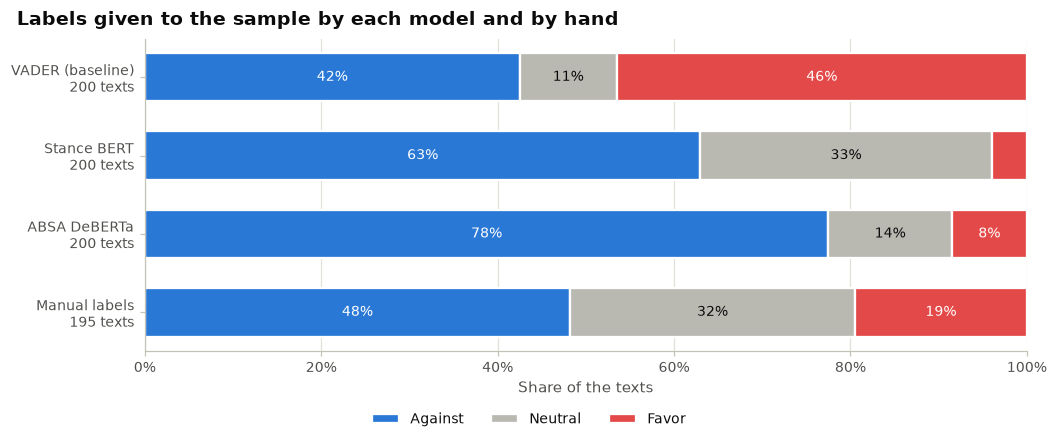

In [9]:
MIN_LABELLED = 30      # the comparison with manual labels is shown when at least this many texts are labelled

# a label counts only for a text that belongs to that part of the saved sample; other rows of a label file are ignored
labels = pd.concat([
    load_labels(part).merge(sample.loc[sample["part"] == part, ["id"]], on="id") for part in (1, 2)
]).rename(columns={"label": "human"})
n_ignored = len(load_labels(1)) + len(load_labels(2)) - len(labels)
results = (
    sample.merge(predictions, on="id", validate="one_to_one")
    .merge(labels, on="id", how="left", validate="one_to_one")
)
judged = results.loc[results["human"].isin(LABELS)]          # labelled and not skipped
HAS_LABELS = len(judged) >= MIN_LABELLED
NO_LABELS = f"Manual labels are not ready ({len(judged)} usable, {MIN_LABELLED} needed). Run Part 1 and Part 2 in section 1.3, then run section 1.4 and every cell below it again."
raters = MODELS + (["human"] if HAS_LABELS else [])


def label_column(rater):
    return "human" if rater == "human" else f"{rater}_label"


def rows_for(*pair):
    """Model against model is compared on the whole sample, anything against the manual labels on the labelled texts."""
    return judged if "human" in pair else results


if n_ignored:
    print(f"{n_ignored} rows of the label files are not texts of that part of the sample and are ignored")
print(f"manual labels: {results['human'].notna().sum()} of {len(results)} texts, "
      f"{(results['human'] == 'skip').sum()} of them skipped, {len(judged)} usable")
for m in ["stance", "absa"]:
    print(f"{RATER_NAME[m]}: {(results[f'{m}_tokens'] > MAX_TOKENS).sum()} texts are longer than {MAX_TOKENS} tokens and were cut")

def plot_label_shares():
    share = pd.DataFrame({r: 100 * rows_for(r)[label_column(r)].value_counts(normalize=True).reindex(LABELS, fill_value=0) for r in raters}).T
    names = [f"{RATER_NAME[r]}\n{len(rows_for(r))} texts" for r in raters]

    fig, ax = plt.subplots(figsize=(9.5, 0.9 + 0.75 * len(raters)), layout="constrained")
    left = np.zeros(len(raters))
    for label in LABELS:
        bars = ax.barh(names, share[label].values, left=left, height=0.62, color=LABEL_COLOR[label], edgecolor="white", linewidth=1.5, label=label.capitalize())
        for rect, v in zip(bars, share[label].values):
            if v >= 6:
                ax.text(rect.get_x() + rect.get_width() / 2, rect.get_y() + rect.get_height() / 2, f"{v:.0f}%",
                        ha="center", va="center", fontsize=9, color=ink_on(LABEL_COLOR[label]))
        left += share[label].values
    ax.invert_yaxis()
    ax.set_xlim(0, 100)
    ax.xaxis.set_major_formatter(PERCENT)
    ax.set_xlabel("Share of the texts")
    ax.grid(axis="y", visible=False)
    fig.legend(loc="outside lower center", ncols=3)
    headline(fig, "Labels given to the sample by each model" + (" and by hand" if HAS_LABELS else ""))
    plt.show()


plot_label_shares()

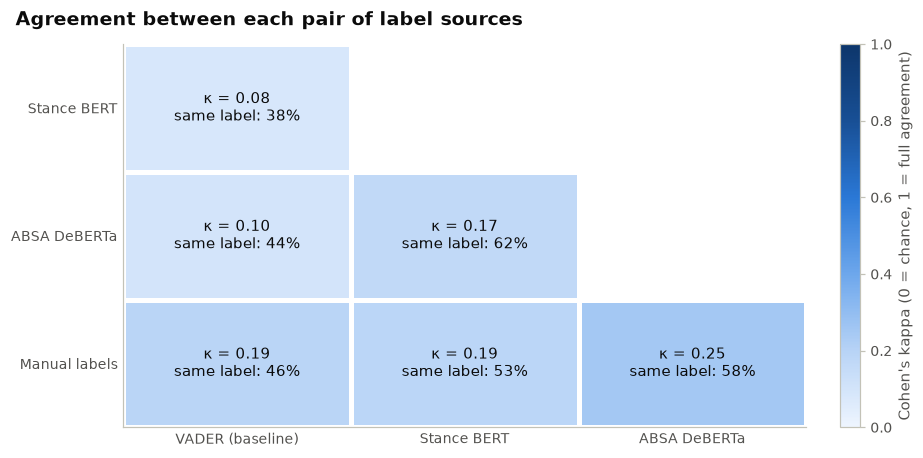

In [10]:
def plot_agreement():
    kappa = pd.DataFrame(np.nan, index=raters[1:], columns=raters[:-1])
    same = kappa.copy()
    for i, a in enumerate(raters):
        for b in raters[:i]:
            rows = rows_for(a, b)
            kappa.loc[a, b] = cohen_kappa_score(rows[label_column(a)], rows[label_column(b)], labels=LABELS)
            same.loc[a, b] = 100 * (rows[label_column(a)] == rows[label_column(b)]).mean()

    fig, ax = plt.subplots(figsize=(2.6 + 1.9 * kappa.shape[1], 1.5 + 0.85 * kappa.shape[0]), layout="constrained")
    mesh = ax.pcolormesh(np.ma.masked_invalid(kappa.to_numpy()), cmap=BLUES, vmin=0, vmax=1, edgecolors="white", linewidth=2)
    for i in range(kappa.shape[0]):
        for j in range(kappa.shape[1]):
            k = kappa.iat[i, j]
            if not np.isnan(k):
                ax.text(j + 0.5, i + 0.5, f"κ = {k:.2f}\nsame label: {same.iat[i, j]:.0f}%", ha="center", va="center", fontsize=9.5,
                        color=ink_on(mesh.cmap(mesh.norm(k))))
    ax.set_xticks(np.arange(kappa.shape[1]) + 0.5, [RATER_NAME[r] for r in kappa.columns])
    ax.set_yticks(np.arange(kappa.shape[0]) + 0.5, [RATER_NAME[r] for r in kappa.index])
    ax.invert_yaxis()
    ax.grid(False)
    ax.tick_params(length=0)
    fig.colorbar(mesh, ax=ax, label="Cohen's kappa (0 = chance, 1 = full agreement)")
    headline(fig, "Agreement between each pair of label sources")
    plt.show()


plot_agreement()

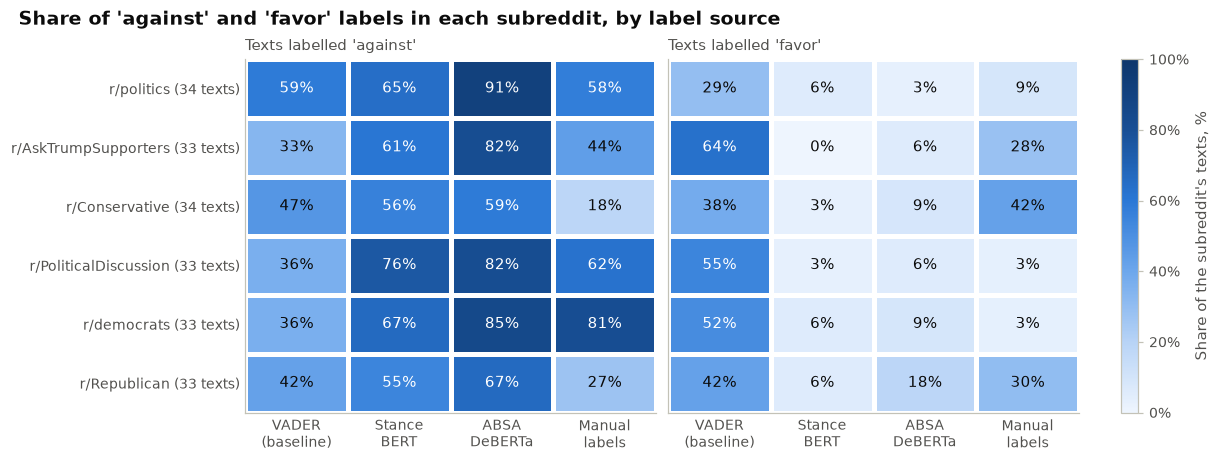

In [11]:
def plot_subreddit_shares():
    texts_in = results["subreddit"].value_counts()

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.1), sharey=True, layout="constrained")
    for ax, label in zip(axes, ["against", "favor"]):
        table = pd.DataFrame({
            r: 100 * (rows_for(r)[label_column(r)] == label).groupby(rows_for(r)["subreddit"]).mean() for r in raters
        }).reindex(SUBREDDITS)
        mesh = ax.pcolormesh(table.to_numpy(dtype=float), cmap=BLUES, vmin=0, vmax=100, edgecolors="white", linewidth=2)
        for i in range(table.shape[0]):
            for j in range(table.shape[1]):
                v = table.iat[i, j]
                if not np.isnan(v):
                    ax.text(j + 0.5, i + 0.5, f"{v:.0f}%", ha="center", va="center", fontsize=9.5, color=ink_on(mesh.cmap(mesh.norm(v))))
        ax.set_xticks(np.arange(len(raters)) + 0.5, [RATER_NAME[r].replace(" ", "\n") for r in raters], fontsize=9 if len(raters) < 7 else 7.5)
        ax.set_title(f"Texts labelled '{label}'")
        ax.grid(False)
        ax.tick_params(length=0)
    axes[0].set_yticks(np.arange(len(SUBREDDITS)) + 0.5, [f"r/{s} ({texts_in[s]} texts)" for s in SUBREDDITS])
    axes[0].invert_yaxis()
    fig.colorbar(mesh, ax=axes, label="Share of the subreddit's texts, %", format=PERCENT)
    headline(fig, "Share of 'against' and 'favor' labels in each subreddit, by label source")
    plt.show()


plot_subreddit_shares()

**What we see.**

- The three models describe the same 200 texts in three different ways. The share of `favor` is 46% for VADER, 8% for the aspect-based model and 4% for the stance model, and `against` is 42%, 78% and 63%.
- Agreement on single texts is close to chance. Cohen's kappa is 0.08-0.17 for every pair, where 0 is what two random labellers with the same label shares would reach.
- The two models built for a target give the same label to 62% of the texts, but mostly because both use `against` so often. They never both say `favor`: the stance model gives it to 8 texts and the aspect-based model to 17, and no text is in both groups.
- All three models agree on 29% of the texts, and 28 texts (14%) get three different labels.
- VADER behaves differently from the other two, as expected for a tone model. It gives `favor` to 64% of the texts from r/AskTrumpSupporters, where the other models give 0% and 6%.
- Both target models give their lowest `against` shares to the two right-leaning subreddits, but the gap is clear only for the aspect-based model: 59% in r/Conservative and 67% in r/Republican, against 82–91% in the other four. For the stance model it is 55–56% against 61–76%.
- One subreddit has about 33 texts, so a single share can move by about 17 points by chance. Taken together, r/Conservative and r/Republican (67 texts) are 22 points below the other four (133 texts) for the aspect-based model, with a 95% margin of ±13. For the stance model the gap is 12 points with a margin of ±14, which is within the noise.
- The charts above now also show the manual labels from section 1.3. They are discussed in section 1.5.

**What it means for the project.** The answer to "how much support for Trump is there" would be 46%, 4% or 8% depending on the model. The models cannot check each other, so the manual labels in the next section decide which one, if any, can be used.

### 1.5 The models against the manual labels

**Questions:** which model is closest to the manual labels, is it better than the baseline, and where does each model go wrong?

The manual label is treated as the correct answer. Three scores are reported for each model:

- **Accuracy:** the share of texts with the correct label. It can look high for a model that gives almost every text the most common label.
- **Macro-F1:** the F1 score of each class, averaged with equal weight. It is high only when all three classes are found, so it is the main score here.
- **Cohen's kappa:** agreement with the manual labels after removing the agreement expected by chance.

Two reference points help to read them. The majority baseline gives every text the most common manual label. The 95% intervals come from a bootstrap: the labelled texts are resampled `N_BOOT` times. With 200 texts the intervals are wide, and a gap between two models that is smaller than the interval is not a real difference.

In [12]:
N_BOOT = 2000      # bootstrap resamples for the 95% intervals
SCORES = ["accuracy", "macro-F1", "Cohen's kappa"]
CODE = {label: i for i, label in enumerate(LABELS)}


def three_scores(truth, predicted):
    """Accuracy, macro-F1 and Cohen's kappa from two arrays of class codes."""
    n = len(LABELS)
    cm = np.bincount(n * truth + predicted, minlength=n * n).reshape(n, n)
    total, hits = cm.sum(), np.diag(cm)
    in_truth, in_predicted = cm.sum(axis=1), cm.sum(axis=0)
    f1 = np.divide(2 * hits, in_truth + in_predicted, out=np.zeros(n), where=(in_truth + in_predicted) > 0)
    observed, by_chance = hits.sum() / total, (in_truth * in_predicted).sum() / total**2
    return np.array([observed, f1.mean(), (observed - by_chance) / (1 - by_chance) if by_chance < 1 else np.nan])


def evaluate():
    truth = judged["human"].map(CODE).to_numpy()
    predicted = {m: judged[f"{m}_label"].map(CODE).to_numpy() for m in MODELS}
    predicted["majority"] = np.full(len(truth), np.bincount(truth).argmax())
    draws = np.random.default_rng(SEED).integers(0, len(truth), size=(N_BOOT, len(truth)))     # the same resamples for every model
    point = pd.DataFrame({name: three_scores(truth, p) for name, p in predicted.items()}, index=SCORES).T
    boot = {name: np.array([three_scores(truth[d], p[d]) for d in draws]) for name, p in predicted.items()}
    low = pd.DataFrame({name: np.nanpercentile(b, 2.5, axis=0) for name, b in boot.items()}, index=SCORES).T
    high = pd.DataFrame({name: np.nanpercentile(b, 97.5, axis=0) for name, b in boot.items()}, index=SCORES).T
    return point, low, high, boot


def gaps(boot, point):
    """Difference in macro-F1 between each pair of models, with a 95% interval from the paired resamples."""
    f1 = SCORES.index("macro-F1")
    rows = {}
    for i, a in enumerate(MODELS):
        for b in MODELS[:i]:
            diff = boot[a][:, f1] - boot[b][:, f1]
            lo, hi = np.percentile(diff, [2.5, 97.5])
            rows[f"{RATER_NAME[a]} minus {RATER_NAME[b]}"] = {
                "difference in macro-F1": f"{point.loc[a, 'macro-F1'] - point.loc[b, 'macro-F1']:+.2f}",
                "95% interval": f"{lo:+.2f} to {hi:+.2f}",
                "interval excludes 0": "yes" if lo > 0 or hi < 0 else "no",
            }
    return pd.DataFrame(rows).T


if HAS_LABELS:
    point, low, high, boot = evaluate()
    ROW_NAME = {**RATER_NAME, "majority": f"Majority baseline (always '{judged['human'].mode()[0]}')"}
    summary = pd.DataFrame({
        s: [f"{point.loc[r, s]:.2f}  ({low.loc[r, s]:.2f} to {high.loc[r, s]:.2f})" for r in point.index] for s in SCORES
    }, index=[ROW_NAME[r] for r in point.index])
    print(f"{len(judged)} labelled texts; each cell is the score and its 95% interval")
    display(summary)
    display(gaps(boot, point))
else:
    print(NO_LABELS)

195 labelled texts; each cell is the score and its 95% interval


,accuracy,macro-F1,Cohen's kappa
VADER (baseline),0.46 (0.39 to 0.53),0.43 (0.36 to 0.50),0.19 (0.10 to 0.28)
Stance BERT,0.53 (0.46 to 0.60),0.42 (0.35 to 0.49),0.19 (0.08 to 0.29)
ABSA DeBERTa,0.58 (0.51 to 0.65),0.45 (0.38 to 0.53),0.25 (0.16 to 0.35)
Majority baseline (always 'against'),0.48 (0.41 to 0.55),0.22 (0.19 to 0.24),0.00 (0.00 to 0.00)


,difference in macro-F1,95% interval,interval excludes 0
Stance BERT minus VADER (baseline),-0.01,-0.11 to +0.08,no
ABSA DeBERTa minus VADER (baseline),+0.02,-0.07 to +0.12,no
ABSA DeBERTa minus Stance BERT,+0.04,-0.06 to +0.14,no


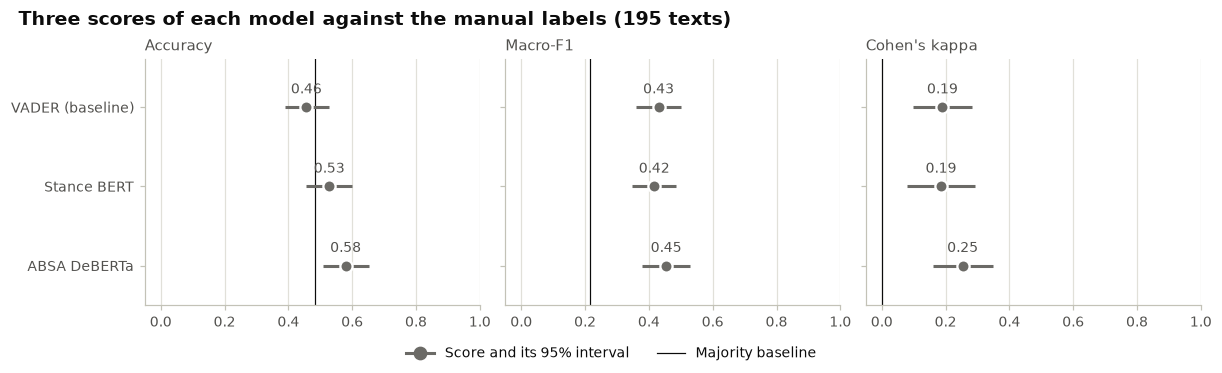

In [13]:
PER_ROW = 3      # panels in one row of a chart with one panel per model


def panels(n, height):
    """One panel per model, at most PER_ROW in a row, with a shared y axis."""
    n_rows = -(-n // PER_ROW)
    fig, axes = plt.subplots(n_rows, min(n, PER_ROW), figsize=(11, height * n_rows), sharey=True, layout="constrained", squeeze=False)
    for ax in axes.flat[n:]:
        ax.remove()
    return fig, axes.flat[:n]


def plot_scores():
    y_pos = np.arange(len(MODELS))
    fig, axes = plt.subplots(1, 3, figsize=(11, 1.5 + 0.6 * len(MODELS)), sharey=True, layout="constrained")
    for ax, s in zip(axes, SCORES):
        x = point.loc[MODELS, s].to_numpy()
        ax.errorbar(x, y_pos, xerr=[x - low.loc[MODELS, s], high.loc[MODELS, s] - x], fmt="o", color=NEUTRAL, markersize=8,
                    markeredgecolor="white", markeredgewidth=1.5, elinewidth=2, capsize=0, zorder=3)
        for v, yy in zip(x, y_pos):
            ax.annotate(f"{v:.2f}", (v, yy), xytext=(0, 9), textcoords="offset points", ha="center", fontsize=9, color=INK_2)
        ax.axvline(point.loc["majority", s], color=INK, linewidth=0.8)
        ax.set_xlim(min(-0.05, low[s].min() - 0.05), 1)
        ax.set_title(s[0].upper() + s[1:])
        ax.grid(axis="y", visible=False)
    axes[0].set_yticks(y_pos, [RATER_NAME[m] for m in MODELS])
    axes[0].set_ylim(len(MODELS) - 0.5, -0.6)
    fig.legend(handles=[Line2D([], [], color=NEUTRAL, marker="o", markersize=8, linewidth=2, label="Score and its 95% interval"),
                        Line2D([], [], color=INK, linewidth=0.8, label="Majority baseline")], loc="outside lower center", ncols=2)
    headline(fig, f"Three scores of each model against the manual labels ({len(judged)} texts)")
    plt.show()


plot_scores() if HAS_LABELS else print(NO_LABELS)

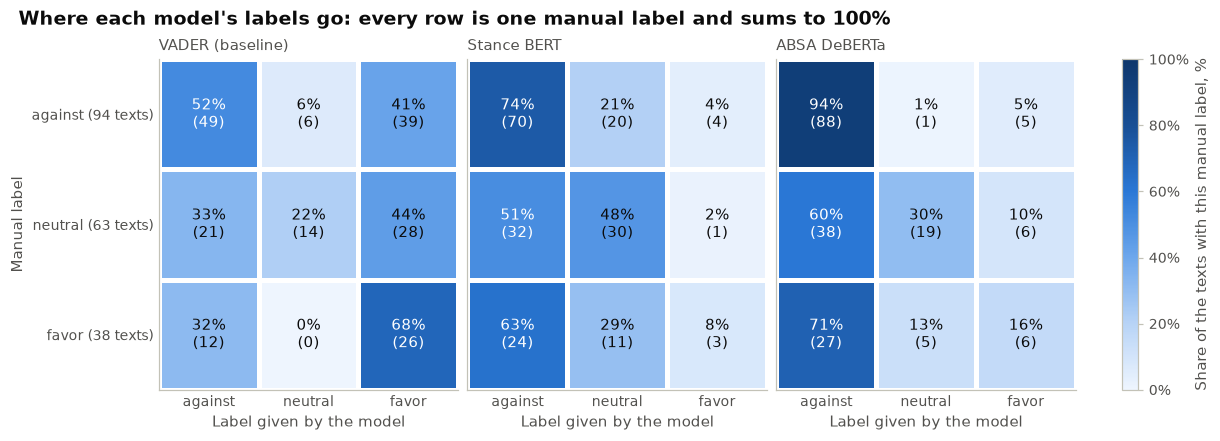

In [14]:
def plot_confusion():
    fig, axes = panels(len(MODELS), 3.9)
    for ax, m in zip(axes, MODELS):
        counts = confusion_matrix(judged["human"], judged[f"{m}_label"], labels=LABELS)
        percent = 100 * counts / counts.sum(axis=1, keepdims=True).clip(min=1)
        mesh = ax.pcolormesh(percent, cmap=BLUES, vmin=0, vmax=100, edgecolors="white", linewidth=2)
        for i in range(len(LABELS)):
            for j in range(len(LABELS)):
                ax.text(j + 0.5, i + 0.5, f"{percent[i, j]:.0f}%\n({counts[i, j]})", ha="center", va="center", fontsize=9.5,
                        color=ink_on(mesh.cmap(mesh.norm(percent[i, j]))))
        ax.set_xticks(np.arange(len(LABELS)) + 0.5, LABELS)
        ax.set_xlabel("Label given by the model")
        ax.set_title(RATER_NAME[m])
        ax.grid(False)
        ax.tick_params(length=0)
    manual = judged["human"].value_counts().reindex(LABELS, fill_value=0)
    axes[0].set_yticks(np.arange(len(LABELS)) + 0.5, [f"{label} ({manual[label]} texts)" for label in LABELS])
    for ax in axes[::PER_ROW]:
        ax.set_ylabel("Manual label")
    axes[0].invert_yaxis()
    fig.colorbar(mesh, ax=axes, label="Share of the texts with this manual label, %", format=PERCENT)
    headline(fig, "Where each model's labels go: every row is one manual label and sums to 100%")
    plt.show()


plot_confusion() if HAS_LABELS else print(NO_LABELS)

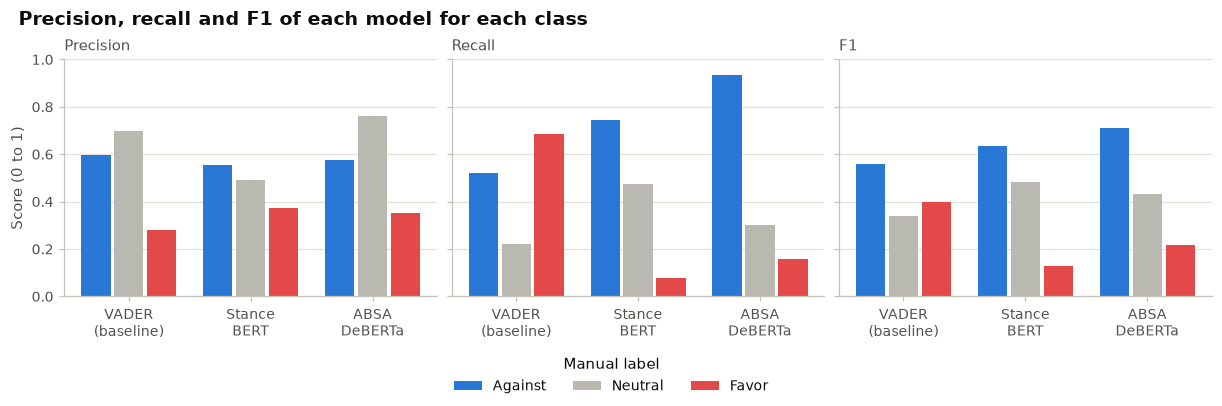

precision  recall    F1
VADER (baseline) against       0.60    0.52  0.56
                 neutral       0.70    0.22  0.34
                 favor         0.28    0.68  0.40
Stance BERT      against       0.56    0.74  0.64
                 neutral       0.49    0.48  0.48
                 favor         0.38    0.08  0.13
ABSA DeBERTa     against       0.58    0.94  0.71
                 neutral       0.76    0.30  0.43
                 favor         0.35    0.16  0.22

In [15]:
def per_class_table():
    table = {}
    for m in MODELS:
        precision, recall, f1, _ = precision_recall_fscore_support(judged["human"], judged[f"{m}_label"], labels=LABELS, zero_division=0)
        for label, p, r, f in zip(LABELS, precision, recall, f1):
            table[(RATER_NAME[m], label)] = {"precision": p, "recall": r, "F1": f}
    return pd.DataFrame(table).T


def plot_per_class(per_class):
    x_pos = np.arange(len(MODELS))
    fig, axes = plt.subplots(1, 3, figsize=(11, 3.6), sharey=True, layout="constrained")
    for ax, measure in zip(axes, per_class.columns):
        for j, label in enumerate(LABELS):
            values = [per_class.loc[(RATER_NAME[m], label), measure] for m in MODELS]
            ax.bar(x_pos + (j - 1) * 0.27, values, width=0.24, color=LABEL_COLOR[label], label=label.capitalize())
        ax.set_xticks(x_pos, [RATER_NAME[m].replace(" ", "\n") for m in MODELS])
        ax.set_ylim(0, 1)
        ax.set_title(measure[0].upper() + measure[1:])
        ax.grid(axis="x", visible=False)
    axes[0].set_ylabel("Score (0 to 1)")
    handles, legend_labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, legend_labels, title="Manual label", loc="outside lower center", ncols=3)
    headline(fig, "Precision, recall and F1 of each model for each class")
    plt.show()


if HAS_LABELS:
    per_class = per_class_table()
    plot_per_class(per_class)
    display(per_class.round(2))
else:
    print(NO_LABELS)

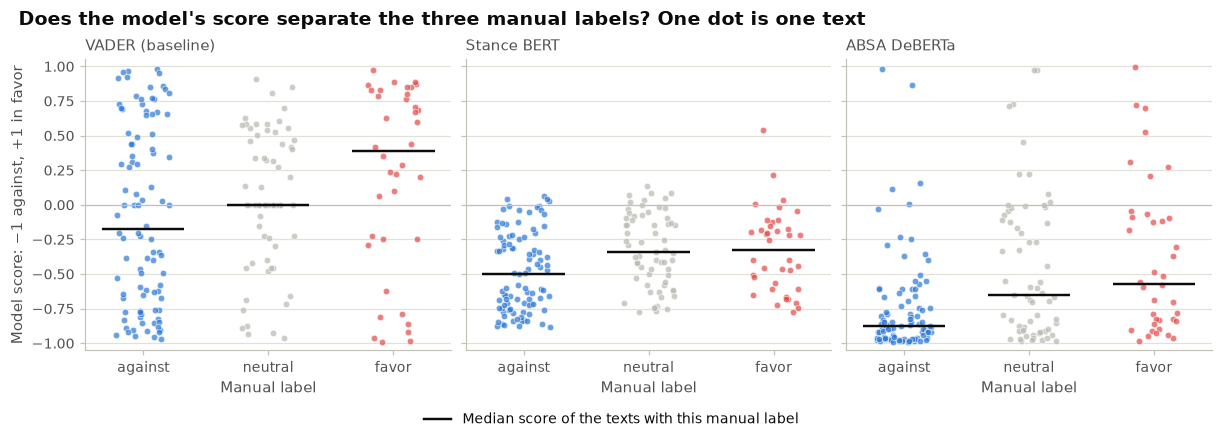

In [16]:
def plot_signed_scores():
    rng = np.random.default_rng(SEED)
    fig, axes = panels(len(MODELS), 3.9)
    for ax, m in zip(axes, MODELS):
        for j, label in enumerate(LABELS):
            values = judged.loc[judged["human"] == label, f"{m}_score"].to_numpy()
            ax.scatter(j + rng.uniform(-0.22, 0.22, len(values)), values, s=18, color=LABEL_COLOR[label], alpha=0.7, edgecolor="white", linewidth=0.5)
            if len(values):
                ax.hlines(np.median(values), j - 0.33, j + 0.33, color=INK, linewidth=1.6, zorder=3)
        ax.axhline(0, color=AXIS, linewidth=0.8)
        ax.set_xticks(range(len(LABELS)), LABELS)
        ax.set_xlabel("Manual label")
        ax.set_ylim(-1.05, 1.05)
        ax.set_title(RATER_NAME[m])
        ax.grid(axis="x", visible=False)
    for ax in axes[::PER_ROW]:
        ax.set_ylabel("Model score: −1 against, +1 in favor")
    fig.legend(handles=[Line2D([], [], color=INK, linewidth=1.6, label="Median score of the texts with this manual label")],
               loc="outside lower center")
    headline(fig, "Does the model's score separate the three manual labels? One dot is one text")
    plt.show()


plot_signed_scores() if HAS_LABELS else print(NO_LABELS)

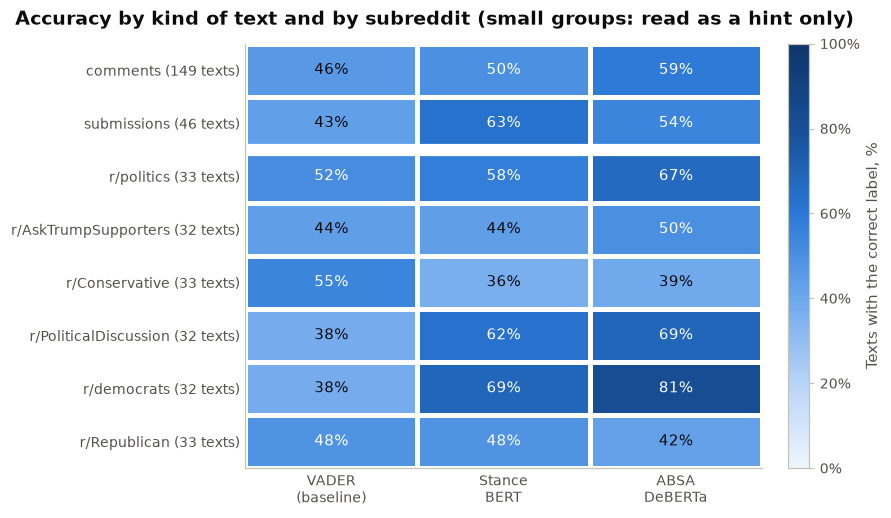

In [17]:
def plot_accuracy_by_group():
    groups = {"comments": judged["kind"] == "comment", "submissions": judged["kind"] == "submission"}
    groups = {g: mask for g, mask in groups.items() if mask.any()}
    n_kinds = len(groups)
    groups.update({f"r/{s}": judged["subreddit"] == s for s in SUBREDDITS})
    accuracy = pd.DataFrame({
        m: {g: 100 * (judged.loc[mask, f"{m}_label"] == judged.loc[mask, "human"]).mean() for g, mask in groups.items()} for m in MODELS
    })
    fig, ax = plt.subplots(figsize=(8, 4.6), layout="constrained")
    mesh = ax.pcolormesh(accuracy.to_numpy(dtype=float), cmap=BLUES, vmin=0, vmax=100, edgecolors="white", linewidth=2)
    for i in range(accuracy.shape[0]):
        for j in range(accuracy.shape[1]):
            v = accuracy.iat[i, j]
            if not np.isnan(v):
                ax.text(j + 0.5, i + 0.5, f"{v:.0f}%", ha="center", va="center", fontsize=9.5, color=ink_on(mesh.cmap(mesh.norm(v))))
    ax.axhline(n_kinds, color="white", linewidth=8)           # separates the kinds of text from the six subreddits
    ax.set_xticks(np.arange(len(MODELS)) + 0.5, [RATER_NAME[m].replace(" ", "\n") for m in MODELS])
    ax.set_yticks(np.arange(len(groups)) + 0.5, [f"{g} ({mask.sum()} texts)" for g, mask in groups.items()])
    ax.invert_yaxis()
    ax.grid(False)
    ax.tick_params(length=0)
    fig.colorbar(mesh, ax=ax, label="Texts with the correct label, %", format=PERCENT)
    headline(fig, "Accuracy by kind of text and by subreddit (small groups: read as a hint only)")
    plt.show()


plot_accuracy_by_group() if HAS_LABELS else print(NO_LABELS)

**What we see.**

- 195 of the 200 texts have a usable manual label (5 skipped): 48% `against`, 32% `neutral` and 19% `favor`.
- No model reproduces the manual labels well. The aspect-based model has the highest scores (accuracy 0.58, macro-F1 0.45, kappa 0.25). The stance model has 0.53, 0.42 and 0.19, and VADER has 0.46, 0.43 and 0.19.
- The three models cannot be ranked. Their gaps in macro-F1 are between −0.01 and +0.04, and every 95% interval includes zero. VADER, which only counts positive and negative words, reaches the same macro-F1 as the two transformer models.
- All three carry some information. Their macro-F1 is about twice the majority baseline (0.22), and every kappa interval stays above zero.
- On accuracy the picture is weaker. The baseline reaches 0.48 by answering `against` every time. VADER is below it, and only the aspect-based model has an interval (0.51 to 0.65) that lies above it.
- `favor` is the main failure. Of 38 supportive texts the stance model finds 3 and the aspect-based model 6 (it labels 63% and 71% of them `against`). VADER finds 26, but labels 93 texts `favor`, so only 28% of its `favor` labels are right.
- The aspect-based model finds 94% of the `against` texts because it answers `against` most of the time. It gives the same label to 60% of the neutral texts.
- The scores do not separate the classes. For both transformers the median score of all three groups is below zero and the groups overlap almost fully, so moving the threshold would not repair the labels.
- Errors are uneven. In r/Conservative and r/Republican, where 36% of the texts are supportive, the two transformer models are right on 41–42% of the texts. In the other four subreddits, where 11% are supportive, they are right on 58% and 67%.

**What it means for the project.**

- None of the three models can measure support for Trump as it is. On this sample they report 4% and 8% of supportive texts where we see 19%, and they miss the support in the communities where most of it is.
- A comparison of subreddits or of the two terms made with these models would mostly show where the model fails, not where opinion differs.

### 1.6 All texts with every label

The table lists the texts that already have a manual label, in the order in which they were labelled, with the three model labels and the model scores (from −1, against, to +1, in favor) next to it. Texts that are not labelled yet are hidden, so that the table cannot influence the person who labels them. The full table, with the complete text and the model probabilities, is saved to `data/sentiment/sentiment_results.csv`.

In [18]:
TEXT_CHARS = 160      # characters of each text shown in the table

results.to_csv(SENT_DIR / "sentiment_results.csv", index=False, lineterminator="\n")

listed = results.loc[results["human"].notna()].sort_values(["part", "order"])
listing = pd.DataFrame({
    "part": listed["part"],
    "kind": listed["kind"],
    "subreddit": listed["subreddit"],
    "window": listed["period"].map(PERIOD_YEAR),
    "text": listed["text"].str.replace(r"\s+", " ", regex=True).str.slice(0, TEXT_CHARS),
    "manual": listed["human"],
    **{RATER_NAME[m]: listed[f"{m}_label"] for m in MODELS},
    **{f"{m} score": listed[f"{m}_score"].round(2) for m in MODELS},        # from -1 (against) to +1 (in favor)
}).reset_index(drop=True)

print(f"{len(listing)} of {len(results)} texts are shown; {len(results) - len(listing)} are hidden until they are labelled")
if len(listing):
    with pd.option_context("display.max_rows", None, "display.max_colwidth", TEXT_CHARS):
        display(listing)

200 of 200 texts are shown; 0 are hidden until they are labelled


,part,kind,subreddit,window,text,manual,VADER (baseline),Stance BERT,ABSA DeBERTa,vader score,stance score,absa score
0,1,comment,AskTrumpSupporters,2017,Did any actual members of the Democratic party say that? That would be like me calling the Republicans a party of racists because David Duke supported Trump...,neutral,favor,neutral,against,0.51,-0.20,-0.79
1,1,submission,politics,2026,"Trump call for nationalizing elections sparks backlash, warnings",neutral,against,neutral,against,-0.30,-0.10,-0.88
2,1,comment,democrats,2017,"""Flismy"" is an understatement. He is an attorney trained to carefully chose his words and he never said ""I never spoke to them as a Trump supporter"". He sai...",neutral,favor,against,against,0.13,-0.71,-0.66
3,1,submission,AskTrumpSupporters,2018,"If the FBI was trying to undermine Trump with the Russia investigation, why did they fail to reveal the existence of that investigation before he was electe...",neutral,against,neutral,against,-0.69,-0.40,-0.65
4,1,submission,AskTrumpSupporters,2026,"Do you consider Melania Trump to be an American? (please explain why, not just yes or no)",skip,against,neutral,neutral,-0.31,-0.26,-0.16
5,1,comment,Conservative,2025,Yeah my point is conservatives do it too. Right or wrong trump also blew out the budget. I was happier with trump before covid than during. He bought into t...,neutral,against,against,against,-0.88,-0.14,-0.94
6,1,submission,democrats,2026,Trump And Epstein Get The Carnival Treatment In Germany. And It’s Brutal.,against,against,neutral,against,-0.62,-0.14,-0.98
7,1,comment,Republican,2017,WE don't invoke Article 5. The alliance does. And Trump did not say he didn't commit to it. He just did not specifically mention it.,neutral,against,against,against,-0.22,-0.75,-0.96
8,1,submission,PoliticalDiscussion,2018,Why would anyone on “team” Trump be worried,skip,against,neutral,neutral,-0.30,-0.33,-0.05
9,1,comment,Conservative,2018,"This is beyond hilarious. Trump has many faults, but god damn he is a master at destroying his political opponents.",favor,against,against,neutral,-0.79,-0.72,-0.05


### 1.7 What we learned and what stays open

**Limits of this evaluation**

- 200 texts is a small test set, and the sample is balanced across subreddits, so the scores describe a balanced mix of communities, not the dataset where r/politics dominates. Texts above 250 words were not sampled.
- Every text is labelled by one person, so we cannot measure how often two people would disagree on the same text. The manual label is treated as the truth, although some texts are hard to judge.
- The manual labels have their own noise. One submission ended up in both label files and got two different labels (`against` and `neutral`). The two parts also differ: 43% of part 1 and 54% of part 2 are `against`, with the same mix of subreddits. The gap of 11 points has a margin of ±14, so it can be chance, or the two of us may draw the line between `against` and `neutral` differently.
- The stance model was trained on 2020 tweets and works outside its data here. VADER measures tone, so its errors show the distance between tone and stance, not a defect.

**Which model we take forward**

None of the three models is usable as it is. The aspect-based model scores highest, but its lead over the VADER baseline is inside the noise and it finds only 6 of the 38 supportive texts.

**Next.**

Section 2 tries a larger general model that receives the question as an instruction ("is the author for or against Trump?"), and score it on the same 195 texts.


## 2. Stance with an instructed local LLM

**Question.** Does a general language model that receives the question as an instruction find the support for Trump that the three models of section 1 miss?

The constraint is the hardware: a GTX 1650 with 4 GB of VRAM. The model must sit on the GPU completely, because a model that spills into system RAM becomes many times slower. Two small models from the same family are compared, with the same prompt and the same settings, so the only difference between the two runs is the size of the model.

| Step | What happens |
|---|---|
| 2.1 | The models, the runtime and every setting of the run are fixed in one place |
| 2.2 | The prompt: the rules of the manual labelling from section 1.3, and ten examples of hard cases |
| 2.3 | Both models label the 200 texts; the run stops if a model is not fully on the GPU or starts to "think" |
| 2.4 | Speed and memory: texts per second and VRAM, with 1, 2 and 4 parallel slots |
| 2.5 | The same charts as in sections 1.4 and 1.5, now with five models |
| 2.6 | The texts on which the better model is still wrong |

### 2.1 Models, runtime and settings

| | Qwen3.5 2B | Qwen3.5 4B |
|---|---|---|
| Source | [`unsloth/Qwen3.5-2B-GGUF`](https://huggingface.co/unsloth/Qwen3.5-2B-GGUF) | [`unsloth/Qwen3.5-4B-GGUF`](https://huggingface.co/unsloth/Qwen3.5-4B-GGUF) |
| File | `Q4_K_M`, 1.28 GB | `Q4_K_M`, 2.74 GB; `Q4_K_S` and `IQ4_XS` are tried only if it does not fit |

- **Runtime:** `llama-server` from llama.cpp, the prebuilt CUDA build for Windows. It is unpacked into the virtual environment (`.venv/llama.cpp/`), and the model files are in `data/models/`. The notebook starts the server, sends the texts over HTTP and stops the server.
- **All layers on the GPU** (`-ngl 99`), with a context of 2,048 tokens for each slot.
- **No thinking:** The 4B model writes a chain of reasoning before its answer by default. With an answer of at most 5 tokens that would leave no room for the label, so thinking is switched off in every request (`enable_thinking: false`), for both models.
- **Deterministic output:** temperature 0 and a fixed seed.
- **Only three possible answers:** a grammar (GBNF) lets the model write `pro`, `against` or `neutral` and nothing else. The notebook maps `pro` to the label `favor` used in section 1. Any other answer would get the label `error` and would be listed with its raw text; it is never guessed.

The full configuration and the checksum of each file are saved in `data/sentiment/llm_run_config.json`.

In [19]:
import hashlib
import json
import re
import socket
import subprocess
import threading
import time
from concurrent.futures import ThreadPoolExecutor

import pynvml
import requests
from huggingface_hub import hf_hub_download

LLAMA_BUILD = "b11146"            # llama.cpp release (CUDA 12.4 build for Windows); Qwen3.5 needs b8121 or newer
LLAMA_SERVER = Path(sys.prefix) / "llama.cpp" / LLAMA_BUILD / "llama-server.exe"      # kept inside the virtual environment
MODEL_DIR = ROOT / "data" / "models"
LLM_LOG_DIR = SENT_DIR / "llm_logs"

# the files of each model in order of preference: the first one that fits the GPU completely is used
LLM_FILES = {
    "qwen2b": ("unsloth/Qwen3.5-2B-GGUF", ["Qwen3.5-2B-Q4_K_M.gguf"]),
    "qwen4b": ("unsloth/Qwen3.5-4B-GGUF", ["Qwen3.5-4B-Q4_K_M.gguf", "Qwen3.5-4B-Q4_K_S.gguf", "Qwen3.5-4B-IQ4_XS.gguf"]),
}
LLM_MODELS = list(LLM_FILES)

CTX_PER_SLOT = 2048               # context of one server slot, in tokens
SLOTS = [1, 2, 4]                 # numbers of parallel slots tried in the benchmark; the labels come from the run with one slot
SHARED_LIMIT_MIB = 150            # more "shared GPU memory" than this means the model spilled from VRAM into system RAM
NO_CACHE_TEXTS = 40               # texts sent once more with the prefix cache off, to measure what the cache saves
TEXT_MAX_CHARS = 4000             # a longer text is cut at the end (no text of the sample is that long)
RESCORE_LLM = False               # True runs the models again even when saved predictions exist

# the same request settings for both models
GENERATION = {
    "temperature": 0, "max_tokens": 5, "seed": SEED, "cache_prompt": True,
    "chat_template_kwargs": {"enable_thinking": False},
    "grammar": 'root ::= "pro" | "against" | "neutral"',       # GBNF: the output can only be one of the three labels
    "logprobs": True, "top_logprobs": 20,                       # probabilities of the first token, for a score from -1 to +1
}
LLM_LABEL = {"pro": "favor", "against": "against", "neutral": "neutral"}      # the label names of this notebook

LLM_PREDICTIONS_PATH = SENT_DIR / "llm_predictions.csv"
LLM_BENCHMARK_PATH = SENT_DIR / "llm_benchmark.csv"
LLM_CONFIG_PATH = SENT_DIR / "llm_run_config.json"

### 2.2 The prompt

**Question:** what exactly is the model asked?

The prompt has three parts, in this order: a fixed instruction, ten fixed examples with their answers, and the text to label at the very end. The order matters for speed. Everything before the text is the same in every request, so the server computes it once and reuses it (prefix cache), and only the text itself is new work.

The instruction repeats the rules of section 1.3. Its main rule is that the label is the author's position toward Trump, not the tone. 

The examples cover the cases where tone and stance diverge: an angry defence of Trump, a happy text about his failure, sarcasm in both directions, a headline, a question, an attack on his opponents, a mixed opinion, an off-topic text. We wrote them ourselves, none of them is in the sample.

The prompt has a version (`PROMPT_VERSION`), saved with every answer. **This is version 1, written before any score was seen, and it was not changed afterwards.** That matters because there is no second labelled set: a prompt that is tuned on these 200 texts would look better here than on new texts.

In [20]:
PROMPT_VERSION = "v1"

SYSTEM_PROMPT = """You classify the stance of the author of a Reddit text toward Donald Trump.

Answer with exactly one word: pro, against or neutral.

- against: the author criticises, mocks or opposes Trump, his decisions or his administration.
- pro: the author supports, defends or praises Trump or his decisions.
- neutral: the author shows no clear position toward Trump. This covers a plain news headline, a question, a fact, and a text about something else that only mentions Trump.

Rules:
1. Judge the author's position toward Trump, not the tone of the text. An angry text is pro when the anger defends Trump against his critics. A cheerful text is against when the author is happy about a failure of Trump.
2. Sarcasm and irony (often marked with /s) are judged by what the author means, not by the words.
3. A headline that only reports what happened is neutral, even when the news is bad for Trump. A headline with an evaluation in it is not neutral.
4. An attack on Trump's opponents or on the media is pro only when the defence of Trump is clear. Otherwise it is neutral.
5. A text that criticises one decision and supports Trump in general (or the opposite) gets the label of its main point.
6. A quote of Trump with no comment from the author is neutral."""

# written by hand for the hard cases; none of them is a text of the evaluation sample
FEW_SHOT = [
    ("The media is so dishonest it's disgusting. They twist every single thing Trump says and then act shocked when nobody trusts them anymore.", "pro"),          # negative tone, supportive stance
    ("Best news all week! The court just threw out his travel ban again. Pop the champagne, folks.", "against"),                                                  # positive tone, opposing stance
    ("Trump signs executive order on steel and aluminum tariffs", "neutral"),                                                                                     # plain headline
    ("Oh sure, Trump is definitely a stable genius. Nothing says genius like bankrupting a casino. /s", "against"),                                               # sarcasm, praise in words only
    ("Can someone explain how the tariffs Trump announced actually work? Who pays them, the importer or the exporter?", "neutral"),                               # question
    ("Yeah, because the economy was doing SO great before Trump took office. /s", "pro"),                                                                         # sarcasm, criticism in words only
    ("With or without Trump on the ballot, the Democrats have no message at all. They lost the working class years ago and still don't understand why.", "neutral"),  # attack on opponents, no defence of Trump
    ("He lied about the crowd size on day one and he has not stopped lying since. This administration is a disgrace.", "against"),                                # plain opposition
    ("I don't like his tweets, but the tax cut and the judges are exactly what I voted for. He is delivering.", "pro"),                                           # mixed, the main point is support
    ("My rent went up again and I spent the whole weekend fixing my car. At least the Trump debate on TV was good background noise.", "neutral"),                 # not about Trump
]
assert not set(text for text, _ in FEW_SHOT) & set(sample["text"])


def user_turn(text):
    return {"role": "user", "content": "Text:\n" + text[:TEXT_MAX_CHARS]}


# everything except the last message is the same in every request, so the server computes this prefix once and reuses it
STATIC_MESSAGES = [{"role": "system", "content": SYSTEM_PROMPT}]
for example, answer in FEW_SHOT:
    STATIC_MESSAGES += [user_turn(example), {"role": "assistant", "content": answer}]


def build_messages(text):
    return STATIC_MESSAGES + [user_turn(text)]


print(f"prompt {PROMPT_VERSION}: system instruction, {len(FEW_SHOT)} examples "
      f"({', '.join(f'{n} {label}' for label, n in pd.Series([a for _, a in FEW_SHOT]).value_counts().items())}), then the text\n")
print(SYSTEM_PROMPT)
display(pd.DataFrame(FEW_SHOT, columns=["example", "answer"]))

prompt v1: system instruction, 10 examples (4 neutral, 3 pro, 3 against), then the text

You classify the stance of the author of a Reddit text toward Donald Trump.

Answer with exactly one word: pro, against or neutral.

- against: the author criticises, mocks or opposes Trump, his decisions or his administration.
- pro: the author supports, defends or praises Trump or his decisions.
- neutral: the author shows no clear position toward Trump. This covers a plain news headline, a question, a fact, and a text about something else that only mentions Trump.

Rules:
1. Judge the author's position toward Trump, not the tone of the text. An angry text is pro when the anger defends Trump against his critics. A cheerful text is against when the author is happy about a failure of Trump.
2. Sarcasm and irony (often marked with /s) are judged by what the author means, not by the words.
3. A headline that only reports what happened is neutral, even when the news is bad for Trump. A headline with a

,example,answer
0,The media is so dishonest it's disgusting. They twist every single thing Trump says and then act shocked when nobody trusts th...,pro
1,"Best news all week! The court just threw out his travel ban again. Pop the champagne, folks.",against
2,Trump signs executive order on steel and aluminum tariffs,neutral
3,"Oh sure, Trump is definitely a stable genius. Nothing says genius like bankrupting a casino. /s",against
4,"Can someone explain how the tariffs Trump announced actually work? Who pays them, the importer or the exporter?",neutral
5,"Yeah, because the economy was doing SO great before Trump took office. /s",pro
6,"With or without Trump on the ballot, the Democrats have no message at all. They lost the working class years ago and still don...",neutral
7,He lied about the crowd size on day one and he has not stopped lying since. This administration is a disgrace.,against
8,"I don't like his tweets, but the tax cut and the judges are exactly what I voted for. He is delivering.",pro
9,My rent went up again and I spent the whole weekend fixing my car. At least the Trump debate on TV was good background noise.,neutral


### 2.3 Running the models

**Question:** do the models run as intended on this GPU?

For each model the cell below starts the server, checks it, labels the 200 texts and stops the server. The run stops with an error in four cases:

1. **The model is not fully on the GPU.** The server log must report all layers on the GPU, and the "shared GPU memory" of the server process must stay small. Shared GPU memory is system RAM that Windows lends to the GPU when the VRAM is full, so its growth is the sign of a spill. In that case the next, smaller file of the model is tried.
2. **The model thinks.** The grammar would hide a thinking block, so the check is made with one free answer without the grammar, and on the final text of the prompt.
3. **The two control sentences from section 1.2 get wrong labels.**
4. **A second run gives different labels.**

Answers are saved to `data/sentiment/llm_predictions.csv`

In [21]:
class DoesNotFit(RuntimeError):
    """The model is not completely on the GPU."""


def sha256(data):
    """SHA-256 of a file (given its path) or of a string."""
    digest = hashlib.sha256()
    if isinstance(data, Path):
        with open(data, "rb") as f:
            while chunk := f.read(1 << 22):
                digest.update(chunk)
    else:
        digest.update(data.encode("utf-8"))
    return digest.hexdigest()


def gpu():
    pynvml.nvmlInit()
    return pynvml.nvmlDeviceGetHandleByIndex(0)


def vram_used_mib():
    """Dedicated VRAM in use on the card, by all programs together."""
    return pynvml.nvmlDeviceGetMemoryInfo(gpu()).used / 2**20


def process_gpu_memory_mib(pid):
    """Dedicated and shared GPU memory of one process, from the Windows performance counters.
    'Shared' is system RAM that the driver lends to the GPU: it grows when the VRAM is full."""
    counters = ",".join(f"'\\GPU Process Memory(pid_{pid}_*)\\{kind} Usage'" for kind in ("Dedicated", "Shared"))
    command = f"(Get-Counter {counters}).CounterSamples | ForEach-Object {{ $_.Path + '=' + [long]$_.CookedValue }}"
    lines = subprocess.run(["powershell", "-NoProfile", "-Command", command], capture_output=True, text=True).stdout.splitlines()
    memory = {"dedicated": 0.0, "shared": 0.0}
    for line in lines:
        path, _, value = line.rpartition("=")
        for kind in memory:
            if path.endswith(f"{kind} usage"):
                memory[kind] += int(value) / 2**20
    assert memory["dedicated"] > 0, f"no GPU memory counters for process {pid}"
    return memory


class VramPeak:
    """Reads the VRAM in use five times a second while a block of code runs and keeps the highest value."""

    def __enter__(self):
        self.peak, self._stop = vram_used_mib(), threading.Event()
        self._thread = threading.Thread(target=self._watch, daemon=True)
        self._thread.start()
        return self

    def _watch(self):
        while not self._stop.wait(0.2):
            self.peak = max(self.peak, vram_used_mib())

    def __exit__(self, *exc):
        self._stop.set()
        self._thread.join()


def label_probabilities(choice):
    """Probabilities of the three labels as the first output token, scaled to sum to 1."""
    first = {t["token"]: np.exp(t["logprob"]) for t in choice["logprobs"]["content"][0]["top_logprobs"]}
    p = {LLM_LABEL[word]: first.get(word, 0.0) for word in LLM_LABEL}
    total = sum(p.values())
    return {f"p_{label}": p[label] / total for label in LABELS}


class LlamaServer:
    """One llama-server process. The model must be on the GPU completely, and the visual encoder (mmproj) is not loaded."""

    def __init__(self, model_path, slots):
        self.model_path, self.slots = model_path, slots
        with socket.socket() as s:                              # a free port
            s.bind(("127.0.0.1", 0))
            self.port = s.getsockname()[1]
        self.url = f"http://127.0.0.1:{self.port}"
        self.log_path = LLM_LOG_DIR / f"{model_path.stem}_np{slots}.log"
        self.flags = ["-ngl", "99", "-c", str(CTX_PER_SLOT * slots), "-np", str(slots), "--no-kv-unified", "--seed", str(SEED),
                      "--reasoning", "off", "--no-mmproj", "--no-webui", "-lv", "4"]

    def __enter__(self):
        LLM_LOG_DIR.mkdir(parents=True, exist_ok=True)
        self.vram_before = vram_used_mib()
        self._log = open(self.log_path, "w", encoding="utf-8")
        self.process = subprocess.Popen([str(LLAMA_SERVER), "-m", str(self.model_path), *self.flags, "--host", "127.0.0.1", "--port", str(self.port)],
                                        stdout=self._log, stderr=subprocess.STDOUT)
        try:
            for _ in range(600):
                if self.process.poll() is not None:
                    raise DoesNotFit(f"llama-server stopped while loading {self.model_path.name}; see {self.log_path}")
                try:
                    if requests.get(self.url + "/health", timeout=2).status_code == 200:
                        return self
                except requests.RequestException:
                    pass
                time.sleep(0.5)
            raise TimeoutError(f"llama-server did not become ready; see {self.log_path}")
        except BaseException:
            self.__exit__()
            raise

    def __exit__(self, *exc):
        self.process.terminate()
        self.process.wait(timeout=60)
        self._log.close()

    def chat(self, messages, **overrides):
        body = {k: v for k, v in {**GENERATION, **overrides, "messages": messages}.items() if v is not None}
        response = requests.post(self.url + "/v1/chat/completions", json=body, timeout=600)
        response.raise_for_status()
        return response.json()

    def classify(self, messages, **overrides):
        """One prompt -> label, raw output, label probabilities, token counts and time. An answer that is not a label becomes 'error'."""
        start = time.perf_counter()
        try:
            answer = self.chat(messages, **overrides)
            choice, timings = answer["choices"][0], answer["timings"]
            raw = choice["message"].get("content") or ""
            thinking = choice["message"].get("reasoning_content") or ""
        except (requests.RequestException, KeyError, IndexError, ValueError) as e:
            return {"label": "error", "raw_output": f"{type(e).__name__}: {e}", "seconds": time.perf_counter() - start}
        if thinking or "<think>" in raw:
            raise RuntimeError(f"the model is thinking, and thinking must be off: {raw!r} {thinking[:200]!r}")
        row = {"label": LLM_LABEL.get(raw, "error"), "raw_output": raw, **label_probabilities(choice),
               "prompt_tokens": timings["prompt_n"] + timings["cache_n"], "cached_tokens": timings["cache_n"], "seconds": time.perf_counter() - start}
        row["score"] = row["p_favor"] - row["p_against"]          # from -1 (surely against) to +1 (surely in favor)
        return row

    def check(self, build=build_messages):
        """Stop when the model is not fully on the GPU, when it thinks, or when it fails on the two control sentences."""
        log = self.log_path.read_text(encoding="utf-8", errors="replace")
        on_gpu, layers = map(int, re.search(r"offloaded (\d+)/(\d+) layers to GPU", log).groups())
        memory = process_gpu_memory_mib(self.process.pid)
        if on_gpu < layers or memory["shared"] > SHARED_LIMIT_MIB:
            raise DoesNotFit(f"{self.model_path.name} with {self.slots} slot(s): {on_gpu}/{layers} layers on the GPU, "
                             f"{memory['shared']:.0f} MiB of shared GPU memory (limit {SHARED_LIMIT_MIB})")

        # the grammar would hide a thinking block, so thinking is tested with a free answer
        text = next(iter(CONTROL))
        rendered = requests.post(self.url + "/apply-template", json={
            "messages": build(text), "chat_template_kwargs": GENERATION["chat_template_kwargs"]}).json()["prompt"]
        free = self.chat(build(text), grammar=None, logprobs=None, top_logprobs=None, max_tokens=40)["choices"][0]["message"]
        assert rendered.rstrip().endswith("</think>"), f"the prompt does not close the thinking block: {rendered[-80:]!r}"
        assert not free.get("reasoning_content") and "<think>" not in free["content"], f"the model is thinking: {free}"

        control = {text: self.classify(build(text))["label"] for text in CONTROL}
        assert control == CONTROL, f"unexpected labels on the control sentences: {control}"
        return {"layers_on_gpu": f"{on_gpu}/{layers}", "free_answer": free["content"], "prompt_ends_with": rendered[-40:],
                "build": requests.get(self.url + "/props").json()["build_info"]}

    def run(self, prompts, **overrides):
        """Answer the prompts, as many at a time as the server has slots. Returns the rows and the speed and memory of the run."""
        with VramPeak() as vram:
            start = time.perf_counter()
            with ThreadPoolExecutor(self.slots) as pool:
                rows = pd.DataFrame(list(pool.map(lambda messages: self.classify(messages, **overrides), prompts)))
            seconds = time.perf_counter() - start
        memory = process_gpu_memory_mib(self.process.pid)
        if memory["shared"] > SHARED_LIMIT_MIB:
            raise DoesNotFit(f"{self.model_path.name} with {self.slots} slot(s): {memory['shared']:.0f} MiB of shared GPU memory after the run")
        return rows, {
            "texts": len(prompts), "seconds": seconds, "texts_per_second": len(prompts) / seconds,
            "cached_share": rows["cached_tokens"].sum() / rows["prompt_tokens"].sum(),
            "vram_other_mib": self.vram_before, "vram_peak_mib": vram.peak,
            "model_dedicated_mib": memory["dedicated"], "model_shared_mib": memory["shared"],
        }

In [22]:
def run_file(name, path):
    """Benchmark one model file with every number of slots. The labels are those of the run with one slot."""
    prompts = [build_messages(text) for text in sample["text"]]
    benchmark = []
    for slots in SLOTS:
        try:
            with LlamaServer(path, slots) as server:
                checks = server.check()
                with ThreadPoolExecutor(slots) as pool:          # fills the prefix cache of every slot before the clock starts
                    list(pool.map(server.classify, [build_messages(text) for text in CONTROL] * slots))
                rows, speed = server.run(prompts)
                speed.update(model=name, slots=slots, fits=True, cache=True, same_labels_as_one_slot=np.nan)
                if slots == 1:
                    labelled, flags, passed = rows, server.flags, checks
                    again, _ = server.run(prompts)
                    assert (again["label"] == rows["label"]).all(), f"{name}: two runs gave different labels"
                    _, no_cache = server.run(prompts[:NO_CACHE_TEXTS], cache_prompt=False)
                    no_cache.update(model=name, slots=1, fits=True, cache=False)
                    # the same texts with the cache on, from the times of the single requests (one slot: no waiting in a queue)
                    passed["speedup_from_cache"] = round(no_cache["seconds"] / rows["seconds"].head(NO_CACHE_TEXTS).sum(), 2)
                    benchmark.append(no_cache)
                else:
                    speed["same_labels_as_one_slot"] = (rows["label"] == labelled["label"]).mean()
        except DoesNotFit as e:
            if slots == 1:
                raise
            print(f"  {e}")
            speed = {"model": name, "slots": slots, "fits": False, "cache": True}
        benchmark.append(speed)

    labelled = labelled.assign(id=sample["id"].to_numpy(), model=name, prompt_version=PROMPT_VERSION)
    config = {"repo": LLM_FILES[name][0], "file": path.name, "quantisation": path.stem.split("-")[-1],
              "size_gb": round(path.stat().st_size / 1e9, 2), "sha256": sha256(path), "server_flags": " ".join(flags), **passed}
    return labelled, benchmark, config


def run_model(name):
    repo, files = LLM_FILES[name]
    for file in files:
        if not (MODEL_DIR / file).exists():
            hf_hub_download(repo, file, local_dir=MODEL_DIR)
        try:
            return run_file(name, MODEL_DIR / file)
        except DoesNotFit as e:
            print(f"{e}; the next file is tried")
    raise RuntimeError(f"no file of {name} fits the GPU")


def run_llms():
    runs = [run_model(name) for name in LLM_MODELS]
    card = pynvml.nvmlDeviceGetName(gpu())
    config = {
        "prompt_version": PROMPT_VERSION, "prompt_sha256": sha256(json.dumps(STATIC_MESSAGES)), "seed": SEED,
        "llama_cpp": LLAMA_BUILD, "generation": GENERATION, "context_per_slot": CTX_PER_SLOT, "text_max_chars": TEXT_MAX_CHARS,
        "gpu": card if isinstance(card, str) else card.decode(), "driver": pynvml.nvmlSystemGetDriverVersion(),
        "run_at": time.strftime("%Y-%m-%d %H:%M"), "models": {name: run[2] for name, run in zip(LLM_MODELS, runs)},
    }
    columns = ["id", "model", "prompt_version", "label", "raw_output", "score", *[f"p_{label}" for label in LABELS], "prompt_tokens", "cached_tokens", "seconds"]
    pd.concat([run[0] for run in runs])[columns].to_csv(LLM_PREDICTIONS_PATH, index=False, lineterminator="\n")
    pd.DataFrame([row for run in runs for row in run[1]]).to_csv(LLM_BENCHMARK_PATH, index=False, lineterminator="\n")
    LLM_CONFIG_PATH.write_text(json.dumps(config, indent=2), encoding="utf-8")


saved = pd.read_csv(LLM_PREDICTIONS_PATH, dtype={"id": str}) if LLM_PREDICTIONS_PATH.exists() else None
if RESCORE_LLM or saved is None or set(saved["id"]) != set(sample["id"]) or set(saved["prompt_version"]) != {PROMPT_VERSION} or set(saved["model"]) != set(LLM_MODELS):
    run_llms()
llm = pd.read_csv(LLM_PREDICTIONS_PATH, dtype={"id": str}, keep_default_na=False, na_values=[""])
llm_benchmark = pd.read_csv(LLM_BENCHMARK_PATH)
llm_config = json.loads(LLM_CONFIG_PATH.read_text(encoding="utf-8"))

errors = llm.loc[llm["label"] == "error"]
print(f"{len(llm)} answers: {len(sample)} texts x {llm['model'].nunique()} models, prompt {PROMPT_VERSION}; "
      f"{len(errors)} answers are not a label" + (":" if len(errors) else ""))
if len(errors):
    display(errors[["id", "model", "raw_output"]])
print(f"longest prompt: {llm['prompt_tokens'].max():.0f} tokens of {CTX_PER_SLOT}; "
      f"texts cut at {TEXT_MAX_CHARS} characters: {(sample['text'].str.len() > TEXT_MAX_CHARS).sum()}")
print(json.dumps(llm_config, indent=2))

400 answers: 200 texts x 2 models, prompt v1; 0 answers are not a label
longest prompt: 980 tokens of 2048; texts cut at 4000 characters: 0
{
  "prompt_version": "v1",
  "prompt_sha256": "374edfd531e9ba4a7591156792fdd8f6115e8f4ad8db8c684493618557394c6d",
  "seed": 42,
  "llama_cpp": "b11146",
  "generation": {
    "temperature": 0,
    "max_tokens": 5,
    "seed": 42,
    "cache_prompt": true,
    "chat_template_kwargs": {
      "enable_thinking": false
    },
    "grammar": "root ::= \"pro\" | \"against\" | \"neutral\"",
    "logprobs": true,
    "top_logprobs": 20
  },
  "context_per_slot": 2048,
  "text_max_chars": 4000,
  "gpu": "NVIDIA GeForce GTX 1650",
  "driver": "581.42",
  "run_at": "2026-10-04 20:17",
  "models": {
    "qwen2b": {
      "repo": "unsloth/Qwen3.5-2B-GGUF",
      "file": "Qwen3.5-2B-Q4_K_M.gguf",
      "quantisation": "Q4_K_M",
      "size_gb": 1.28,
      "sha256": "aaf42c8b7c3cab2bf3d69c355048d4a0ee9973d48f16c731c0520ee914699223",
      "server_flags": "-ngl 

**What we see.**

- Both models run in their first-choice file, `Q4_K_M`.
- All layers are on the GPU: 25 of 25 for the 2B model and 33 of 33 for the 4B model.
- No answer had to be marked as `error`
- Thinking is off for both models. 
- The longest prompt has 980 tokens, less than half of the context of 2,048. No text was cut.
- A second run gave the same 200 labels for each model.

### 2.4 Speed and memory

**Questions:** how many texts per second does each model label, how much VRAM does it need, and do parallel slots help?

The 200 texts are timed after one warm-up request. An additional run on the first 40 texts is performed with the prefix cache disabled to measure its effect on speed.

,model,setting,fits the GPU,texts per second,"prompt tokens from cache, %","VRAM of the model, MiB","shared GPU memory, MiB","peak VRAM of the card, MiB","same labels as with 1 slot, %"
0,Qwen3.5 2B,"1 slot, cache off",yes,0.51,0.0,1383.0,80.0,2417.0,NaN
1,Qwen3.5 2B,1 slot,yes,3.38,89.0,1383.0,80.0,2417.0,NaN
2,Qwen3.5 2B,2 slots,yes,3.59,89.0,1419.0,80.0,2460.0,98.5
3,Qwen3.5 2B,4 slots,yes,3.65,89.0,1505.0,82.0,2545.0,97.5
4,Qwen3.5 4B,"1 slot, cache off",yes,0.20,0.0,2873.0,82.0,3910.0,NaN
5,Qwen3.5 4B,1 slot,yes,1.49,89.0,2873.0,82.0,3912.0,NaN
6,Qwen3.5 4B,2 slots,yes,1.51,89.0,2977.0,82.0,3947.0,97.5
7,Qwen3.5 4B,4 slots,yes,1.48,89.0,3205.0,84.0,4026.0,96.0


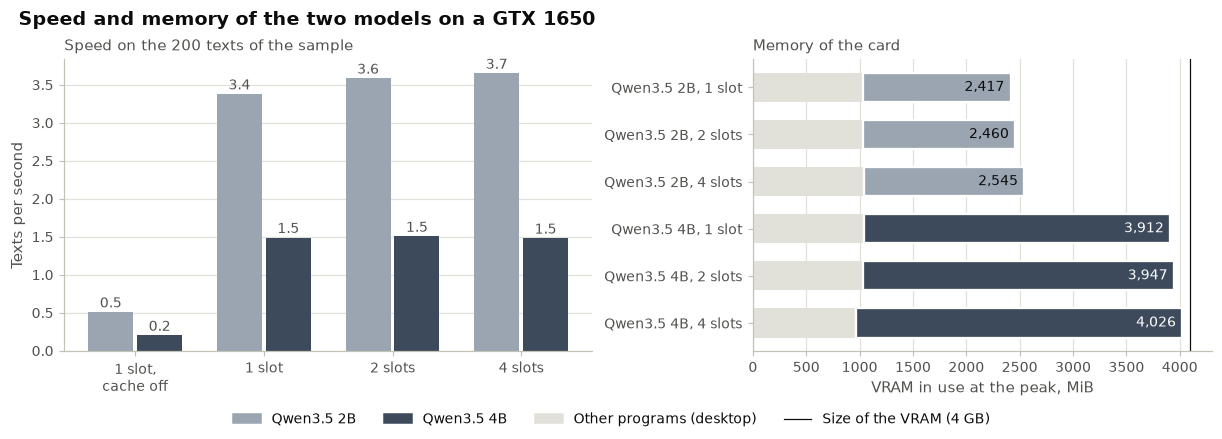

time for all 4,514,780 comments at the fastest setting that fits, if they were like the sample: Qwen3.5 2B 14 days, Qwen3.5 4B 35 days


In [23]:
LLM_NAME = {"qwen2b": "Qwen3.5 2B", "qwen4b": "Qwen3.5 4B"}
LLM_COLOR = {"qwen2b": "#9aa5b1", "qwen4b": "#3d4a5c"}       # one hue, darker for the larger model
VRAM_TOTAL_MIB = 4096

SLOT_NAME = {n: f"{n} slot" + "s" * (n > 1) for n in SLOTS}
SETTINGS = ["1 slot, cache off"] + list(SLOT_NAME.values())
runs = llm_benchmark.assign(setting=np.where(llm_benchmark["cache"], llm_benchmark["slots"].map(SLOT_NAME), SETTINGS[0]))
runs["setting"] = pd.Categorical(runs["setting"], SETTINGS, ordered=True)
runs = runs.sort_values(["model", "setting"])
speed = runs.pivot(index="setting", columns="model", values="texts_per_second").reindex(index=SETTINGS, columns=LLM_MODELS)
with_cache = runs.loc[runs["cache"]].set_index(["model", "slots"])

table = pd.DataFrame({
    "model": runs["model"].map(LLM_NAME),
    "setting": runs["setting"],
    "fits the GPU": runs["fits"].map({True: "yes", False: "no"}),
    "texts per second": runs["texts_per_second"].round(2),
    "prompt tokens from cache, %": (100 * runs["cached_share"]).round(0),
    "VRAM of the model, MiB": runs["model_dedicated_mib"].round(0),
    "shared GPU memory, MiB": runs["model_shared_mib"].round(0),
    "peak VRAM of the card, MiB": runs["vram_peak_mib"].round(0),
    "same labels as with 1 slot, %": (100 * runs["same_labels_as_one_slot"]).round(1),
}).reset_index(drop=True)
display(table)

fig, (ax_speed, ax_vram) = plt.subplots(1, 2, figsize=(11, 3.9), layout="constrained", width_ratios=[1.15, 1])
x_pos = np.arange(len(SETTINGS))
for j, m in enumerate(LLM_MODELS):
    bars = ax_speed.bar(x_pos + (j - 0.5) * 0.38, speed[m].fillna(0), width=0.35, color=LLM_COLOR[m], label=LLM_NAME[m])
    for rect, v in zip(bars, speed[m]):
        ax_speed.annotate("does\nnot fit" if np.isnan(v) else f"{v:.1f}", (rect.get_x() + rect.get_width() / 2, 0 if np.isnan(v) else v),
                          xytext=(0, 3), textcoords="offset points", ha="center", fontsize=9, color=INK_2)
ax_speed.set_xticks(x_pos, [s.replace(", ", ",\n") for s in SETTINGS])
ax_speed.set_ylabel("Texts per second")
ax_speed.set_title(f"Speed on the {len(sample)} texts of the sample")
ax_speed.grid(axis="x", visible=False)

rows = [(m, n) for m in LLM_MODELS for n in SLOTS]
y_pos = np.arange(len(rows))
other = np.array([with_cache.loc[row, "vram_other_mib"] for row in rows])
peak = np.array([with_cache.loc[row, "vram_peak_mib"] for row in rows])
ax_vram.barh(y_pos, other, height=0.62, color=GRID, label="Other programs (desktop)")
ax_vram.barh(y_pos, peak - other, left=other, height=0.62, color=[LLM_COLOR[m] for m, _ in rows], edgecolor="white", linewidth=1.5)
for yy, ((m, _), p, o) in enumerate(zip(rows, peak, other)):
    if np.isnan(p):
        ax_vram.text(o + 60, yy, "does not fit", va="center", fontsize=9, color=INK_2)
    else:
        ax_vram.text(p - 60, yy, f"{p:,.0f}", va="center", ha="right", fontsize=9, color=ink_on(LLM_COLOR[m]))
ax_vram.axvline(VRAM_TOTAL_MIB, color=INK, linewidth=0.8)
ax_vram.set_yticks(y_pos, [f"{LLM_NAME[m]}, {SLOT_NAME[n]}" for m, n in rows])
ax_vram.invert_yaxis()
ax_vram.set_xlim(0, VRAM_TOTAL_MIB * 1.05)
ax_vram.set_xlabel("VRAM in use at the peak, MiB")
ax_vram.set_title("Memory of the card")
ax_vram.grid(axis="y", visible=False)
fig.legend(handles=[Patch(color=LLM_COLOR[m], label=LLM_NAME[m]) for m in LLM_MODELS]
           + [Patch(color=GRID, label="Other programs (desktop)"), Line2D([], [], color=INK, linewidth=0.8, label="Size of the VRAM (4 GB)")],
           loc="outside lower center", ncols=4)
headline(fig, "Speed and memory of the two models on a GTX 1650")
plt.show()

n_all = pq.ParquetFile(COMMENTS_PATH).metadata.num_rows        # all comments of the dataset
fastest = with_cache.loc[with_cache["fits"]].groupby("model")["texts_per_second"].max()
print(f"time for all {n_all:,} comments at the fastest setting that fits, if they were like the sample: "
      + ", ".join(f"{LLM_NAME[m]} {n_all / fastest[m] / 86400:.0f} days" for m in LLM_MODELS))

**What we see.**

- The 2B model labels 3.4 texts per second and the 4B model 1.5 (2.3 times slower). The order of the prompt is the largest gain: with the prefix cache 89% of the prompt tokens are reused and the speed is about 7 times higher.
- Parallel slots do not help (four slots: +8% for the 2B model, 0% for the 4B model) and change 1.5–4% of the labels through rounding, so one slot is used.
- The 4B model needs 2.9 GB and brings the card to 3.9 of 4.1 GB, with less than 200 MiB to spare. Shared GPU memory never grew (80–84 MiB), so nothing spilled to system RAM.

**What it means for the project.** At these speeds 4.5M comments would take about 14 days (2B) or 35 days (4B) of continuous work, so an LLM of this kind can label a sample, not the corpus.

### 2.5 The two LLMs next to the earlier models

**Questions:** are the LLMs closer to the manual labels than the three models of section 1, and do they find the supportive texts?

The cells below add the two LLMs to the list of models and draw the charts of sections 1.4 and 1.5 again with the same functions. The LLM score is the probability of `pro` minus the probability of `against` for the first word of the answer, so it runs from −1 to +1.

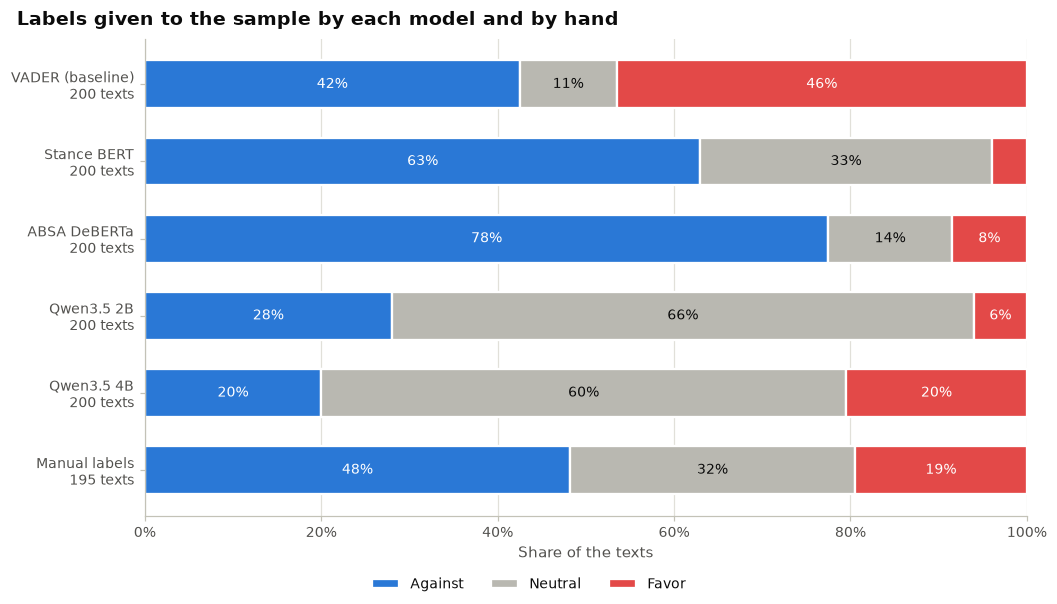

In [24]:
MODELS = [m for m in MODELS if m not in LLM_MODELS] + LLM_MODELS       # from here on, the charts of section 1 show five models
RATER_NAME.update(LLM_NAME)

assert HAS_LABELS and not (llm["label"] == "error").any()
for m in LLM_MODELS:
    one = llm.loc[llm["model"] == m].set_index("id")
    predictions[f"{m}_label"] = predictions["id"].map(one["label"])
    predictions[f"{m}_score"] = predictions["id"].map(one["score"])
results = (
    sample.merge(predictions, on="id", validate="one_to_one")
    .merge(labels, on="id", how="left", validate="one_to_one")
)
judged = results.loc[results["human"].isin(LABELS)]
raters = MODELS + ["human"]

plot_label_shares()

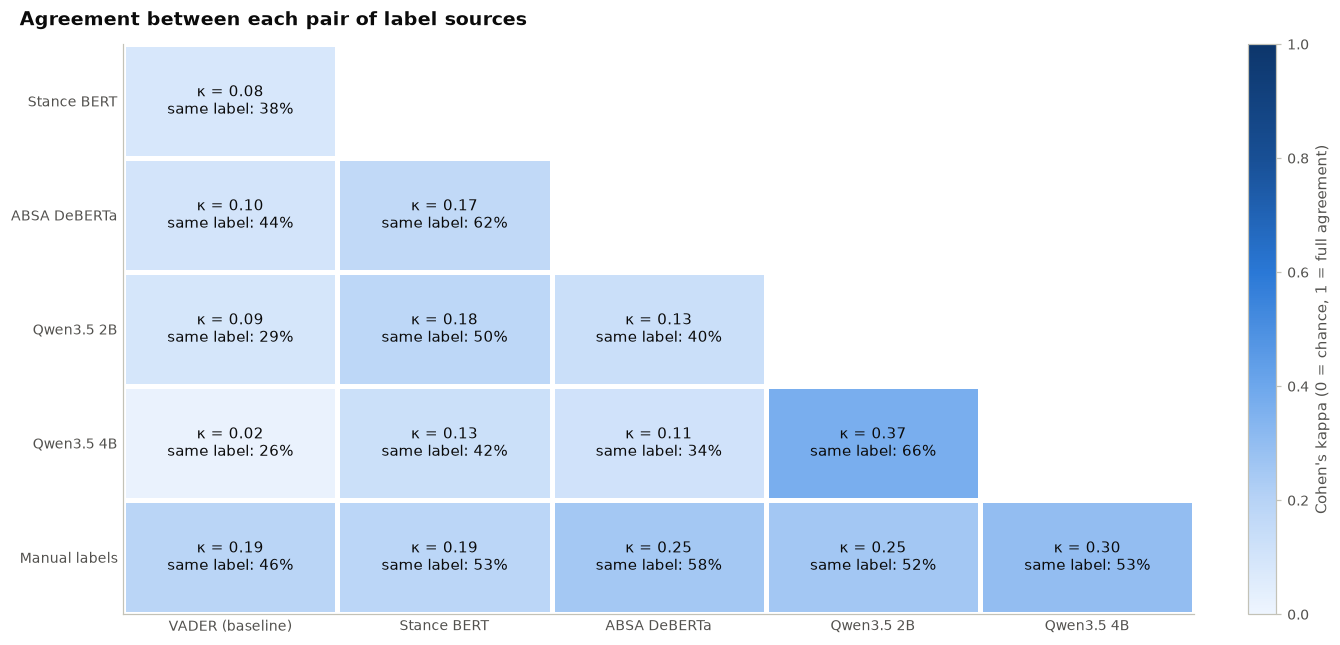

In [25]:
plot_agreement()

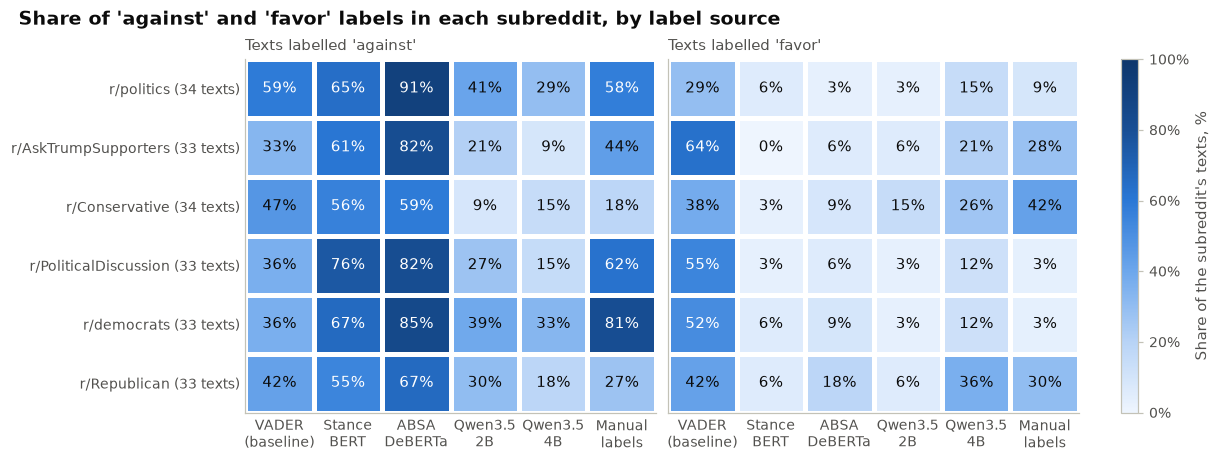

In [26]:
plot_subreddit_shares()

In [27]:
point, low, high, boot = evaluate()
summary = pd.DataFrame({
    s: [f"{point.loc[r, s]:.2f}  ({low.loc[r, s]:.2f} to {high.loc[r, s]:.2f})" for r in point.index] for s in SCORES
}, index=[ROW_NAME.get(r, RATER_NAME.get(r)) for r in point.index])
print(f"{len(judged)} labelled texts; each cell is the score and its 95% interval")
display(summary)
display(gaps(boot, point))

195 labelled texts; each cell is the score and its 95% interval


,accuracy,macro-F1,Cohen's kappa
VADER (baseline),0.46 (0.39 to 0.53),0.43 (0.36 to 0.50),0.19 (0.10 to 0.28)
Stance BERT,0.53 (0.46 to 0.60),0.42 (0.35 to 0.49),0.19 (0.08 to 0.29)
ABSA DeBERTa,0.58 (0.51 to 0.65),0.45 (0.38 to 0.53),0.25 (0.16 to 0.35)
Qwen3.5 2B,0.52 (0.45 to 0.59),0.46 (0.38 to 0.53),0.25 (0.15 to 0.35)
Qwen3.5 4B,0.53 (0.46 to 0.60),0.52 (0.45 to 0.59),0.30 (0.20 to 0.39)
Majority baseline (always 'against'),0.48 (0.41 to 0.55),0.22 (0.19 to 0.24),0.00 (0.00 to 0.00)


,difference in macro-F1,95% interval,interval excludes 0
Stance BERT minus VADER (baseline),-0.01,-0.11 to +0.08,no
ABSA DeBERTa minus VADER (baseline),+0.02,-0.07 to +0.12,no
ABSA DeBERTa minus Stance BERT,+0.04,-0.06 to +0.14,no
Qwen3.5 2B minus VADER (baseline),+0.03,-0.07 to +0.13,no
Qwen3.5 2B minus Stance BERT,+0.04,-0.05 to +0.13,no
Qwen3.5 2B minus ABSA DeBERTa,+0.00,-0.10 to +0.10,no
Qwen3.5 4B minus VADER (baseline),+0.09,-0.01 to +0.19,no
Qwen3.5 4B minus Stance BERT,+0.11,+0.01 to +0.20,yes
Qwen3.5 4B minus ABSA DeBERTa,+0.07,-0.03 to +0.17,no
Qwen3.5 4B minus Qwen3.5 2B,+0.07,-0.02 to +0.15,no


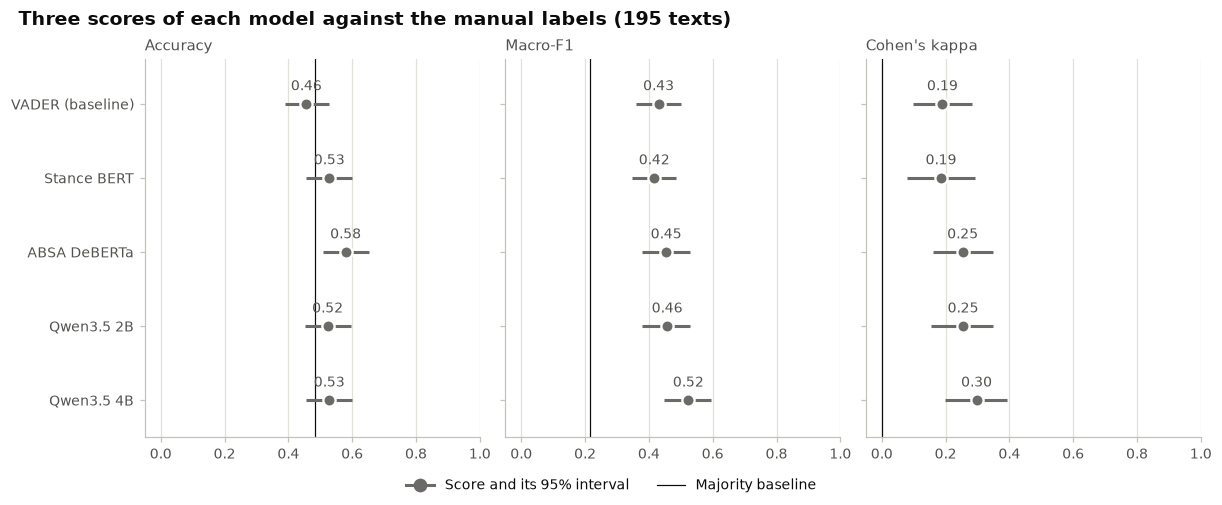

In [28]:
plot_scores()

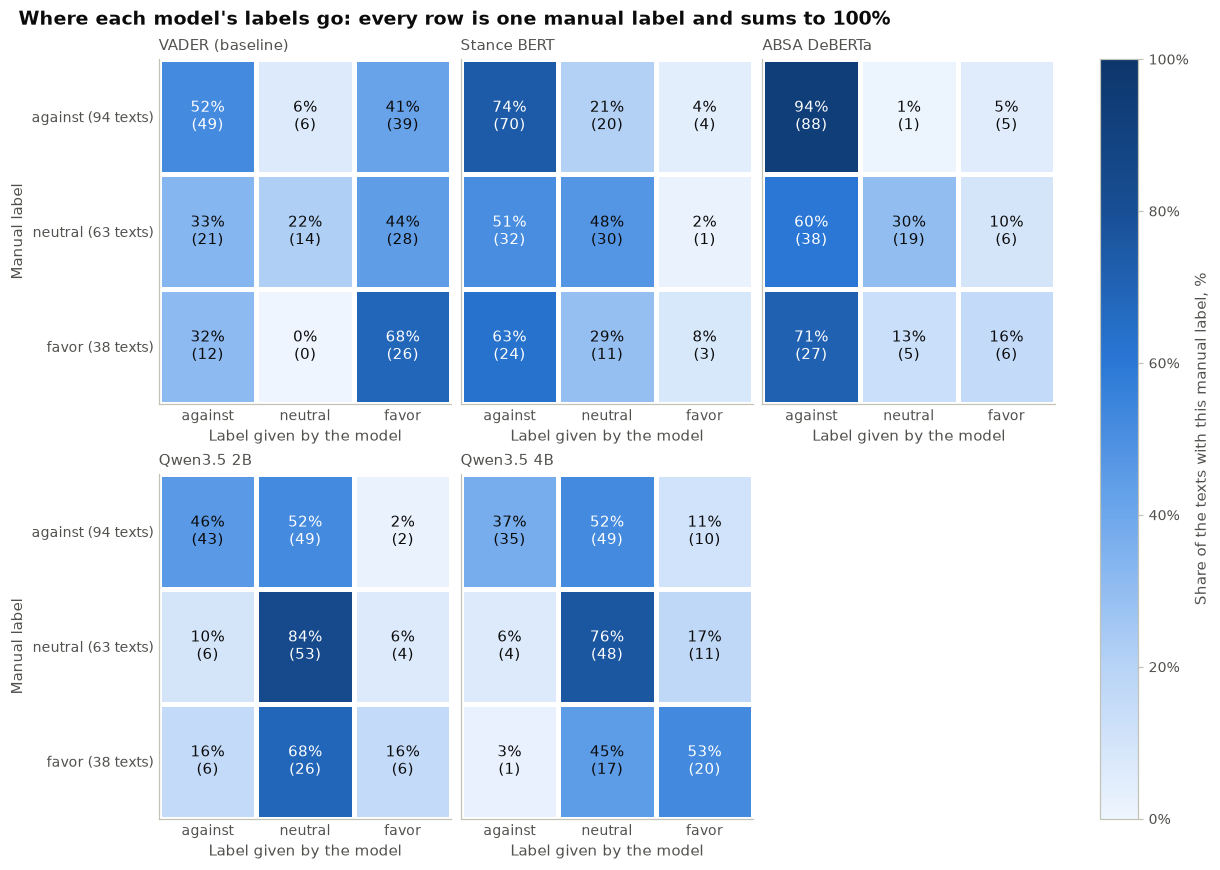

In [29]:
plot_confusion()

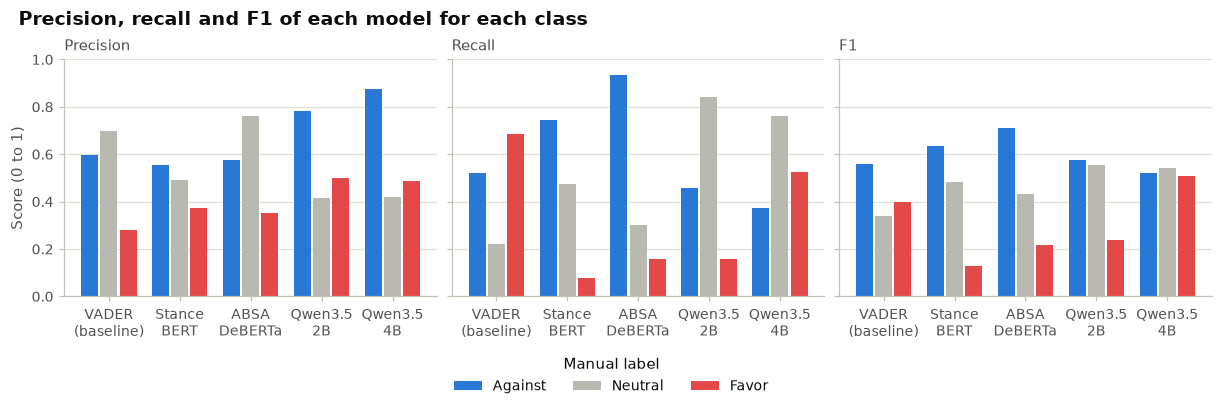

precision  recall    F1
VADER (baseline) against       0.60    0.52  0.56
                 neutral       0.70    0.22  0.34
                 favor         0.28    0.68  0.40
Stance BERT      against       0.56    0.74  0.64
                 neutral       0.49    0.48  0.48
                 favor         0.38    0.08  0.13
ABSA DeBERTa     against       0.58    0.94  0.71
                 neutral       0.76    0.30  0.43
                 favor         0.35    0.16  0.22
Qwen3.5 2B       against       0.78    0.46  0.58
                 neutral       0.41    0.84  0.55
                 favor         0.50    0.16  0.24
Qwen3.5 4B       against       0.88    0.37  0.52
                 neutral       0.42    0.76  0.54
                 favor         0.49    0.53  0.51

In [30]:
per_class = per_class_table()
plot_per_class(per_class)
display(per_class.round(2))

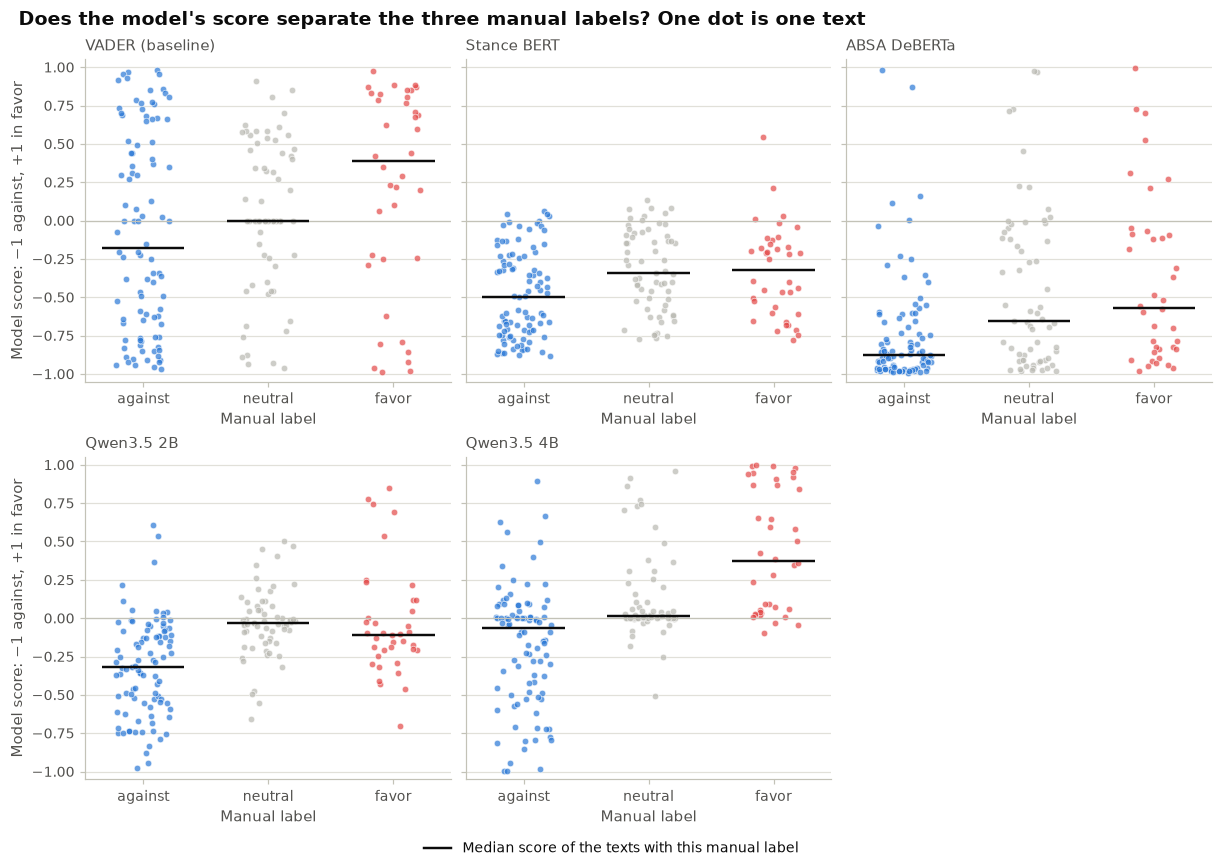

In [31]:
plot_signed_scores()

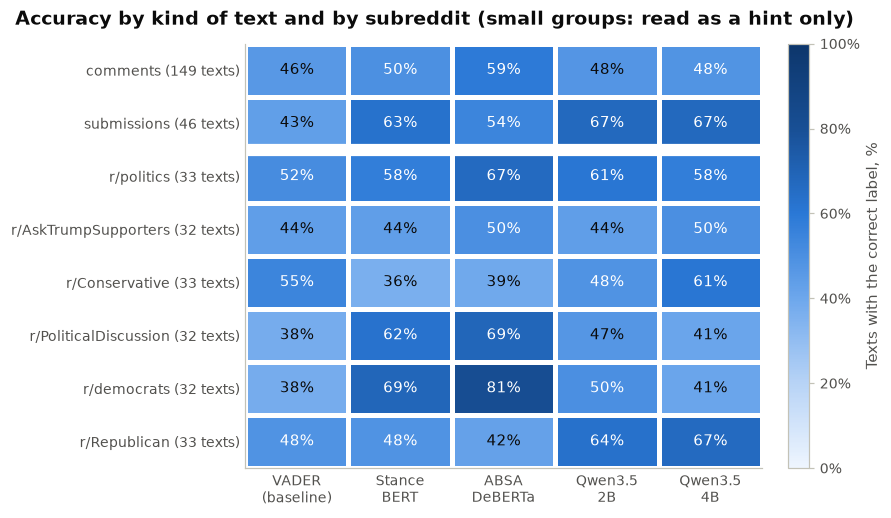

In [32]:
plot_accuracy_by_group()

**What we see.**

- The 4B model has the highest macro-F1 of the five, 0.52 (95% interval 0.45–0.59), and kappa 0.30. The 2B model (0.46) is at the level of the aspect-based model. The lead is small, only the gap to the stance model excludes zero (+0.01 to +0.20), and 4B against 2B is +0.07 (−0.02 to +0.15).
- On accuracy the LLMs are not better. 0.52 and 0.53, against 0.58 for the aspect-based model and 0.48 for the baseline that always answers `against`.
- The LLMs make a different mistake. The earlier models answer `against` most of the time. The LLMs answer `neutral`: 66% (2B) and 60% (4B) of the texts, where we gave `neutral` to 32%. Both label 52% of our `against` texts `neutral`.
- When they take a side they are mostly right about `against`. 88% of the `against` labels of the 4B model agree with ours (56–60% for the earlier models).
- The 4B model is the first to find the support. 20 of the 38 supportive texts (the stance, aspect-based and 2B models find 3, 6 and 6), most of it in r/Republican and r/Conservative. Its `favor` labels are still right only half of the time (20 of 41).
- The total share of `favor` from the 4B model (20%) is close to ours (19%), but this is partly luck: it misses 18 supportive texts and adds 21 that are not.
- Across subreddits the 4B model has the right direction. It finds most support in r/Republican (36%) and r/Conservative (26%), where we found 30% and 42%. It overstates support in the other communities: 12% in r/democrats and in r/PoliticalDiscussion, where we found 3%.
- The score of the 4B model is the first one with a median above zero for the supportive texts (+0.37), with −0.07 for `against` and +0.01 for `neutral`. The groups still overlap, and most scores of the `against` texts are close to zero: the model is not sure about them. The score of the 2B model does not separate `favor` from `neutral`.
- The errors moved to other communities. In r/Conservative and r/Republican the 4B model is right on 61% and 67% of the texts, where the two transformer models reached 36% to 48%. In r/democrats and r/PoliticalDiscussion it is right on 41%, where the aspect-based model reached 81% and 69% by answering `against`.
- Both LLMs are better on submissions (67%) than on comments (48%).
- The two LLMs agree with each other more than any other pair of models (kappa 0.37, the same label on 66% of the texts), and with the earlier models they agree no more than those agree with each other (kappa 0.02 to 0.18).

**What it means for the project.**

The 4B model is worth developing, but it is not yet a measuring tool. It hides half of the opposition behind `neutral`, so a share of `against` taken from it would be 20% where we see 48%. The 2B model is twice as fast and not better than section 1. Of the two, only the 4B model is worth developing.

### 2.6 Where the LLMs are still wrong

**Questions:** do the two models fail on the same texts, and what kind of text does the larger one get wrong?

In [33]:
BEST = "qwen4b"
N_SHOWN = 20          # wrong answers listed, the most confident first

both = pd.crosstab(judged["qwen2b_label"] == judged["human"], judged["qwen4b_label"] == judged["human"]).reindex(index=[True, False], columns=[True, False], fill_value=0)
both.index = [f"{LLM_NAME['qwen2b']} right", f"{LLM_NAME['qwen2b']} wrong"]
both.columns = [f"{LLM_NAME['qwen4b']} right", f"{LLM_NAME['qwen4b']} wrong"]
print(f"the two models give the same label to {100 * (results['qwen2b_label'] == results['qwen4b_label']).mean():.0f}% of the {len(results)} texts")
display(both)

by_part = {m: 100 * (judged[f"{m}_label"] == judged["human"]).groupby(judged["part"]).mean() for m in LLM_MODELS}
print("accuracy on the texts labelled by the first and by the second of us: "
      + ", ".join(f"{LLM_NAME[m]} {by_part[m][1]:.0f}% and {by_part[m][2]:.0f}%" for m in LLM_MODELS))

question = judged["text"].str.strip().str.endswith("?")
print(f"{question.sum()} texts end with a question mark; manual labels: "
      + ", ".join(f"{n} {label}" for label, n in judged.loc[question, "human"].value_counts().items())
      + f"; {LLM_NAME[BEST]}: " + ", ".join(f"{n} {label}" for label, n in judged.loc[question, f"{BEST}_label"].value_counts().items()))

wrong = judged.loc[judged[f"{BEST}_label"] != judged["human"]]
kinds = wrong.groupby(["human", f"{BEST}_label"]).size().sort_values(ascending=False)
print(f"{LLM_NAME[BEST]} is wrong on {len(wrong)} of {len(judged)} texts: "
      + ", ".join(f"{n} {manual} read as {model}" for (manual, model), n in kinds.items()))
proba = llm.loc[llm["model"] == BEST].set_index("id")
shown = wrong.assign(confidence=[proba.at[i, f"p_{label}"] for i, label in zip(wrong["id"], wrong[f"{BEST}_label"])])
shown = shown.sort_values("confidence", ascending=False).head(N_SHOWN)
with pd.option_context("display.max_colwidth", TEXT_CHARS):
    display(pd.DataFrame({
        "kind": shown["kind"],
        "subreddit": shown["subreddit"],
        "text": shown["text"].str.replace(r"\s+", " ", regex=True).str.slice(0, TEXT_CHARS),
        "manual": shown["human"],
        LLM_NAME["qwen2b"]: shown["qwen2b_label"],
        LLM_NAME["qwen4b"]: shown["qwen4b_label"],
        "probability of its label": shown["confidence"].round(2),
    }).reset_index(drop=True))

the two models give the same label to 66% of the 200 texts


,Qwen3.5 4B right,Qwen3.5 4B wrong
Qwen3.5 2B right,75,27
Qwen3.5 2B wrong,28,65


accuracy on the texts labelled by the first and by the second of us: Qwen3.5 2B 60% and 44%, Qwen3.5 4B 59% and 46%
34 texts end with a question mark; manual labels: 18 against, 13 neutral, 3 favor; Qwen3.5 4B: 29 neutral, 3 against, 2 favor
Qwen3.5 4B is wrong on 92 of 195 texts: 49 against read as neutral, 17 favor read as neutral, 11 neutral read as favor, 10 against read as favor, 4 neutral read as against, 1 favor read as against


,kind,subreddit,text,manual,Qwen3.5 2B,Qwen3.5 4B,probability of its label
0,submission,PoliticalDiscussion,"What was turning point, in your opinion, where continuing to support Trump as your President became anti-American?",against,neutral,neutral,1.00
1,comment,AskTrumpSupporters,"I get that there's a problem with bills that are so long (like ACA) that it's impractical to read and understand the whole implication, but what's the benef...",against,neutral,neutral,1.00
2,submission,AskTrumpSupporters,"Would you have still voted for Donald Trump if he campaigned on cutting medicaid, adding $7 trillion to the debt, and fighting legal cannabis?",against,neutral,neutral,1.00
3,submission,Conservative,Carl Bernstein Calls Trump Aide Kellyanne Conway a 'Propaganda Minister',against,neutral,neutral,1.00
4,comment,AskTrumpSupporters,"Is there any constitutional right trump supporters won’t give up, if he asks?",against,neutral,neutral,1.00
5,submission,PoliticalDiscussion,Why is Donald Trump so threatened by intelligent successful women like Oprah and Hillary Clinton?,against,neutral,neutral,1.00
6,submission,AskTrumpSupporters,"What had made you vote for Trump during 2016, 2020 & 2024? How many times had you voted for him if you were eligible? And were you a former liberal & used t...",favor,neutral,neutral,1.00
7,submission,AskTrumpSupporters,"What is the first benefit I should be looking forward to under a Trump presidency? I'm about 1,000% bored with the ""well what about this?!??"" posts in this ...",against,neutral,neutral,0.99
8,comment,AskTrumpSupporters,"Sure, that's a thing but I feel like anyone he is attempting to negotiate with would just burst out in laughter at the ""threat"" of ending all trade with all...",against,neutral,neutral,0.99
9,comment,PoliticalDiscussion,"Not a Trump fan but I don't think there's much, if anything, to be read from who Mueller is hiring. Yes, he's hiring experienced prosecutors from a variety ...",favor,neutral,neutral,0.98


**What we see.**

- The two models are right together on 75 texts and wrong together on 65. Each is right alone on 27 or 28 texts, so the larger model does not simply correct the smaller one.
- The 4B model is wrong on 92 of 195 texts, and 66 of these are a neutral answer for a text where we saw a position (49 against, 17 favor).
- Many of these texts are questions. 34 labelled texts end with a question mark. We read 18 of them as `against`, because the question itself carries the criticism ("Why is Donald Trump so threatened by intelligent successful women…?"). The model answers `neutral` for 29 of the 34. Our instruction lists "a question" among the neutral cases, and the model follows it to the letter.
- Some rows are our own inconsistency and not an error of the model. "Carl Bernstein Calls Trump Aide Kellyanne Conway a 'Propaganda Minister'" is a headline that reports what somebody said, which is `neutral` by rule 3, and it has the manual label `against`.
- The 10 texts read as `favor` in place of `against` include statements that need the whole sentence to be understood: "I voted for [him] 3 times. I am a fool" is read as support.
- Both models agree more with the first of us than with the second (59–60% against 44–46%), who has more against labels: we draw the against/neutral line differently, and the models are closer to the stricter reading

**What it means for the project.** A large part of the gap between the model and the manual labels is the line between "no clear position" and "criticism in the form of a question or a hint". That line is not fixed in our own labels, so the scores of 2.5 mix errors of the model with disagreement about the rule.

### 2.7 Summary

**Result.**

1. The 4B model is the best of the five models on macro-F1 (0.52) and the first that finds support for Trump (20 of 38 supportive texts, where the earlier transformer models found 3 and 6). Its lead over the earlier models is at the edge of what 195 texts can show.
2. The 2B model is at the level of the models of section 1.
3. Both LLMs answer `neutral` about twice as often as we do. This is now the main error, and it is tied to our own rule that a question is neutral.
4. The speed is 3.4 texts per second for the 2B model and 1.5 for the 4B model. The prefix cache makes both about 7 times faster; parallel slots give nothing on this card.

**Limits**

- The prompt was written once and not tuned. With one labelled set of 195 texts there is nothing left to tune on: any change made after looking at these scores would have to be tested on new labelled texts.
- The manual labels are one person's opinion on each text, and the two of us do not draw the `against`/`neutral` line in the same place (section 2.6). Each text was labelled by one annotator. Because the two annotators labelled different texts, we cannot separate annotator disagreement from differences between the two subsets. A double-labelled sample would be needed to estimate inter-annotator agreement.
- The models are 4-bit files chosen to fit 4 GB. A larger model, or the same model with thinking switched on, may do better and would be many times slower on this hardware.
- The speed was measured on texts of at most 250 words.

But Qwen3.5 4B is not treated as ground truth. It is the strongest feasible teacher among the models tested locally: it has the highest macro-F1, recovers substantially more supportive texts than the earlier models and fits on the available 4 GB GPU. Paid API models were outside the project budge

## 3. Does the post help? The 4B model with the text of the submission

In section 2 the model saw a comment alone. A person who reads a thread also sees the post under which the comment was written, and many comments cannot be understood without it. Does giving the 4B model the post improve its labels?

| Step | What happens |
|---|---|
| 3.1 | The post of every comment is found through `submission_id` |
| 3.2 | The prompt gets the post before the comment; the examples get posts too |
| 3.3 | The 4B model labels the 150 comments again |
| 3.4 | The charts of sections 1.5 and 2.5, now for the comments only and with six models |
| 3.5 | The comments whose label changed |

### 3.1 The post of each comment

**Question:** can the post be found for every comment, and how long is it?

Every comment has a submission_id, the id of its post in the submissions table. The text of a post is its title and, for a text post, its body. The posts of the sample are saved to data/sentiment/sample_posts.csv.

In [34]:
CONTEXT = "qwen4b_post"               # name of this run: the 4B model that also reads the post
CONTEXT_PROMPT_VERSION = "v2-post"
POST_MAX_CHARS = 1000                 # a longer post is cut at the end
NO_POST = "(the post is not available)"
RESCORE_CONTEXT = False               # True runs the model again even when saved predictions exist

POSTS_PATH = SENT_DIR / "sample_posts.csv"
CONTEXT_PREDICTIONS_PATH = SENT_DIR / "llm_post_predictions.csv"
CONTEXT_CONFIG_PATH = SENT_DIR / "llm_post_run_config.json"


def find_posts():
    """The post of every comment of the sample: the comment's `submission_id` is the `id` of the post."""
    ids = sample.loc[sample["kind"] == "comment", "id"].tolist()
    link = pq.read_table(COMMENTS_PATH, columns=["id", "submission_id", "is_top_level"], filters=[("id", "in", ids)]).to_pandas()
    found = pq.read_table(SUBMISSIONS_PATH, columns=["id", "text_clean"], filters=[("id", "in", link["submission_id"].unique().tolist())]).to_pandas()
    found = found.rename(columns={"id": "submission_id", "text_clean": "post"})       # the title and, for a text post, its body
    return link.merge(found, on="submission_id", how="left", validate="many_to_one")


if not POSTS_PATH.exists():
    find_posts().to_csv(POSTS_PATH, index=False, lineterminator="\n")
posts = pd.read_csv(POSTS_PATH, dtype={"id": str, "submission_id": str})
comments = sample.loc[sample["kind"] == "comment"].merge(posts, on="id", validate="one_to_one").reset_index(drop=True)
comments["post"] = comments["post"].fillna("").str.strip()

has_post = comments["post"] != ""
length = comments.loc[has_post, "post"].str.len()
print(f"{len(comments)} comments; the post is found for {has_post.sum()} of them, {len(comments) - has_post.sum()} get the note {NO_POST!r}")
print(f"length of a post: median {length.median():.0f} characters, longest {length.max():,}; {(length > POST_MAX_CHARS).sum()} posts are cut at {POST_MAX_CHARS:,}")
print(f"{100 * comments['is_top_level'].mean():.0f}% of the comments answer the post directly; the others answer another comment")

150 comments; the post is found for 147 of them, 3 get the note '(the post is not available)'
length of a post: median 104 characters, longest 2,772; 15 posts are cut at 1,000
39% of the comments answer the post directly; the others answer another comment


### 3.2 The prompt with the post

**Question:** how is the post given to the model?

The instruction gets one new paragraph: the model receives the post and then the comment, the post is only context, and the label is the position of the author of the comment. The labels and the rules are not changed.

The examples must have the same form as the real requests, so each of the ten examples of section 2.2 gets a post. Three short examples are added, because this is the case the post is for. The examples are again written by us and are not texts of the sample.

This is prompt version `v2-post`. Like version 1, it was written before its scores were seen and was not changed afterwards.

In [35]:
POST_SYSTEM_PROMPT = SYSTEM_PROMPT.replace(
    "You classify the stance of the author of a Reddit text toward Donald Trump.",
    "You classify the stance of the author of a Reddit comment toward Donald Trump.\n\n"
    "You receive the post under which the comment was written, and then the comment. The post is only context: it shows what the comment is about. "
    "Classify the position of the author of the comment, not of the post.")
assert POST_SYSTEM_PROMPT != SYSTEM_PROMPT

# the ten comments of section 2.2 with a post added (the headline became a comment under that headline), and three short comments that cannot be read without the post
POST_FEW_SHOT = [
    ("CNN panel calls Trump's press conference 'unhinged'",
     "The media is so dishonest it's disgusting. They twist every single thing Trump says and then act shocked when nobody trusts them anymore.", "pro"),
    ("Appeals court refuses to reinstate Trump's travel ban",
     "Best news all week! The court just threw out his travel ban again. Pop the champagne, folks.", "against"),
    ("Trump signs executive order on steel and aluminum tariffs",
     "The order takes effect in 15 days and exempts Canada and Mexico for now.", "neutral"),
    ("Trump calls himself 'a very stable genius'",
     "Oh sure, Trump is definitely a stable genius. Nothing says genius like bankrupting a casino. /s", "against"),
    ("Trump announces new tariffs on Chinese goods",
     "Can someone explain how the tariffs Trump announced actually work? Who pays them, the importer or the exporter?", "neutral"),
    ("Economists warn that Trump's policies could slow growth",
     "Yeah, because the economy was doing SO great before Trump took office. /s", "pro"),
    ("Democrats search for a message after their election losses",
     "With or without Trump on the ballot, the Democrats have no message at all. They lost the working class years ago and still don't understand why.", "neutral"),
    ("Fact check: Trump's claims about the size of the inauguration crowd",
     "He lied about the crowd size on day one and he has not stopped lying since. This administration is a disgrace.", "against"),
    ("One year in: how do Trump voters feel now?",
     "I don't like his tweets, but the tax cut and the judges are exactly what I voted for. He is delivering.", "pro"),
    ("Weekend open thread",
     "My rent went up again and I spent the whole weekend fixing my car. At least the Trump debate on TV was good background noise.", "neutral"),
    ("Trump fires FBI director James Comey",
     "About time. Should have happened on day one.", "pro"),
    ("Trump's approval rating falls to a new low",
     "Couldn't happen to a nicer guy.", "against"),
    ("Senate confirms Trump's Supreme Court nominee",
     "Who was the last nominee that got confirmed this fast?", "neutral"),
]
assert not set(comment for _, comment, _ in POST_FEW_SHOT) & set(sample["text"])


def post_turn(post, comment):
    return {"role": "user", "content": f"Post:\n{post[:POST_MAX_CHARS] or NO_POST}\n\nComment:\n{comment[:TEXT_MAX_CHARS]}"}


# as in section 2.2, everything before the last message is the same in every request and is reused from the cache
POST_STATIC_MESSAGES = [{"role": "system", "content": POST_SYSTEM_PROMPT}]
for example_post, example, answer in POST_FEW_SHOT:
    POST_STATIC_MESSAGES += [post_turn(example_post, example), {"role": "assistant", "content": answer}]


def build_post_messages(post, comment):
    return POST_STATIC_MESSAGES + [post_turn(post, comment)]


print(f"prompt {CONTEXT_PROMPT_VERSION}: system instruction, {len(POST_FEW_SHOT)} examples "
      f"({', '.join(f'{n} {label}' for label, n in pd.Series([a for _, _, a in POST_FEW_SHOT]).value_counts().items())}), then the post and the comment\n")
print(POST_SYSTEM_PROMPT.split("\n\nAnswer with")[0])
print("\n(the labels and the six rules are the same as in section 2.2)\n")
print(post_turn("<the post: its title and, for a text post, its body>", "<the comment>")["content"])
display(pd.DataFrame(POST_FEW_SHOT, columns=["post", "comment", "answer"]))

prompt v2-post: system instruction, 13 examples (5 neutral, 4 pro, 4 against), then the post and the comment

You classify the stance of the author of a Reddit comment toward Donald Trump.

You receive the post under which the comment was written, and then the comment. The post is only context: it shows what the comment is about. Classify the position of the author of the comment, not of the post.

(the labels and the six rules are the same as in section 2.2)

Post:
<the post: its title and, for a text post, its body>

Comment:
<the comment>


,post,comment,answer
0,CNN panel calls Trump's press conference 'unhinged',The media is so dishonest it's disgusting. They twist every single thing Trump says and then act shocked when nobody trusts th...,pro
1,Appeals court refuses to reinstate Trump's travel ban,"Best news all week! The court just threw out his travel ban again. Pop the champagne, folks.",against
2,Trump signs executive order on steel and aluminum tariffs,The order takes effect in 15 days and exempts Canada and Mexico for now.,neutral
3,Trump calls himself 'a very stable genius',"Oh sure, Trump is definitely a stable genius. Nothing says genius like bankrupting a casino. /s",against
4,Trump announces new tariffs on Chinese goods,"Can someone explain how the tariffs Trump announced actually work? Who pays them, the importer or the exporter?",neutral
5,Economists warn that Trump's policies could slow growth,"Yeah, because the economy was doing SO great before Trump took office. /s",pro
6,Democrats search for a message after their election losses,"With or without Trump on the ballot, the Democrats have no message at all. They lost the working class years ago and still don...",neutral
7,Fact check: Trump's claims about the size of the inauguration crowd,He lied about the crowd size on day one and he has not stopped lying since. This administration is a disgrace.,against
8,One year in: how do Trump voters feel now?,"I don't like his tweets, but the tax cut and the judges are exactly what I voted for. He is delivering.",pro
9,Weekend open thread,My rent went up again and I spent the whole weekend fixing my car. At least the Trump debate on TV was good background noise.,neutral


### 3.3 Running the model

The same server and checks as in 2.3, with one slot (section 2.4 showed that more slots give no speed). Answers: `data/sentiment/llm_post_predictions.csv`.

In [36]:
def run_best(name, version, prompts, ids, static_messages, control, predictions_path, config_path, **limits):
    """The 4B model, the same file and settings as in section 2, on ready prompts. Saves the answers and the settings of the run.
    `control` turns a control sentence into a prompt of this version."""
    path = MODEL_DIR / llm_config["models"][BEST]["file"]
    with LlamaServer(path, slots=1) as server:
        checks = server.check(build=control)
        server.classify(prompts[0])                              # fills the prefix cache before the clock starts
        rows, speed = server.run(prompts)
        again, _ = server.run(prompts)
        assert (again["label"] == rows["label"]).all(), "two runs gave different labels"
        flags = server.flags

    columns = ["id", "model", "prompt_version", "label", "raw_output", "score", *[f"p_{label}" for label in LABELS], "prompt_tokens", "cached_tokens", "seconds"]
    rows.assign(id=list(ids), model=name, prompt_version=version)[columns].to_csv(predictions_path, index=False, lineterminator="\n")
    config = {
        "prompt_version": version, "prompt_sha256": sha256(json.dumps(static_messages)), "seed": SEED,
        "llama_cpp": LLAMA_BUILD, "generation": GENERATION, "context_per_slot": CTX_PER_SLOT, "text_max_chars": TEXT_MAX_CHARS, **limits,
        "model": {k: llm_config["models"][BEST][k] for k in ["repo", "file", "quantisation", "size_gb", "sha256"]},
        "server_flags": " ".join(flags), **checks, "speed": {k: round(float(v), 3) for k, v in speed.items()},
        "run_at": time.strftime("%Y-%m-%d %H:%M"),
    }
    config_path.write_text(json.dumps(config, indent=2), encoding="utf-8")


def is_saved(predictions_path, version, ids):
    """True when the saved answers are for these texts and this version of the prompt."""
    if not predictions_path.exists():
        return False
    saved = pd.read_csv(predictions_path, dtype={"id": str})
    return set(saved["id"]) == set(ids) and set(saved["prompt_version"]) == {version}


if RESCORE_CONTEXT or not is_saved(CONTEXT_PREDICTIONS_PATH, CONTEXT_PROMPT_VERSION, comments["id"]):
    run_best(CONTEXT, CONTEXT_PROMPT_VERSION, [build_post_messages(post, comment) for post, comment in zip(comments["post"], comments["text"])],
             comments["id"], POST_STATIC_MESSAGES, lambda text: build_post_messages("Trump holds a rally in Ohio", text),
             CONTEXT_PREDICTIONS_PATH, CONTEXT_CONFIG_PATH, post_max_chars=POST_MAX_CHARS)
llm_post = pd.read_csv(CONTEXT_PREDICTIONS_PATH, dtype={"id": str}, keep_default_na=False, na_values=[""])
post_config = json.loads(CONTEXT_CONFIG_PATH.read_text(encoding="utf-8"))

errors = llm_post.loc[llm_post["label"] == "error"]
print(f"{len(llm_post)} answers, prompt {CONTEXT_PROMPT_VERSION}; {len(errors)} answers are not a label" + (":" if len(errors) else ""))
if len(errors):
    display(errors[["id", "raw_output"]])
without = llm.loc[(llm["model"] == BEST) & llm["id"].isin(comments["id"])]
alone = llm_benchmark.loc[(llm_benchmark["model"] == BEST) & (llm_benchmark["slots"] == 1) & llm_benchmark["cache"]].iloc[0]
print(f"prompt length, median and longest: {without['prompt_tokens'].median():.0f} and {without['prompt_tokens'].max():.0f} tokens without the post, "
      f"{llm_post['prompt_tokens'].median():.0f} and {llm_post['prompt_tokens'].max():.0f} with it (context: {CTX_PER_SLOT})")
print(f"speed: {post_config['speed']['texts_per_second']:.2f} comments per second with the post "
      f"({100 * post_config['speed']['cached_share']:.0f}% of the prompt tokens from the cache), {alone['texts_per_second']:.2f} texts per second without it")
print(f"VRAM: {post_config['speed']['model_dedicated_mib']:,.0f} MiB for the model, {post_config['speed']['vram_peak_mib']:,.0f} MiB on the card at the peak, "
      f"{post_config['speed']['model_shared_mib']:.0f} MiB of shared GPU memory; layers on the GPU: {post_config['layers_on_gpu']}")
print(json.dumps({k: v for k, v in post_config.items() if k != "speed"}, indent=2))

150 answers, prompt v2-post; 0 answers are not a label
prompt length, median and longest: 730 and 980 tokens without the post, 1072 and 1431 with it (context: 2048)
speed: 0.85 comments per second with the post (86% of the prompt tokens from the cache), 1.49 texts per second without it
VRAM: 2,863 MiB for the model, 3,946 MiB on the card at the peak, 82 MiB of shared GPU memory; layers on the GPU: 33/33
{
  "prompt_version": "v2-post",
  "prompt_sha256": "c430661f3b522cba32fcdab1f580276e5c011eaaab56d6e3d44fbb9e74ea141a",
  "seed": 42,
  "llama_cpp": "b11146",
  "generation": {
    "temperature": 0,
    "max_tokens": 5,
    "seed": 42,
    "cache_prompt": true,
    "chat_template_kwargs": {
      "enable_thinking": false
    },
    "grammar": "root ::= \"pro\" | \"against\" | \"neutral\"",
    "logprobs": true,
    "top_logprobs": 20
  },
  "context_per_slot": 2048,
  "text_max_chars": 4000,
  "post_max_chars": 1000,
  "model": {
    "repo": "unsloth/Qwen3.5-4B-GGUF",
    "file": "Qwen3

**What we see.**

- The post is found for 147 of the 150 comments. Most posts are a title only (median 104 characters); 15 long text posts are cut at 1,000 characters.
- 39% of the comments answer the post directly. The other 61% answer another comment, which the model does not see.
- All technical checks pass: 33/33 layers are on the GPU, shared memory does not grow, all 150 labels are valid, and the second run gives identical labels.
- Adding the post increases the median prompt from 730 to 1,072 tokens (maximum 1,431 of 2,048) and reduces speed from 1.5 to 0.85 texts/s. Memory stays the same at about 2.9 GB for the model. Because the post changes for every request, prefix caching cannot reuse it.

### 3.4 With and without the post

**Questions:** is the 4B model closer to the manual labels when it sees the post, and which errors change?

The scores are those of 1.5 for the 149 labelled comments only, so the numbers of the earlier models differ slightly from sections 1–2, where 46 submissions were included.

150 comments, 149 of them with a usable manual label: 80 against, 35 neutral, 34 favor


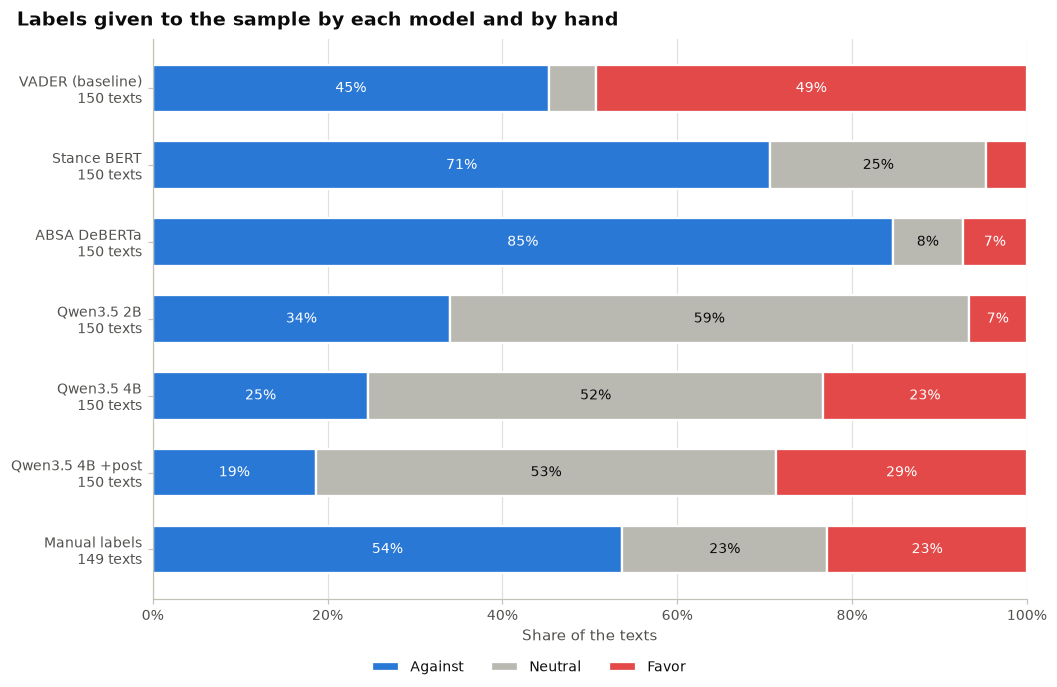

In [37]:
MODELS = [m for m in MODELS if m != CONTEXT] + [CONTEXT]          # from here on, the charts show six models on the comments of the sample
RATER_NAME[CONTEXT] = f"{LLM_NAME[BEST]} +post"

assert not (llm_post["label"] == "error").any()
with_post = llm_post.set_index("id")
predictions[f"{CONTEXT}_label"] = predictions["id"].map(with_post["label"])
predictions[f"{CONTEXT}_score"] = predictions["id"].map(with_post["score"])
results = (
    sample.merge(predictions, on="id", validate="one_to_one")
    .merge(labels, on="id", how="left", validate="one_to_one")
    .merge(posts[["id", "is_top_level"]], on="id", validate="one_to_one")       # keeps the comments only
)
judged = results.loc[results["human"].isin(LABELS)]
raters = MODELS + ["human"]
print(f"{len(results)} comments, {len(judged)} of them with a usable manual label: "
      + ", ".join(f"{n} {label}" for label, n in judged["human"].value_counts().reindex(LABELS).items()))

plot_label_shares()

In [38]:
point, low, high, boot = evaluate()
ROW_NAME = {**RATER_NAME, "majority": f"Majority baseline (always '{judged['human'].mode()[0]}')"}
summary = pd.DataFrame({
    s: [f"{point.loc[r, s]:.2f}  ({low.loc[r, s]:.2f} to {high.loc[r, s]:.2f})" for r in point.index] for s in SCORES
}, index=[ROW_NAME[r] for r in point.index])
print(f"{len(judged)} labelled comments; each cell is the score and its 95% interval")
display(summary)
all_gaps = gaps(boot, point)
display(all_gaps.loc[[name for name in all_gaps.index if name.startswith(RATER_NAME[CONTEXT])]])

149 labelled comments; each cell is the score and its 95% interval


,accuracy,macro-F1,Cohen's kappa
VADER (baseline),0.46 (0.38 to 0.54),0.39 (0.31 to 0.47),0.15 (0.04 to 0.26)
Stance BERT,0.50 (0.42 to 0.58),0.35 (0.28 to 0.43),0.09 (-0.03 to 0.20)
ABSA DeBERTa,0.59 (0.51 to 0.67),0.43 (0.34 to 0.52),0.20 (0.09 to 0.31)
Qwen3.5 2B,0.48 (0.40 to 0.56),0.43 (0.35 to 0.52),0.21 (0.11 to 0.32)
Qwen3.5 4B,0.48 (0.40 to 0.56),0.49 (0.41 to 0.57),0.25 (0.15 to 0.36)
Qwen3.5 4B +post,0.44 (0.36 to 0.52),0.44 (0.36 to 0.52),0.21 (0.11 to 0.31)
Majority baseline (always 'against'),0.54 (0.46 to 0.62),0.23 (0.21 to 0.25),0.00 (0.00 to 0.00)


,difference in macro-F1,95% interval,interval excludes 0
Qwen3.5 4B +post minus VADER (baseline),+0.05,-0.06 to +0.17,no
Qwen3.5 4B +post minus Stance BERT,+0.09,-0.02 to +0.20,no
Qwen3.5 4B +post minus ABSA DeBERTa,+0.01,-0.10 to +0.13,no
Qwen3.5 4B +post minus Qwen3.5 2B,+0.01,-0.08 to +0.10,no
Qwen3.5 4B +post minus Qwen3.5 4B,-0.04,-0.11 to +0.02,no


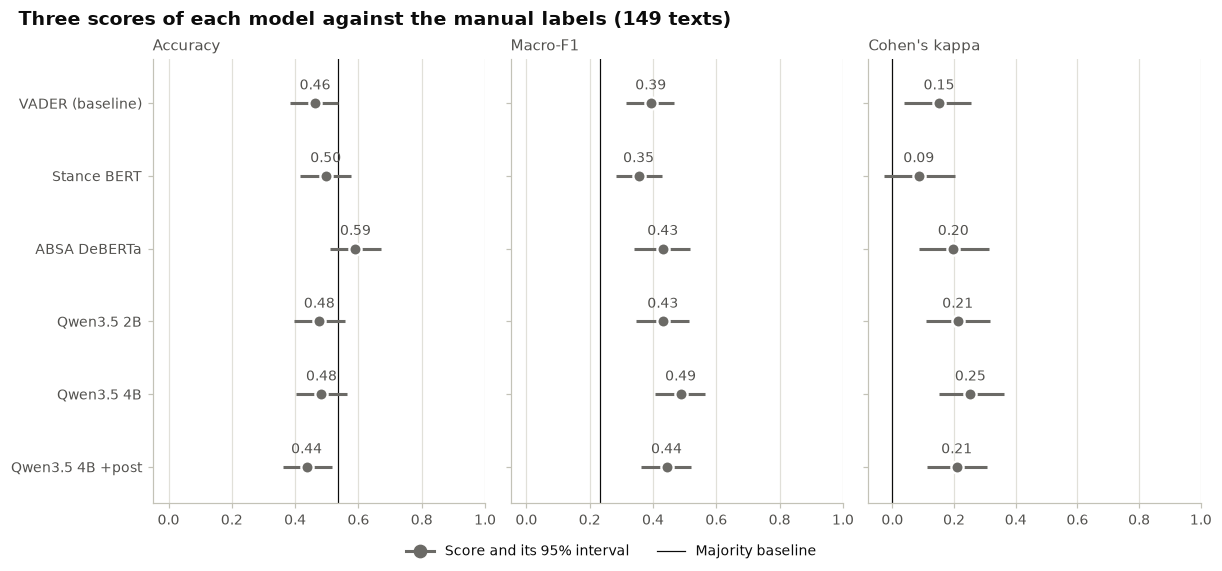

In [39]:
plot_scores()

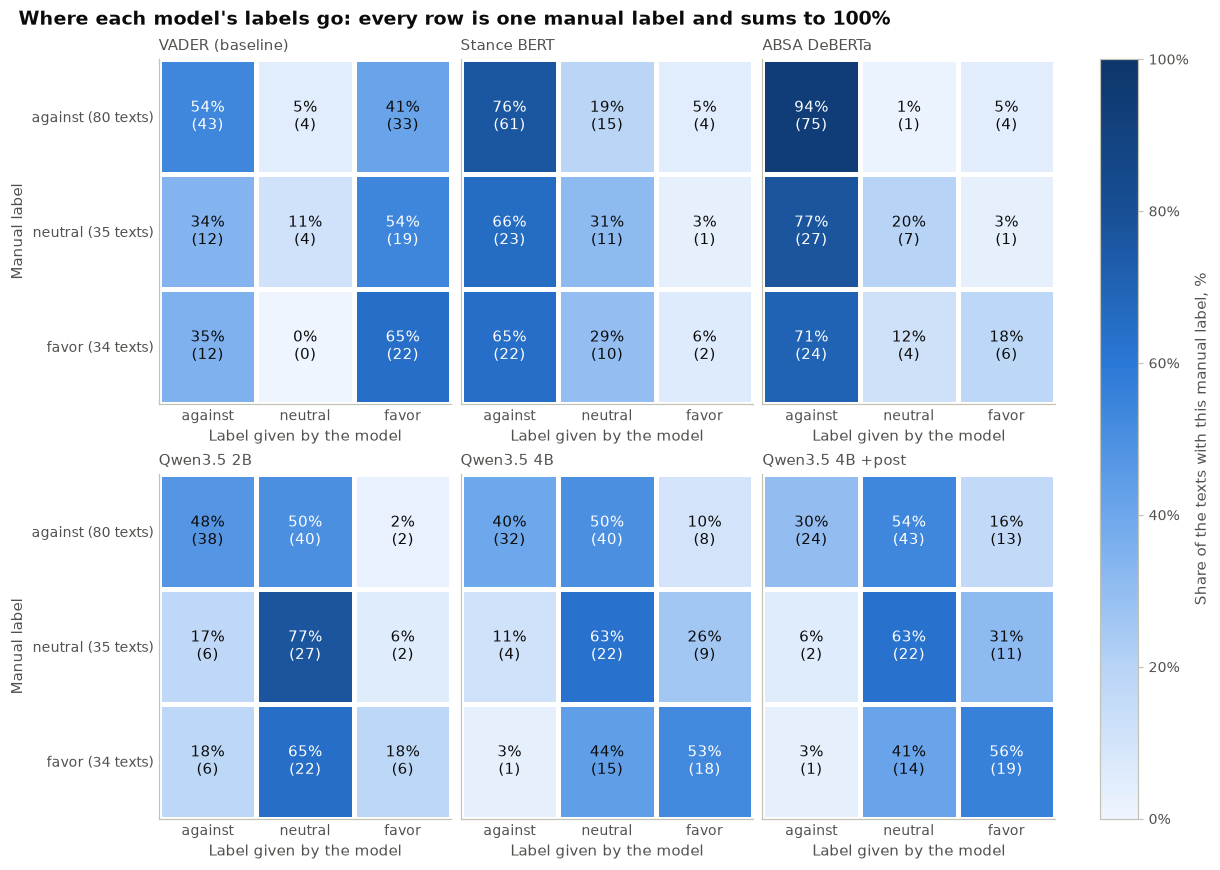

In [40]:
plot_confusion()

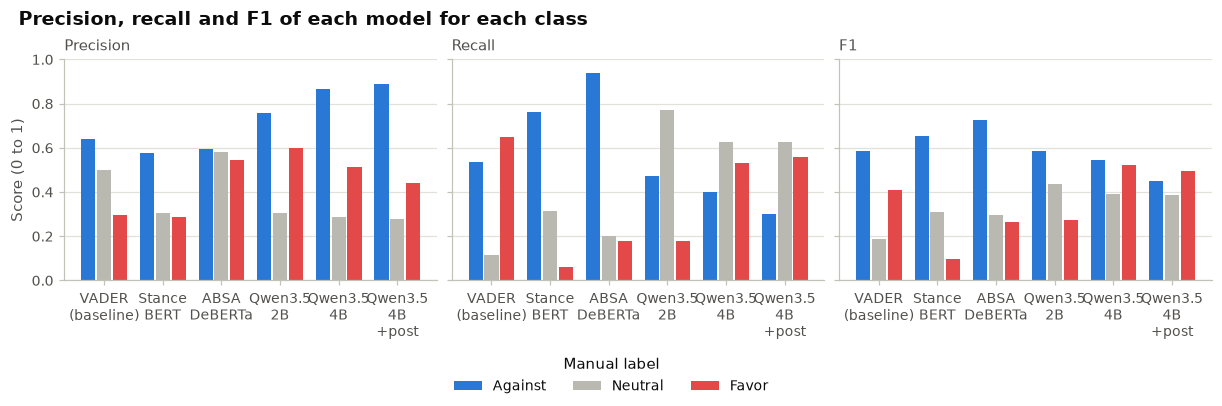

precision  recall    F1
Qwen3.5 4B       against       0.86    0.40  0.55
                 neutral       0.29    0.63  0.39
                 favor         0.51    0.53  0.52
Qwen3.5 4B +post against       0.89    0.30  0.45
                 neutral       0.28    0.63  0.39
                 favor         0.44    0.56  0.49

In [41]:
per_class = per_class_table()
plot_per_class(per_class)
display(per_class.loc[[RATER_NAME[BEST], RATER_NAME[CONTEXT]]].round(2))

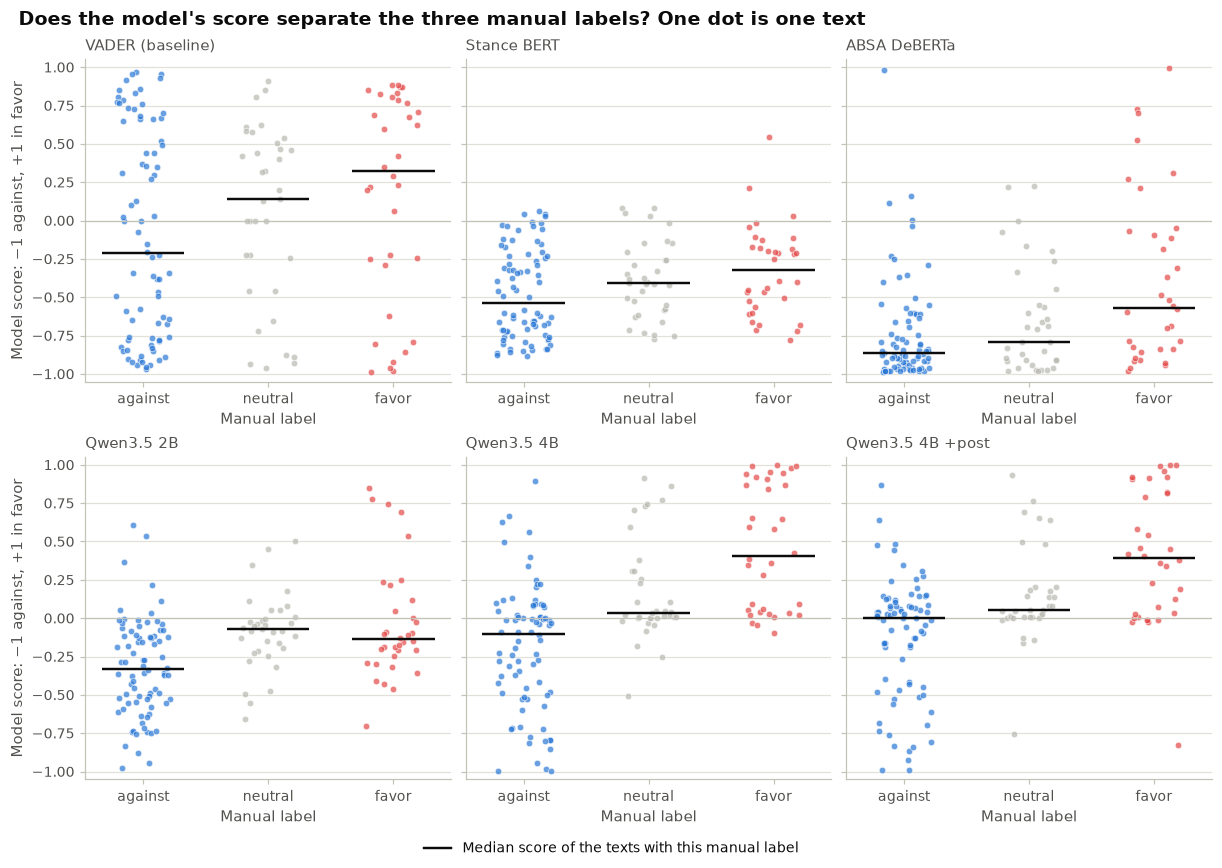

In [42]:
plot_signed_scores()

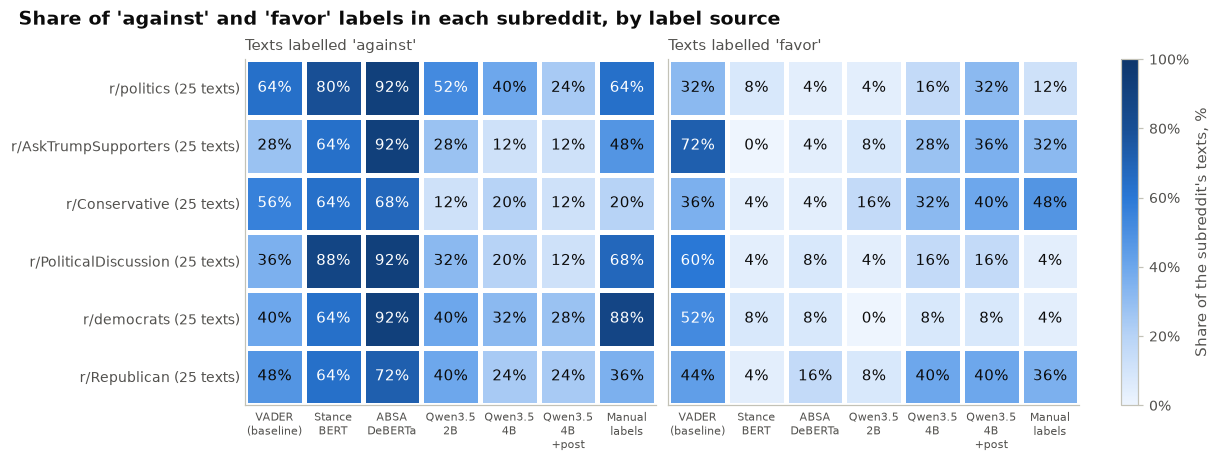

In [43]:
plot_subreddit_shares()

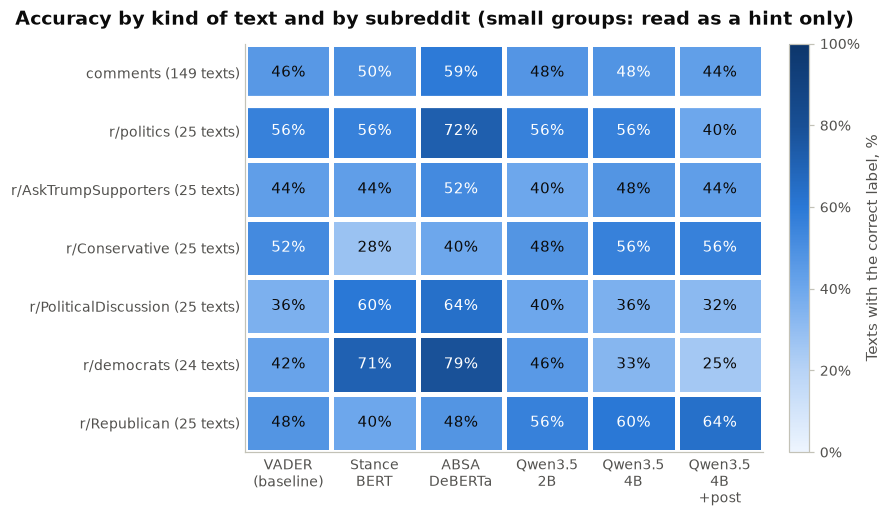

In [44]:
plot_accuracy_by_group()

**What we see.**

- The post does not help. On the 149 labelled comments the 4B model has a macro-F1 of 0.49 without the post and 0.44 with it, accuracy goes from 0.48 to 0.44 and kappa from 0.25 to 0.21.
- The difference is inside the noise. −0.04 in macro-F1 with a 95% interval from −0.11 to +0.02. The post does not make the model better, and we cannot say it makes it worse.
- Comments are harder than the whole sample. 54% of them are `against`, so the baseline that always answers `against` reaches an accuracy of 0.54, above both versions of the 4B model. On macro-F1 all models stay well above the baseline (0.23).
- The main error of section 2 stays. The model still answers `neutral` for 53% of the comments (52% without the post), where we gave `neutral` to 23%, and labels 54% of the `against` comments `neutral`.
- The post moves the model toward `favor`. The share of `favor` labels grows from 23% to 29% and the share of `against` falls from 25% to 19%; our labels have 23% and 54%.
- Opposition is found less often: 24 of the 80 `against` comments with the post, 32 without it. 13 of them are now read as `favor` (8 before).
- Support is found as often as before: 19 of the 34 supportive comments (18 before). More `favor` labels with the same number of hits means a lower precision: 0.44, from 0.51.
- The loss is in the communities where most comments oppose Trump. In r/politics the accuracy falls from 56% to 40% and the share of `favor` labels doubles from 16% to 32%, where we found 12%. In r/Conservative and r/Republican the accuracy is the same or slightly higher (56% and 64%). One subreddit has 25 comments, so these are hints.

**What it means for the project.** Adding the post costs 40% of the speed and does not improve the labels.

### 3.5 Which comments change

**Questions:** how many labels does the post change, in which direction, and does it help more for the comments that answer the post directly?

In [45]:
N_CHANGED = 20        # changed labels listed

before, after, truth = judged[f"{BEST}_label"], judged[f"{CONTEXT}_label"], judged["human"]
changed = before != after
print(f"the post changes the label of {changed.sum()} of the {len(judged)} labelled comments: "
      f"{(changed & (after == truth)).sum()} become right, {(changed & (before == truth)).sum()} become wrong, "
      f"{(changed & (before != truth) & (after != truth)).sum()} are wrong before and after")
moves = pd.crosstab(before, after).reindex(index=LABELS, columns=LABELS, fill_value=0)
moves.index = [f"without the post: {label}" for label in LABELS]
moves.columns = [f"with the post: {label}" for label in LABELS]
display(moves)

position = judged["is_top_level"].map({True: "answers the post", False: "answers another comment"})
by_position = pd.DataFrame({
    "comments": position.value_counts(),
    "accuracy without the post, %": (100 * (before == truth).groupby(position).mean()).round(0),
    "accuracy with the post, %": (100 * (after == truth).groupby(position).mean()).round(0),
})
display(by_position)

question = judged["text"].str.strip().str.endswith("?")
print(f"{question.sum()} comments end with a question mark ({(truth[question] == 'against').sum()} are 'against' by hand); "
      f"'neutral' answers for them: {(before[question] == 'neutral').sum()} without the post, {(after[question] == 'neutral').sum()} with it")

listed = judged.loc[changed].merge(posts[["id", "post"]], on="id")
listed = listed.assign(outcome=np.select([listed[f"{CONTEXT}_label"] == listed["human"], listed[f"{BEST}_label"] == listed["human"]],
                                         ["now right", "now wrong"], "still wrong")).sort_values("outcome").head(N_CHANGED)
with pd.option_context("display.max_colwidth", TEXT_CHARS):
    display(pd.DataFrame({
        "subreddit": listed["subreddit"],
        "post": listed["post"].fillna(NO_POST).str.replace(r"\s+", " ", regex=True).str.slice(0, 90),
        "comment": listed["text"].str.replace(r"\s+", " ", regex=True).str.slice(0, TEXT_CHARS),
        "manual": listed["human"],
        "without the post": listed[f"{BEST}_label"],
        "with the post": listed[f"{CONTEXT}_label"],
        "outcome": listed["outcome"],
    }).reset_index(drop=True))

the post changes the label of 33 of the 149 labelled comments: 8 become right, 15 become wrong, 10 are wrong before and after


,with the post: against,with the post: neutral,with the post: favor
without the post: against,22,6,9
without the post: neutral,3,67,7
without the post: favor,2,6,27


,comments,"accuracy without the post, %","accuracy with the post, %"
is_top_level,,,
answers another comment,92,49.0,40.0
answers the post,57,47.0,49.0


21 comments end with a question mark (15 are 'against' by hand); 'neutral' answers for them: 16 without the post, 13 with it


,subreddit,post,comment,manual,without the post,with the post,outcome
0,PoliticalDiscussion,Could Tim Kaine be a major player in 2020 or be the leader of the Democratic Party? With O,"I don't know about that. If you're facing Trump in 2020, I think there's a LOT of advantages. I don't doubt that had the ticket been flipped or any other De...",neutral,favor,neutral,now right
1,politics,Poll: 73% Back Independent Probe of Russian Election Interference,"Whether it was against us is in the eye of the beholder, as many believe it benefitted our country. The next American president affects their country greatl...",favor,neutral,favor,now right
2,Conservative,Donald Trump Jr sightseeing in Greenland today,I think he’s fine. He did a lot of work to get Trump elected.,favor,neutral,favor,now right
3,Republican,Haitian illegal immigrant bludgeons mother of two to death with hammer outside Florida gas,Death penalty is too good for this evil. I am disappointed the Trump administration had 15 months to deported him and failed. Where was ICE?,against,neutral,against,now right
4,AskTrumpSupporters,"A common theme in the subreddit is ""policy over personality."" Are there any other politici","I agree many Presidents fail in their ambitions, but this case feels unique. I would love to see less corruption in the government. If a candidate promised ...",against,neutral,against,now right
5,PoliticalDiscussion,"Is a gift of a luxury 747 Jet a benefit to the country, or a demonstration of open corrupt","I have not seen a legitimate reason why the jet should be given to the Trump Library. To me, that is where the corruption is. If the airplane is still in pe...",against,neutral,against,now right
6,Republican,Tucker Carlson says he’ll no longer support the Republican Party,"I’m with him. Trump lies so much, only cares about the wealthy, does a lot of corrupt shit. I voted for the fucker 3 times. I am a fool",against,favor,against,now right
7,Conservative,AntiTrump catastrophism is the real menace to the West,"Snark really is all that President Trump’s critics have left. They greet his every utterance, whether made in the flesh or on Truth Social, with instant sar...",favor,against,favor,now right
8,Conservative,Trump signs executive order halting family separations,President Trump will 100% be sued over this! This EO violates the 9th circuit ruling that was handed to Obama when Obama tried keeping families together. Ob...,against,against,favor,now wrong
9,AskTrumpSupporters,Do you agree with the Trump administration paying $5 million to the family of Ashli Babbit,She was at a barricaded door to the Speaker's Lobby and the House Chambers. Congresspeople and staff were actively evacuating in the room that Babbitt was e...,neutral,neutral,favor,now wrong


**What we see.**

- The post changes 33 of the 149 labels: 8 become right, 15 become wrong, and 10 are wrong before and after. The largest move is from `against` to `favor` (9 comments), then from `neutral` to `favor` (7). Moves away from `favor` are fewer (8 in total).
- The position of the comment in the thread matters. For the 57 comments that answer the post directly accuracy is 47% without the post and 49% with it; for the 92 replies to other comments it falls from 49% to 40%. A reply answers the comment above it, which the model does not see, and the post is often a headline that the reply does not discuss.
- questions: of the 21 comments that end with a question mark, 16 were `neutral` without the post and 13 with it. 15 of them are `against` by hand.

**What it means for the project.** The context that a reply needs is the comment it answers, not the post. The post alone helps only the comments at the top of a thread, and there the gain is too small to see on 57 comments.

### 3.6 Summary

**Result**

1. The post does not improve the 4B model(macro-F1 0.44 against 0.49, a difference inside the noise)
2. The post pushes the model toward `favor` and away from `against`, most of all in r/politics.
3. For replies to other comments the post is the wrong context, and there the accuracy falls from 49% to 40%. For comments that answer the post it stays the same (47% and 49%).
4. The run is 40% slower (0.85 comments per second), with the same memory.

**Limits**

- The two prompts differ in more than the post (13 examples against 10), so this compares prompts and is not a clean test of the post.
- 149 comments, and 57 or 92 in the two groups by position, are small numbers. The intervals in section 3.4 show it.
- Our labels were made without the post.
- 15 long posts were cut at 1000 characters, and 3 comments had no post.

**Next step**

Give a reply the comment it answers (`parent_id`) and give the post only to top-level comments (section 4). Until then the version without the post stays the reference.

## 4. Context by the place of the comment in its thread

**Question.** If a reply gets the comment it answers, and only top-level comments get the post, does the 4B model improve?

| Step | What happens |
|---|---|
| 4.1 | The comment that each reply answers is looked up through `parent_id` |
| 4.2 | The prompt takes one of three forms: with the post, with the earlier comment, or with the comment alone |
| 4.3 | The 4B model labels the 150 comments again |
| 4.4 | The three versions of the 4B model are compared |

### 4.1 The comment that a reply answers

**Question:** for how many replies is the earlier comment available?

The `parent_id` of a reply is the id of the comment that it answers. That comment can be looked up only inside our dataset, which holds only comments that mention Trump, so an earlier comment without the word "Trump" is not there. 

Each comment gets the context that fits its place:

- a comment that answers the post gets **the post**;
- a reply whose earlier comment is found gets **that comment**;
- a reply whose earlier comment is not in the dataset gets **nothing**. Section 3.5 showed that the post is the wrong context for a reply.

In [46]:
THREAD = "qwen4b_thread"              # name of this run: the 4B model with the context that fits the place of the comment in its thread
THREAD_PROMPT_VERSION = "v3-thread"
PARENT_MAX_CHARS = 1000               # a longer earlier comment is cut at the end
RESCORE_THREAD = False                # True runs the model again even when saved predictions exist
CONTEXTS = ["post", "earlier comment", "none"]

PARENTS_PATH = SENT_DIR / "sample_parents.csv"
THREAD_PREDICTIONS_PATH = SENT_DIR / "llm_thread_predictions.csv"
THREAD_CONFIG_PATH = SENT_DIR / "llm_thread_run_config.json"


def find_parents(ids):
    """The comment that each reply answers: `parent_id` of a reply is 't1_' and the id of that comment.
    Only comments that mention Trump are in the dataset, so many earlier comments are not found."""
    link = pq.read_table(COMMENTS_PATH, columns=["id", "parent_id", "is_top_level"], filters=[("id", "in", list(ids))]).to_pandas()
    link = link.loc[~link["is_top_level"]].assign(parent_id=lambda d: d["parent_id"].str.removeprefix("t1_"))
    found = pq.read_table(COMMENTS_PATH, columns=["id", "body_clean"], filters=[("id", "in", link["parent_id"].unique().tolist())]).to_pandas()
    return link[["id", "parent_id"]].merge(found.rename(columns={"id": "parent_id", "body_clean": "parent"}), on="parent_id", how="left")


def add_context(df):
    """Which context a comment gets: the post when it answers the post, the earlier comment when it is a reply and that comment is found."""
    df["post"], df["parent"] = df["post"].fillna("").str.strip(), df["parent"].fillna("").str.strip()
    df["context"] = np.select([df["is_top_level"] & (df["post"] != ""), ~df["is_top_level"] & (df["parent"] != "")], CONTEXTS[:2], CONTEXTS[2])
    df["context_text"] = np.select([df["context"] == "post", df["context"] == "earlier comment"], [df["post"], df["parent"]], "")
    return df


if not PARENTS_PATH.exists():
    find_parents(comments["id"]).to_csv(PARENTS_PATH, index=False, lineterminator="\n")
parents = pd.read_csv(PARENTS_PATH, dtype=str)
comments = add_context(comments.drop(columns=["parent", "context", "context_text"], errors="ignore").merge(parents[["id", "parent"]], on="id", how="left"))

replies = comments.loc[~comments["is_top_level"]]
length = comments.loc[comments["context"] == "earlier comment", "parent"].str.len()
print(f"{len(replies)} of the {len(comments)} comments are replies; the earlier comment is in the dataset for {(replies['parent'] != '').sum()} of them")
print(f"length of an earlier comment: median {length.median():.0f} characters, longest {length.max():,}; {(length > PARENT_MAX_CHARS).sum()} are cut at {PARENT_MAX_CHARS:,}")
context_table = pd.crosstab(comments["subreddit"], comments["context"]).reindex(index=SUBREDDITS, columns=CONTEXTS, fill_value=0)
context_table.loc["All"] = context_table.sum()
context_table.columns = [f"context: {c}" for c in CONTEXTS]
display(context_table)

92 of the 150 comments are replies; the earlier comment is in the dataset for 31 of them
length of an earlier comment: median 313 characters, longest 1,396; 4 are cut at 1,000


,context: post,context: earlier comment,context: none
subreddit,,,
politics,9,5,11
AskTrumpSupporters,3,7,15
Conservative,13,4,8
PoliticalDiscussion,5,8,12
democrats,14,3,8
Republican,12,4,9
All,56,31,63


### 4.2 The prompt with three forms

The instruction says that a context may come before the comment and that the label is for the last comment. The labels and the rules are the same. The examples cover the three forms of a request and are again written by us. This is prompt version `v3-thread`, written before its scores were seen and not changed afterwards.

In [47]:
THREAD_SYSTEM_PROMPT = SYSTEM_PROMPT.replace(
    "You classify the stance of the author of a Reddit text toward Donald Trump.",
    "You classify the stance of the author of a Reddit comment toward Donald Trump.\n\n"
    "Before the comment you may receive its context: the post under which it was written, or the earlier comment that it answers. "
    "The context only shows what the comment is about. Classify the position of the author of the last comment, not of the context.")
assert THREAD_SYSTEM_PROMPT != SYSTEM_PROMPT

# examples for the three forms of a request, written by hand; the comments of sections 2.2 and 3.2 are used again where they fit
THREAD_FEW_SHOT = [
    ("post", "Appeals court refuses to reinstate Trump's travel ban",
     "Best news all week! The court just threw out his travel ban again. Pop the champagne, folks.", "against"),
    ("earlier comment", "Trump's tariffs are going to wreck the farm states.",
     "They said the same thing in 2018 and the farmers still voted for him. I'll trust the guy who actually fights for us.", "pro"),
    ("none", "",
     "My rent went up again and I spent the whole weekend fixing my car. At least the Trump debate on TV was good background noise.", "neutral"),
    ("earlier comment", "I honestly think he's doing a decent job on the border.",
     "Decent job? He put kids in cages and called it policy.", "against"),
    ("post", "Trump fires FBI director James Comey",
     "About time. Should have happened on day one.", "pro"),
    ("post", "Trump signs executive order on steel and aluminum tariffs",
     "The order takes effect in 15 days and exempts Canada and Mexico for now.", "neutral"),
    ("none", "",
     "Oh sure, Trump is definitely a stable genius. Nothing says genius like bankrupting a casino. /s", "against"),
    ("earlier comment", "Everyone laughed at Trump for walking away from the talks.",
     "And now they are all coming back to the table. He knew exactly what he was doing.", "pro"),
    ("earlier comment", "Trump said he would release the files next week.",
     "Do you have a source for that? I can't find the quote anywhere.", "neutral"),
    ("post", "Trump's approval rating falls to a new low",
     "Couldn't happen to a nicer guy.", "against"),
    ("none", "",
     "The media is so dishonest it's disgusting. They twist every single thing Trump says and then act shocked when nobody trusts them anymore.", "pro"),
    ("earlier comment", "The Democrats should have run someone younger.",
     "With or without Trump on the ballot, the Democrats have no message at all. They lost the working class years ago and still don't understand why.", "neutral"),
    ("earlier comment", "This is the most corrupt administration in modern history.",
     "Exactly. And nobody in his party will say a word.", "against"),
    ("post", "Senate confirms Trump's Supreme Court nominee",
     "Who was the last nominee that got confirmed this fast?", "neutral"),
]
assert not set(comment for _, _, comment, _ in THREAD_FEW_SHOT) & set(sample["text"])


def thread_turn(kind, context, comment):
    head = {"post": f"Post:\n{context[:POST_MAX_CHARS]}\n\n", "earlier comment": f"Earlier comment:\n{context[:PARENT_MAX_CHARS]}\n\n", "none": ""}[kind]
    return {"role": "user", "content": f"{head}Comment:\n{comment[:TEXT_MAX_CHARS]}"}


THREAD_STATIC_MESSAGES = [{"role": "system", "content": THREAD_SYSTEM_PROMPT}]
for kind, example_context, example, answer in THREAD_FEW_SHOT:
    THREAD_STATIC_MESSAGES += [thread_turn(kind, example_context, example), {"role": "assistant", "content": answer}]


def build_thread_messages(kind, context, comment):
    return THREAD_STATIC_MESSAGES + [thread_turn(kind, context, comment)]


examples = pd.DataFrame(THREAD_FEW_SHOT, columns=["context", "text of the context", "comment", "answer"])
print(f"prompt {THREAD_PROMPT_VERSION}: system instruction, {len(THREAD_FEW_SHOT)} examples, then the context (if there is one) and the comment")
display(pd.crosstab(examples["context"], examples["answer"]).reindex(index=CONTEXTS, columns=list(LLM_LABEL)))
print(THREAD_SYSTEM_PROMPT.split("\n\nAnswer with")[0])
print("\n(the labels and the six rules are the same as in section 2.2)")
display(examples)

prompt v3-thread: system instruction, 14 examples, then the context (if there is one) and the comment


answer,pro,against,neutral
context,,,
post,1,2,2
earlier comment,2,2,2
none,1,1,1


You classify the stance of the author of a Reddit comment toward Donald Trump.

Before the comment you may receive its context: the post under which it was written, or the earlier comment that it answers. The context only shows what the comment is about. Classify the position of the author of the last comment, not of the context.

(the labels and the six rules are the same as in section 2.2)


,context,text of the context,comment,answer
0,post,Appeals court refuses to reinstate Trump's travel ban,"Best news all week! The court just threw out his travel ban again. Pop the champagne, folks.",against
1,earlier comment,Trump's tariffs are going to wreck the farm states.,They said the same thing in 2018 and the farmers still voted for him. I'll trust the guy who actually fights for us.,pro
2,none,,My rent went up again and I spent the whole weekend fixing my car. At least the Trump debate on TV was good background noise.,neutral
3,earlier comment,I honestly think he's doing a decent job on the border.,Decent job? He put kids in cages and called it policy.,against
4,post,Trump fires FBI director James Comey,About time. Should have happened on day one.,pro
5,post,Trump signs executive order on steel and aluminum tariffs,The order takes effect in 15 days and exempts Canada and Mexico for now.,neutral
6,none,,"Oh sure, Trump is definitely a stable genius. Nothing says genius like bankrupting a casino. /s",against
7,earlier comment,Everyone laughed at Trump for walking away from the talks.,And now they are all coming back to the table. He knew exactly what he was doing.,pro
8,earlier comment,Trump said he would release the files next week.,Do you have a source for that? I can't find the quote anywhere.,neutral
9,post,Trump's approval rating falls to a new low,Couldn't happen to a nicer guy.,against


### 4.3 Running the model

The same function and checks as in 3.3. The answers are saved to `data/sentiment/llm_thread_predictions.csv` and the settings to `llm_thread_run_config.json`.

In [48]:
if RESCORE_THREAD or not is_saved(THREAD_PREDICTIONS_PATH, THREAD_PROMPT_VERSION, comments["id"]):
    run_best(THREAD, THREAD_PROMPT_VERSION,
             [build_thread_messages(kind, context, comment) for kind, context, comment in zip(comments["context"], comments["context_text"], comments["text"])],
             comments["id"], THREAD_STATIC_MESSAGES, lambda text: build_thread_messages("none", "", text),
             THREAD_PREDICTIONS_PATH, THREAD_CONFIG_PATH, post_max_chars=POST_MAX_CHARS, parent_max_chars=PARENT_MAX_CHARS)
llm_thread = pd.read_csv(THREAD_PREDICTIONS_PATH, dtype={"id": str}, keep_default_na=False, na_values=[""])
thread_config = json.loads(THREAD_CONFIG_PATH.read_text(encoding="utf-8"))

errors = llm_thread.loc[llm_thread["label"] == "error"]
print(f"{len(llm_thread)} answers, prompt {THREAD_PROMPT_VERSION}; {len(errors)} answers are not a label" + (":" if len(errors) else ""))
if len(errors):
    display(errors[["id", "raw_output"]])
print(f"prompt length, median and longest: {llm_thread['prompt_tokens'].median():.0f} and {llm_thread['prompt_tokens'].max():.0f} tokens (context: {CTX_PER_SLOT})")
print(f"speed: {thread_config['speed']['texts_per_second']:.2f} comments per second ({100 * thread_config['speed']['cached_share']:.0f}% of the prompt tokens from the cache); "
      f"with the post for every comment it was {post_config['speed']['texts_per_second']:.2f}, with the comment alone {alone['texts_per_second']:.2f}")
print(f"VRAM: {thread_config['speed']['model_dedicated_mib']:,.0f} MiB for the model, {thread_config['speed']['vram_peak_mib']:,.0f} MiB on the card at the peak, "
      f"{thread_config['speed']['model_shared_mib']:.0f} MiB of shared GPU memory; layers on the GPU: {thread_config['layers_on_gpu']}")
print(json.dumps({k: v for k, v in thread_config.items() if k not in ("speed", "generation", "model")}, indent=2))

150 answers, prompt v3-thread; 0 answers are not a label
prompt length, median and longest: 1058 and 1527 tokens (context: 2048)
speed: 0.97 comments per second (88% of the prompt tokens from the cache); with the post for every comment it was 0.85, with the comment alone 1.49
VRAM: 2,863 MiB for the model, 3,948 MiB on the card at the peak, 82 MiB of shared GPU memory; layers on the GPU: 33/33
{
  "prompt_version": "v3-thread",
  "prompt_sha256": "4219f052cdcef31aff50e24497b7e5c0a3cf3366006fd17369fde8228ba3270c",
  "seed": 42,
  "llama_cpp": "b11146",
  "context_per_slot": 2048,
  "text_max_chars": 4000,
  "post_max_chars": 1000,
  "parent_max_chars": 1000,
  "server_flags": "-ngl 99 -c 2048 -np 1 --no-kv-unified --seed 42 --reasoning off --no-mmproj --no-webui -lv 4",
  "layers_on_gpu": "33/33",
  "free_answer": "against",
  "prompt_ends_with": "|im_start|>assistant\n<think>\n\n</think>\n\n",
  "build": "b11146-7fe450e19",
  "run_at": "2026-10-04 22:06"
}


### 4.4 Three versions of the 4B model

**Questions:** does the context by place give better labels than the comment alone or the post for every comment, and for which comments?

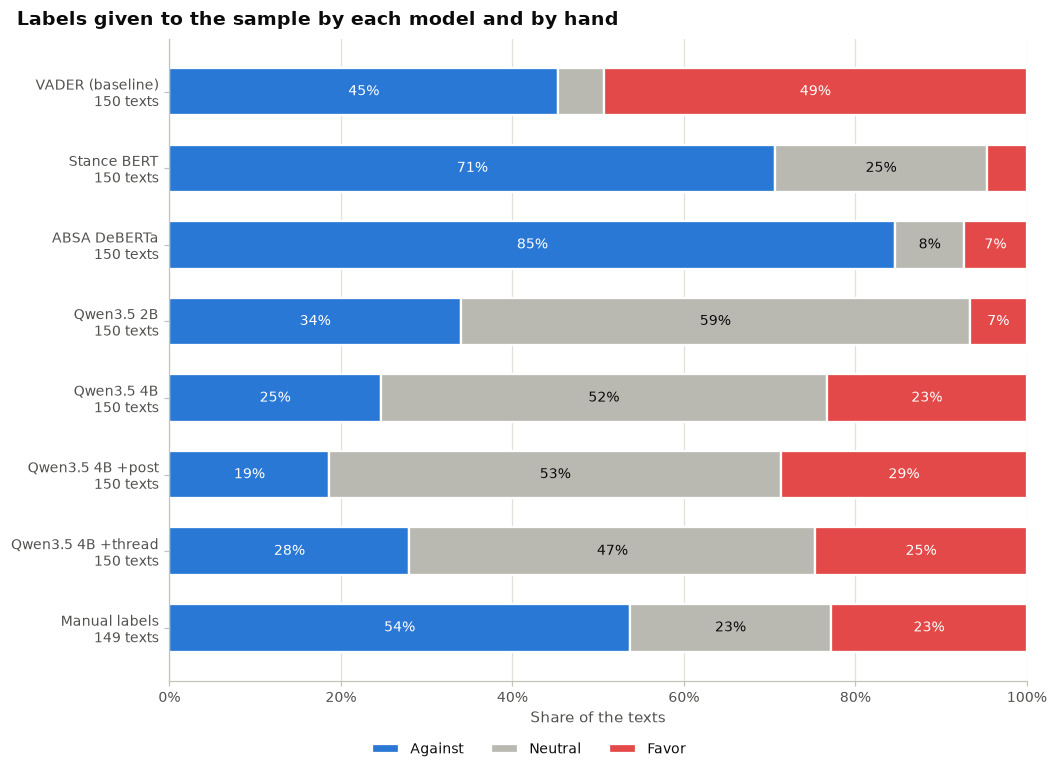

In [49]:
MODELS = [m for m in MODELS if m != THREAD] + [THREAD]
RATER_NAME[THREAD] = f"{LLM_NAME[BEST]} +thread"

assert not (llm_thread["label"] == "error").any()
in_thread = llm_thread.set_index("id")
predictions[f"{THREAD}_label"] = predictions["id"].map(in_thread["label"])
predictions[f"{THREAD}_score"] = predictions["id"].map(in_thread["score"])
results = (
    sample.merge(predictions, on="id", validate="one_to_one")
    .merge(labels, on="id", how="left", validate="one_to_one")
    .merge(comments[["id", "is_top_level", "context"]], on="id", validate="one_to_one")       # keeps the comments only
)
judged = results.loc[results["human"].isin(LABELS)]
raters = MODELS + ["human"]

plot_label_shares()

In [50]:
point, low, high, boot = evaluate()
summary = pd.DataFrame({
    s: [f"{point.loc[r, s]:.2f}  ({low.loc[r, s]:.2f} to {high.loc[r, s]:.2f})" for r in point.index] for s in SCORES
}, index=[ROW_NAME.get(r, RATER_NAME.get(r)) for r in point.index])
print(f"{len(judged)} labelled comments; each cell is the score and its 95% interval")
display(summary)
all_gaps = gaps(boot, point)
display(all_gaps.loc[[name for name in all_gaps.index if name.startswith(RATER_NAME[THREAD])]])

149 labelled comments; each cell is the score and its 95% interval


,accuracy,macro-F1,Cohen's kappa
VADER (baseline),0.46 (0.38 to 0.54),0.39 (0.31 to 0.47),0.15 (0.04 to 0.26)
Stance BERT,0.50 (0.42 to 0.58),0.35 (0.28 to 0.43),0.09 (-0.03 to 0.20)
ABSA DeBERTa,0.59 (0.51 to 0.67),0.43 (0.34 to 0.52),0.20 (0.09 to 0.31)
Qwen3.5 2B,0.48 (0.40 to 0.56),0.43 (0.35 to 0.52),0.21 (0.11 to 0.32)
Qwen3.5 4B,0.48 (0.40 to 0.56),0.49 (0.41 to 0.57),0.25 (0.15 to 0.36)
Qwen3.5 4B +post,0.44 (0.36 to 0.52),0.44 (0.36 to 0.52),0.21 (0.11 to 0.31)
Qwen3.5 4B +thread,0.49 (0.41 to 0.57),0.48 (0.40 to 0.56),0.25 (0.15 to 0.36)
Majority baseline (always 'against'),0.54 (0.46 to 0.62),0.23 (0.21 to 0.25),0.00 (0.00 to 0.00)


,difference in macro-F1,95% interval,interval excludes 0
Qwen3.5 4B +thread minus VADER (baseline),+0.09,-0.02 to +0.21,no
Qwen3.5 4B +thread minus Stance BERT,+0.13,+0.02 to +0.23,yes
Qwen3.5 4B +thread minus ABSA DeBERTa,+0.05,-0.06 to +0.17,no
Qwen3.5 4B +thread minus Qwen3.5 2B,+0.05,-0.04 to +0.14,no
Qwen3.5 4B +thread minus Qwen3.5 4B,-0.00,-0.07 to +0.06,no
Qwen3.5 4B +thread minus Qwen3.5 4B +post,+0.04,-0.02 to +0.10,no


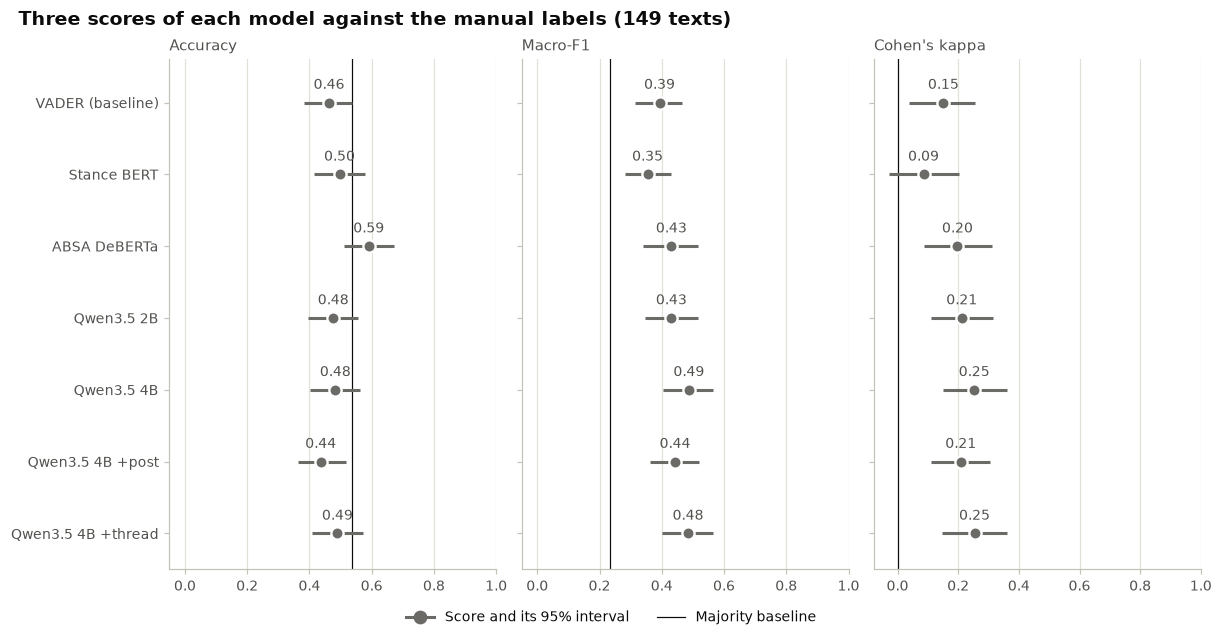

In [51]:
plot_scores()

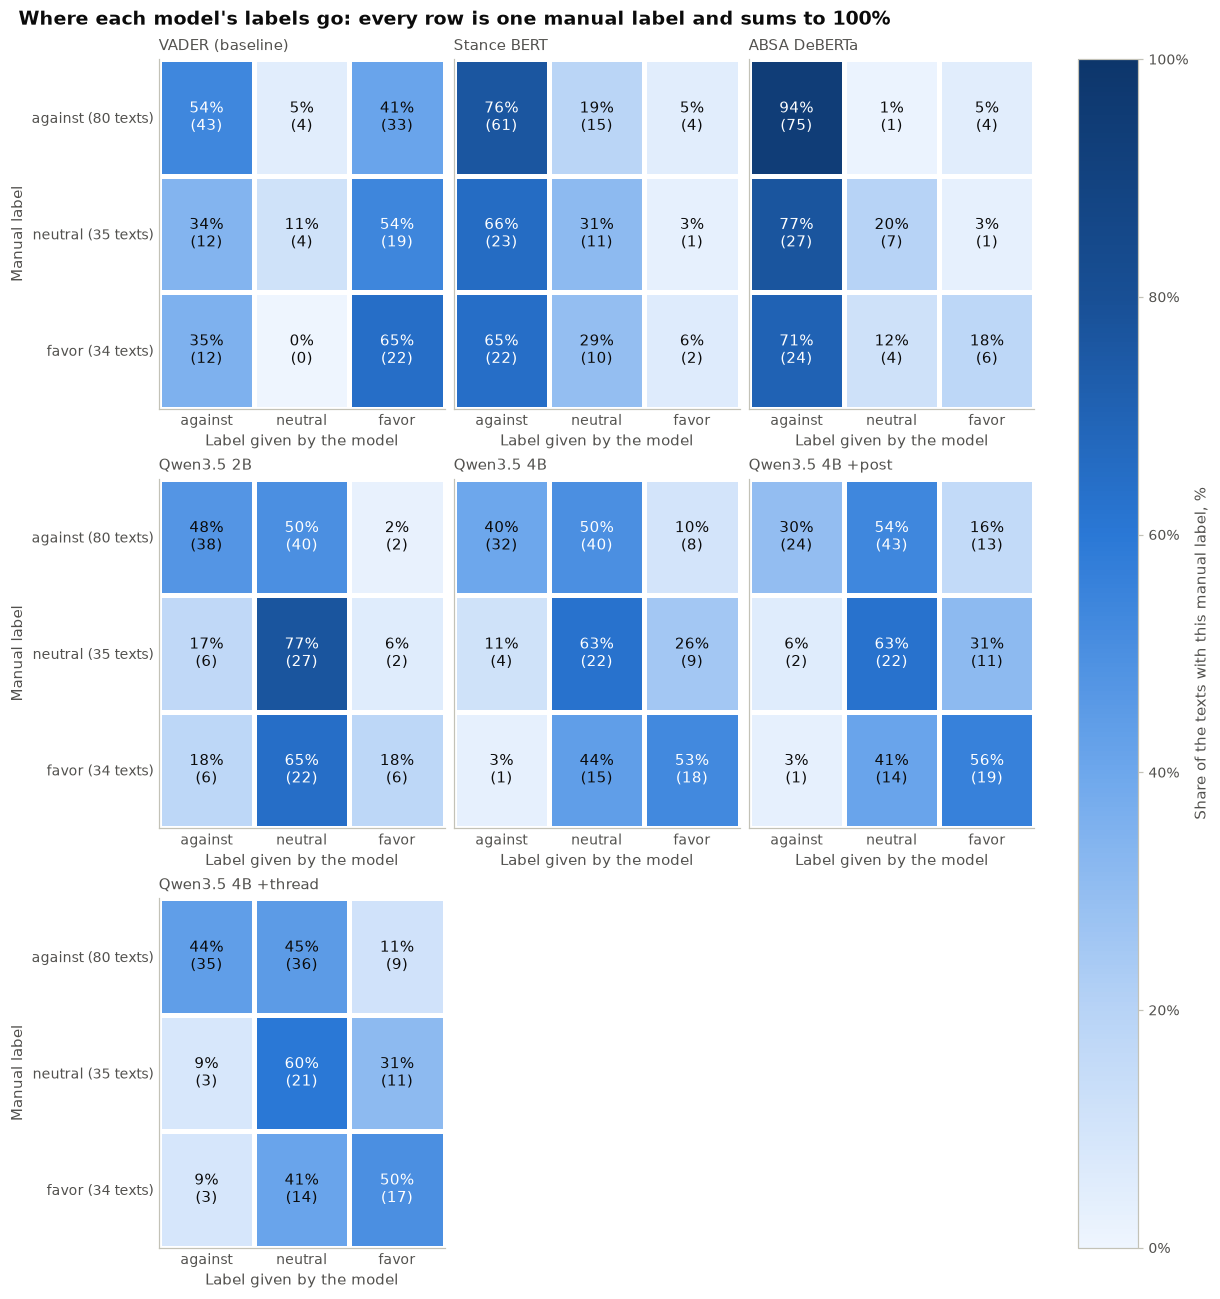

In [52]:
plot_confusion()

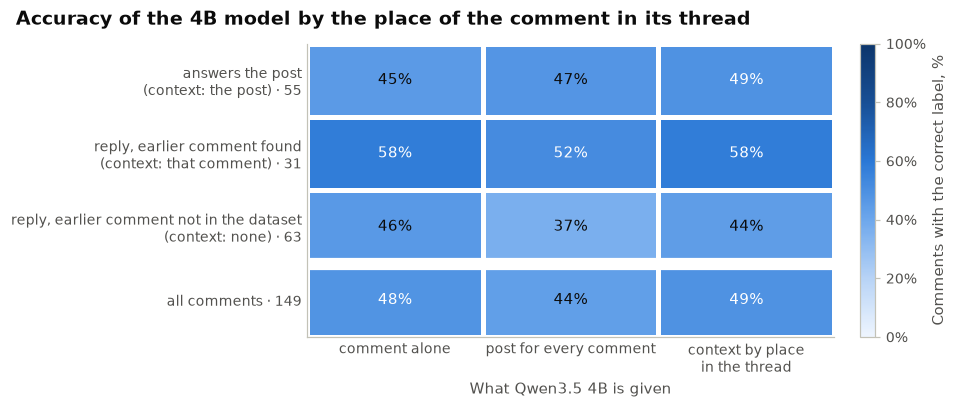

against the comment alone, the new prompt changes the label of 28 of the 149 labelled comments: 11 become right, 10 become wrong, 7 are wrong before and after


,context by place: against,context by place: neutral,context by place: favor
comment alone: against,29,3,5
comment alone: neutral,7,65,5
comment alone: favor,5,3,27


precision  recall    F1
Qwen3.5 4B         against       0.86    0.40  0.55
                   neutral       0.29    0.63  0.39
                   favor         0.51    0.53  0.52
Qwen3.5 4B +post   against       0.89    0.30  0.45
                   neutral       0.28    0.63  0.39
                   favor         0.44    0.56  0.49
Qwen3.5 4B +thread against       0.85    0.44  0.58
                   neutral       0.30    0.60  0.40
                   favor         0.46    0.50  0.48

In [53]:
VARIANTS = [BEST, CONTEXT, THREAD]        # the 4B model with the comment alone, with the post for every comment, with the context by place in the thread
CONTEXT_ROW = {"post": "answers the post\n(context: the post)", "earlier comment": "reply, earlier comment found\n(context: that comment)",
               "none": "reply, earlier comment not in the dataset\n(context: none)"}

accuracy = pd.DataFrame({m: 100 * (judged[f"{m}_label"] == judged["human"]).groupby(judged["context"]).mean() for m in VARIANTS}).reindex(CONTEXTS)
accuracy.loc["all"] = [100 * (judged[f"{m}_label"] == judged["human"]).mean() for m in VARIANTS]
size = judged["context"].value_counts().reindex(CONTEXTS)
size["all"] = len(judged)

fig, ax = plt.subplots(figsize=(8.6, 3.6), layout="constrained")
mesh = ax.pcolormesh(accuracy.to_numpy(dtype=float), cmap=BLUES, vmin=0, vmax=100, edgecolors="white", linewidth=2)
for i in range(accuracy.shape[0]):
    for j in range(accuracy.shape[1]):
        v = accuracy.iat[i, j]
        ax.text(j + 0.5, i + 0.5, f"{v:.0f}%", ha="center", va="center", fontsize=9.5, color=ink_on(mesh.cmap(mesh.norm(v))))
ax.axhline(len(CONTEXTS), color="white", linewidth=8)             # separates the three groups from the total
ax.set_xticks(np.arange(len(VARIANTS)) + 0.5, ["comment alone", "post for every comment", "context by place\nin the thread"])
ax.set_yticks(np.arange(len(accuracy)) + 0.5, [f"{CONTEXT_ROW.get(c, 'all comments')} · {size[c]}" for c in accuracy.index])
ax.invert_yaxis()
ax.grid(False)
ax.tick_params(length=0)
ax.set_xlabel(f"What {LLM_NAME[BEST]} is given")
fig.colorbar(mesh, ax=ax, label="Comments with the correct label, %", format=PERCENT)
headline(fig, "Accuracy of the 4B model by the place of the comment in its thread")
plt.show()

before, after, truth = judged[f"{BEST}_label"], judged[f"{THREAD}_label"], judged["human"]
changed = before != after
print(f"against the comment alone, the new prompt changes the label of {changed.sum()} of the {len(judged)} labelled comments: "
      f"{(changed & (after == truth)).sum()} become right, {(changed & (before == truth)).sum()} become wrong, "
      f"{(changed & (before != truth) & (after != truth)).sum()} are wrong before and after")
moves = pd.crosstab(before, after).reindex(index=LABELS, columns=LABELS, fill_value=0)
moves.index = [f"comment alone: {label}" for label in LABELS]
moves.columns = [f"context by place: {label}" for label in LABELS]
display(moves)
display(per_class_table().loc[[RATER_NAME[m] for m in VARIANTS]].round(2))

**What we see.**

- The earlier comment exists for only 31 of the 92 replies. The other 61 answer a comment that does not mention Trump and is not in the dataset. So 56 comments get the post, 31 get the earlier comment and 63 get no context. The run passes the same checks as before, at 0.97 comments per second (comment alone 1.49, post for every comment 0.85).
- The context by place gives the same scores as the comment alone. Accuracy 0.49 against 0.48, macro-F1 0.48 against 0.49, kappa 0.25 for both. The difference in macro-F1 is 0.00, with a 95% interval from −0.07 to +0.06. It is 0.04 above the version with the post for every comment (interval −0.02 to +0.10). The loss that section 3 saw for replies is gone, as expected: replies no longer get the post.
- The earlier comment does not help here. For the 31 replies that have it accuracy is 58%, the same as alone (one comment is 3 points, so only a large effect would show). For the 55 comments that answer the post it goes from 45% to 49%, and for the 63 replies without context from 46% to 44%, which is the size of change that comes from the wording of the prompt alone.
- Labels change in both directions and cancel out: 28 of 149 change (11 become right, 10 wrong, 7 stay wrong). The error pattern is that of section 2. 45% of the `against` comments are still `neutral` (50% alone) and 17 of 34 supportive comments are found (18 before).

**What it means for the project.** Context by place repairs the damage of section 3 and brings the model back to where it was without context. It does not move it forward. The weak point of the 4B model is not missing context.

### 4.5 Summary

**Result**

1. A reply can get the comment it answers only in one case out of three, because the dataset keeps only the comments that mention Trump.
2. With the post for the comments at the top of a thread and the earlier comment for the replies where it exists, the 4B model scores the same as with the comment alone: macro-F1 0.48 and 0.49.
3. Three prompts (comment alone, post for every comment, context by place) give macro-F1 between 0.44 and 0.49 on the same 149 comments, and no difference between them is outside its interval. The share of `neutral` answers stays at about half of the comments in all three.
4. Context costs speed: 0.97 comments per second against 1.49.

**Limits**

- Only 31 replies have their earlier comment, too few to measure its effect. A test on more replies needs the comments that were removed by the keyword filter in Homework #2.
- The earlier comment is one step of the thread. A reply deep in a thread may need more than one step.
- The three prompts differ in their examples (10, 13 and 14), not only in the context.
- Our labels were made from the comment alone.

**Decision.**

The 4B model with the comment alone (prompt `v1`) is the reference: it is the fastest and no version with context is better. The open problem is the `neutral`/`against` line of 2.6, which is about the rules of labelling, not about context.

## 5. Distilling the 4B model into a scalable classifier

Qwen3.5 4B with prompt `v1` is the best local model of sections 1–4, but at 1.5 texts per second it would need about 35 days for 4.5M comments. We use the 100,000 comments that it labelled (`scripts/label_stance_part1.py`, `scripts/label_stance_part2.py`) as training data for a much faster classifier, the student. The labels are noisy (section 2.7), so we check the student against our manual labels. In the tables of this section the class `favor` is called `pro`.


| Step | What happens |
|---|---|
| 5.1 | The pseudo-labelled comments are joined with metadata, the manual benchmark is set aside, and the rest is split by thread into train, validation and test |
| 5.2 | Two TF-IDF linear classifiers are trained as a baseline |
| 5.3 | DistilRoBERTa is fine-tuned with inverse-frequency class weights |
| 5.4 | The same model is trained with softer class weights and the two versions are compared |
| 5.5 | Inference speed and memory are measured |
| 5.6 | Bias and stability checks by period, subreddit and AskTrumpSupporters flair |
| 5.7 | The effect of the input length at inference is tested |
| 5.8 | Summary and decision |

### 5.1 Setup, data and split

The two 50000-comment samples, their Qwen labels and the metadata extracted from `comments_clean.parquet` are joined into one table.

Comments from threads that occur in the manually labelled benchmark are excluded from student training. This prevents the model from seeing another comment from the same discussion before it is evaluated on the human-labelled comment.

In [3]:
import json
import time
import joblib
import pyarrow as pa

from sklearn.base import clone
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score,
    cohen_kappa_score,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
)
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

STANCE_DIR = ROOT / "data" / "stance"
SENT_DIR = ROOT / "data" / "sentiment"
STUDENT_DIR = STANCE_DIR / "student"
STUDENT_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
LABELS_STUDENT = ["against", "neutral", "pro"]

In [4]:
METADATA_PATH = STANCE_DIR / "sample_metadata.parquet"

if METADATA_PATH.exists():
    metadata = pd.read_parquet(METADATA_PATH)
    print(f"Loaded existing metadata: {metadata.shape}")

else:
    sample1 = pd.read_parquet(STANCE_DIR / "sample_part1.parquet")
    sample2 = pd.read_parquet(STANCE_DIR / "sample_part2.parquet")

    sample_ids = pd.concat([sample1["id"], sample2["id"]],ignore_index=True,).astype(str)
    id_set = pa.array(sample_ids.unique())
    comments_file = pq.ParquetFile(COMMENTS_PATH)

    columns = ["id","submission_id","parent_id","author","stance","score",]
    parts = []

    for i in range(comments_file.metadata.num_row_groups):
        table = comments_file.read_row_group(i,columns=columns,)
        mask = pc.is_in(table["id"],value_set=id_set,)

        if pc.any(mask).as_py():
            parts.append(table.filter(mask).to_pandas())

    metadata = pd.concat(parts,ignore_index=True,)

    assert metadata["id"].is_unique
    assert set(metadata["id"]) == set(sample_ids)

    metadata.to_parquet(METADATA_PATH,index=False,)
    print(f"Created metadata: {metadata.shape}")

Loaded existing metadata: (100000, 6)


In [5]:
sample = pd.concat([pd.read_parquet(STANCE_DIR / "sample_part1.parquet"),
                    pd.read_parquet(STANCE_DIR / "sample_part2.parquet"),],
                   ignore_index=True,)

teacher = pd.concat([pd.read_csv(STANCE_DIR / "labels_part1.csv", dtype={"id": str}),
                     pd.read_csv(STANCE_DIR / "labels_part2.csv", dtype={"id": str}),],
                    ignore_index=True,)

metadata = pd.read_parquet(STANCE_DIR / "sample_metadata.parquet")

sample["id"] = sample["id"].astype(str)
teacher["id"] = teacher["id"].astype(str)
metadata["id"] = metadata["id"].astype(str)

assert len(sample) == 100_000
assert sample["id"].is_unique
assert teacher["id"].is_unique
assert metadata["id"].is_unique
assert set(sample["id"]) == set(teacher["id"]) == set(metadata["id"])

teacher = teacher.rename(columns={"label": "teacher_label"})

pseudo = (sample.merge(teacher[["id","teacher_label","p_pro","p_against","p_neutral","score","model","prompt_version",]],on="id",validate="one_to_one",)
          .merge(metadata,on="id",validate="one_to_one",)
)

assert set(pseudo["teacher_label"]) <= set(LABELS_STUDENT)
assert set(pseudo["model"]) == {"qwen4b"}
assert set(pseudo["prompt_version"]) == {"v1"}

print(f"{len(pseudo):,} pseudo-labelled comments")

display(pseudo["teacher_label"].value_counts().reindex(LABELS_STUDENT).to_frame("n").assign(share=lambda x: x["n"] / x["n"].sum()))

100,000 pseudo-labelled comments


,n,share
teacher_label,,
against,23625,0.23625
neutral,54619,0.54619
pro,21756,0.21756


In [6]:
pseudo.head(3)

,id,subreddit,period,source_month,created_at,part,order,stratum_size,stratum_sampled,text,teacher_label,p_pro,p_against,p_neutral,score_x,model,prompt_version,submission_id,parent_id,author,stance,score_y
0,ddzoxmg,politics,T1_Y1,2017-02,2017-02-20 20:36:15+00:00,1,1,265849,772,"This president or any president? trump is a snake, but if you look at the gig alone the press doesn't need to see what the pre...",against,0.196341,0.610255,0.193403,-0.413914,qwen4b,v1,5v1lso,t1_ddz9zv1,HealthyDebtlover,<NA>,1
1,dwmcnvg,politics,T1_Y2,2018-04,2018-04-01 09:22:52+00:00,1,2,188384,772,"I dunno, it didn't hurt Trump.\nOh, but male though, so, yeah.",neutral,0.195901,0.081480,0.722619,0.114421,qwen4b,v1,88nddh,t1_dwm6ig5,ofthrees,<NA>,1
2,oebvpur,politics,T2_Y2,2026-04,2026-04-04 21:54:20+00:00,1,3,94541,772,Plus many who voted for him weren’t necessarily “Biden fans” they were just anti-Trump.,pro,0.491690,0.128043,0.380266,0.363647,qwen4b,v1,1scfh7e,t1_oean5ci,finditplz1,<NA>,5


In [7]:
human = pd.read_csv(SENT_DIR / "sentiment_results.csv",dtype={"id": str},)

human = human.loc[(human["kind"] == "comment")& human["human"].isin(["against", "neutral", "favor"])].copy()
human["human_label"] = human["human"].replace({"favor": "pro"})

human_links = pq.read_table(COMMENTS_PATH,columns=["id", "submission_id"],filters=[("id", "in", human["id"].tolist())],).to_pandas()

human_links["id"] = human_links["id"].astype(str)
human_links["submission_id"] = human_links["submission_id"].astype(str)

human = human.merge(human_links,on="id",validate="one_to_one",)

assert len(human) == 149

human_threads = set(human["submission_id"])

direct_overlap = pseudo["id"].isin(human["id"]).sum()
same_thread = pseudo["submission_id"].astype(str).isin(human_threads).sum()

student_pool = pseudo.loc[~pseudo["submission_id"].astype(str).isin(human_threads)].copy()

print(f"Human benchmark: {len(human)} comments")
print(f"Exact comments also present in the 100k sample: {direct_overlap}")
print(f"Pseudo-labelled comments removed because their thread is in the human benchmark: {same_thread:,}")
print(f"Comments left for student development: {len(student_pool):,}")

Human benchmark: 149 comments
Exact comments also present in the 100k sample: 53
Pseudo-labelled comments removed because their thread is in the human benchmark: 1,288
Comments left for student development: 98,712


**Split 80/10/10, grouped by thread.** 

A row-level random split would put comments of one discussion into both training and test (they share vocabulary, events and names) and flatter the student. The split is therefore grouped by `submission_id` and stratified by label, subreddit and period.

In [8]:
student_pool["submission_id"] = student_pool["submission_id"].astype(str)

student_pool["strat_key"] = (
    student_pool["teacher_label"].astype(str) + "|"
    + student_pool["subreddit"].astype(str) + "|"
    + student_pool["period"].astype(str)
)

splitter = StratifiedGroupKFold(n_splits=10,shuffle=True,random_state=SEED,)
fold_id = np.full(len(student_pool), -1, dtype=int)

for fold, (_, fold_index) in enumerate(splitter.split(student_pool,y=student_pool["strat_key"],groups=student_pool["submission_id"],)):
    fold_id[fold_index] = fold

assert (fold_id >= 0).all()

student_pool["fold"] = fold_id

train = student_pool.loc[student_pool["fold"] >= 2].copy()
valid = student_pool.loc[student_pool["fold"] == 1].copy()
test = student_pool.loc[student_pool["fold"] == 0].copy()

train_threads = set(train["submission_id"])
valid_threads = set(valid["submission_id"])
test_threads = set(test["submission_id"])

assert train_threads.isdisjoint(valid_threads)
assert train_threads.isdisjoint(test_threads)
assert valid_threads.isdisjoint(test_threads)

print(
    f"train:      {len(train):,} comments, {train['submission_id'].nunique():,} threads\n"
    f"validation: {len(valid):,} comments, {valid['submission_id'].nunique():,} threads\n"
    f"test:       {len(test):,} comments, {test['submission_id'].nunique():,} threads"
)

train:      78,969 comments, 29,862 threads
validation: 9,872 comments, 3,745 threads
test:       9,871 comments, 3,739 threads


In [9]:
split_balance = pd.concat(
    {
        "train": train["teacher_label"].value_counts(normalize=True),
        "validation": valid["teacher_label"].value_counts(normalize=True),
        "test": test["teacher_label"].value_counts(normalize=True),
    },axis=1,).reindex(LABELS_STUDENT)

display((100 * split_balance).round(1).astype(str) + "%")

,train,validation,test
teacher_label,,,
against,23.6%,23.6%,23.6%
neutral,54.6%,54.6%,54.6%
pro,21.8%,21.8%,21.8%


**What we see.**

- 53 of the 149 manually labelled comments are in the pseudo-labelled sample. We remove them and 1,288 other comments from their threads, so 98,712 comments are left.
- The split gives 78,969 / 9,872 / 9,871 comments (29,862 / 3,745 / 3,739 threads) for training, validation and test. No thread is in two parts.

**Metric**

The primary metric is macro-F1 because the three stance classes are not equally common and performance on `pro` and `against` matters independently of the large `neutral` class.

In [10]:
def evaluation_table(y_true, y_pred):
    precision, recall, f1, support = precision_recall_fscore_support(y_true,y_pred,labels=LABELS_STUDENT,zero_division=0,)

    return pd.DataFrame(
        {
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "support": support,
        },
        index=LABELS_STUDENT,
    )


def evaluate(y_true, y_pred, title=None):
    if title:
        print(title)

    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true,y_pred,labels=LABELS_STUDENT,average="macro",zero_division=0,),
        "kappa": cohen_kappa_score(y_true, y_pred),
    }

    print(
        f"accuracy = {metrics['accuracy']:.3f} | "
        f"macro-F1 = {metrics['macro_f1']:.3f} | "
        f"kappa = {metrics['kappa']:.3f}"
    )

    display(evaluation_table(y_true, y_pred).round(3))

    cm = confusion_matrix(y_true,y_pred,labels=LABELS_STUDENT,)

    display(pd.DataFrame(cm,index=[f"true {x}" for x in LABELS_STUDENT],columns=[f"pred {x}" for x in LABELS_STUDENT],))
    return metrics

### 5.2 Linear baseline

Two sparse text classifiers are compared.

1. **Word TF-IDF** uses words and word bigrams.
2. **Character TF-IDF** uses character n-grams inside word boundaries.

Both use a linear support-vector classifier. No subreddit, period, author or thread variables are supplied to the classifier.

The models are selected on the validation split.

In [11]:
word_student = Pipeline(
    [
        (
            "tfidf",
            TfidfVectorizer(
                lowercase=True,
                strip_accents="unicode",
                ngram_range=(1, 2),
                min_df=3,
                max_df=0.995,
                max_features=120_000,
                sublinear_tf=True,
                dtype=np.float32,
            ),
        ),
        ("clf",LinearSVC(C=1.0,),
        ),
    ]
)

char_student = Pipeline(
    [
        (
            "tfidf",
            TfidfVectorizer(
                analyzer="char_wb",
                ngram_range=(3, 5),
                min_df=5,
                max_features=120_000,
                sublinear_tf=True,
                dtype=np.float32,
            ),
        ),
        ("clf",LinearSVC(C=1.0,),
        ),
    ]
)

candidates = {"word": word_student,"char": char_student,}

In [12]:
fitted_candidates = {}
validation_rows = []

for name, model in candidates.items():
    print(f"\nTraining {name} student...")

    start = time.perf_counter()

    model.fit(train["text"].fillna(""),train["teacher_label"],)

    seconds = time.perf_counter() - start

    pred = model.predict(valid["text"].fillna(""))

    row = {
        "model": name,
        "accuracy": accuracy_score(valid["teacher_label"], pred),
        "macro_f1": f1_score(
            valid["teacher_label"],
            pred,
            labels=LABELS_STUDENT,
            average="macro",
            zero_division=0,
        ),
        "kappa": cohen_kappa_score(valid["teacher_label"], pred),
        "train_seconds": seconds,
    }

    validation_rows.append(row)
    fitted_candidates[name] = model

    print(
        f"{seconds:.1f} s | "
        f"accuracy {row['accuracy']:.3f} | "
        f"macro-F1 {row['macro_f1']:.3f}"
    )

validation_results = pd.DataFrame(validation_rows).set_index("model").sort_values("macro_f1", ascending=False)
display(validation_results.round(3))


Training word student...
35.9 s | accuracy 0.611 | macro-F1 0.530

Training char student...
108.8 s | accuracy 0.615 | macro-F1 0.526


,accuracy,macro_f1,kappa,train_seconds
model,,,,
word,0.611,0.530,0.320,35.943
char,0.615,0.526,0.316,108.760


In [13]:
BEST_NAME = validation_results["macro_f1"].idxmax()

print(f"Selected on validation macro-F1: {BEST_NAME}")

Selected on validation macro-F1: word


**Performance on unseen Qwen-labelled comments**

After choosing the architecture on the validation set, the selected student is trained again on the combined training and validation data.

Its final agreement with the Qwen teacher is then measured once on the untouched thread-level test split.

In [14]:
train_valid = pd.concat([train, valid],ignore_index=True,)

final_student = clone(candidates[BEST_NAME])

start = time.perf_counter()

final_student.fit(train_valid["text"].fillna(""),train_valid["teacher_label"],)

final_train_seconds = time.perf_counter() - start

print(
    f"Final {BEST_NAME} student trained on "
    f"{len(train_valid):,} comments in "
    f"{final_train_seconds:.1f} seconds"
)

Final word student trained on 88,841 comments in 39.5 seconds


In [15]:
test_pred = final_student.predict(test["text"].fillna(""))

test_metrics = evaluate(test["teacher_label"],test_pred,title="Student vs Qwen teacher — pseudo-labelled test set",)

test_results = test[["id","submission_id","subreddit","period","source_month","teacher_label",]].copy()
test_results["student_label"] = test_pred

test_results.to_csv(STUDENT_DIR / "pseudo_test_predictions.csv",index=False,)

Student vs Qwen teacher — pseudo-labelled test set
accuracy = 0.607 | macro-F1 = 0.525 | kappa = 0.309


,precision,recall,f1,support
against,0.524,0.457,0.488,2328
neutral,0.676,0.792,0.730,5391
pro,0.432,0.306,0.358,2152


,pred against,pred neutral,pred pro
true against,1063,927,338
true neutral,589,4272,530
true pro,377,1116,659


In [16]:
test_shares = pd.concat(
    {
        "Qwen teacher": test["teacher_label"].value_counts(normalize=True),
        "student": pd.Series(test_pred).value_counts(normalize=True),
    },
    axis=1,
).reindex(LABELS_STUDENT)

display((100 * test_shares).round(1).astype(str) + "%")

,Qwen teacher,student
against,23.6%,20.6%
neutral,54.6%,64.0%
pro,21.8%,15.5%


**Agreement across subreddits and periods**

Agreement of the linear model with the teacher: macro-F1 0.47–0.52 by subreddit and 0.50–0.55 by period.

In [17]:
def metrics_by_group(df, group):
    rows = []

    for value, part in df.groupby(group, observed=True):
        rows.append(
            {
                group: value,
                "n": len(part),
                "accuracy": accuracy_score(part["teacher_label"],part["student_label"],),
                "macro_f1": f1_score(part["teacher_label"],part["student_label"],labels=LABELS_STUDENT,average="macro",zero_division=0,),
            }
        )

    return pd.DataFrame(rows).sort_values(group)


display(metrics_by_group(test_results, "subreddit").round({"accuracy": 3, "macro_f1": 3}))
display(metrics_by_group(test_results, "period").round({"accuracy": 3, "macro_f1": 3}))

,subreddit,n,accuracy,macro_f1
0,AskTrumpSupporters,1826,0.668,0.470
1,Conservative,1827,0.592,0.515
2,PoliticalDiscussion,1802,0.629,0.495
3,Republican,924,0.602,0.504
4,democrats,1639,0.568,0.506
5,politics,1853,0.579,0.522


,period,n,accuracy,macro_f1
0,T1_Y1,2551,0.637,0.506
1,T1_Y2,2353,0.607,0.500
2,T2_Y1,2567,0.584,0.530
3,T2_Y2,2400,0.600,0.545


**Comparison with the manual labels**

Agreement with the teacher is not the same as correctness. The student was trained on Qwen labels and can inherit Qwen's errors.

The 149 manually labelled comments are therefore used as an external benchmark.  These comments, and all pseudo-labelled comments from their threads, were excluded from student training.

In [18]:
human["student_label"] = final_student.predict(human["text"].fillna(""))

human_metrics = evaluate(human["human_label"],human["student_label"],title="Student vs human labels",)

Student vs human labels
accuracy = 0.383 | macro-F1 = 0.383 | kappa = 0.133


,precision,recall,f1,support
against,0.667,0.225,0.336,80
neutral,0.286,0.743,0.413,35
pro,0.419,0.382,0.400,34


,pred against,pred neutral,pred pro
true against,18,50,12
true neutral,3,26,6
true pro,6,15,13


**What we see.**

- On the test threads the linear model reaches macro-F1 0.525; on the 149 manual labels only 0.383.
- It moves many comments to `neutral`.
- The quality is similar in all subreddits and periods, so the loss is not tied to one community.

### 5.3 DistilRoBERTa student

**Question:** does a fine-tuned transformer reproduce the teacher better than TF-IDF?

The TF-IDF baseline loses a substantial amount of information from the Qwen teacher and shifts additional comments into the `neutral` class. A stronger student is therefore trained by fine-tuning a pretrained transformer.

`distilroberta-base` is used as a compromise between model capacity and the memory available on the local GPU.

Training uses the same thread-level train and validation sets as the linear baseline. Class-weighted cross-entropy is used because model selection is based on macro-F1 rather than overall accuracy, mistakes on the smaller `pro` and `against` classes should not be overwhelmed by the larger `neutral` class.

In [20]:
import copy
import gc
import random
import time

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

from transformers import (AutoTokenizer,AutoModelForSequenceClassification,get_linear_schedule_with_warmup,)

TRANSFORMER_NAME = "distilroberta-base"

MAX_LENGTH = 192
BATCH_SIZE = 8
GRAD_ACCUM_STEPS = 4
EPOCHS = 2

LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.06

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("VRAM:",round(torch.cuda.get_device_properties(0).total_memory / 2**30, 2),"GB",)

Device: cuda
GPU: NVIDIA GeForce RTX 2050
VRAM: 4.0 GB


**Input.** 

Each comment is tokenised alone and truncated to 192 tokens. Padding is dynamic inside each batch, which saves memory because most comments are much shorter.

In [21]:
label2id = {"against": 0,"neutral": 1,"pro": 2,}

id2label = {v: k for k, v in label2id.items()}

tokenizer = AutoTokenizer.from_pretrained(TRANSFORMER_NAME,use_fast=True,)

In [22]:
class StanceDataset(Dataset):
    def __init__(self, df, tokenizer, max_length=192, label_column="teacher_label"):
        self.texts = df["text"].fillna("").astype(str).tolist()
        self.labels = (df[label_column].map(label2id).astype(int).tolist())

        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoded = self.tokenizer(self.texts[idx],truncation=True,max_length=self.max_length,padding=False,)
        encoded["labels"] = self.labels[idx]

        return encoded

In [23]:
def collate_batch(batch):
    labels = torch.tensor([row.pop("labels") for row in batch],dtype=torch.long,)

    encoded = tokenizer.pad(batch,padding=True,return_tensors="pt",)
    encoded["labels"] = labels

    return encoded

In [24]:
train_ds = StanceDataset(train,tokenizer,max_length=MAX_LENGTH,)

valid_ds = StanceDataset(valid,tokenizer,max_length=MAX_LENGTH,)

train_loader = DataLoader(train_ds,batch_size=BATCH_SIZE,shuffle=True,collate_fn=collate_batch,pin_memory=True,)

valid_loader = DataLoader(valid_ds,batch_size=BATCH_SIZE * 2,shuffle=False,collate_fn=collate_batch,pin_memory=True,)

print(
    f"train: {len(train_ds):,}\n"
    f"validation: {len(valid_ds):,}"
)

train: 78,969
validation: 9,872


**Training objective**

The Qwen pseudo-labels are not evenly distributed across the three stance classes. A standard cross-entropy objective can therefore obtain a relatively good accuracy by overpredicting `neutral`.

Class weights are calculated from the training split and used in the loss function. Each class contributes approximately equally to the training objective, which is consistent with using macro-F1 as the main model-selection metric.

In [25]:
train_counts = train["teacher_label"].value_counts().reindex(LABELS_STUDENT)


class_weights = (len(train) / (len(LABELS_STUDENT) * train_counts))

display(pd.DataFrame({"n": train_counts,"weight": class_weights,}).round(3))

class_weights_tensor = torch.tensor([class_weights["against"],class_weights["neutral"],class_weights["pro"],],dtype=torch.float32,device=DEVICE,)

,n,weight
teacher_label,,
against,18663,1.410
neutral,43108,0.611
pro,17198,1.531


**Training.**

The pretrained DistilRoBERTa encoder is given a new three-class classification head.

Mixed-precision training and gradient accumulation are used to keep the model within the 4 GB GPU memory limit. The checkpoint with the highest validation macro-F1 is retained.

In [27]:
model = AutoModelForSequenceClassification.from_pretrained(TRANSFORMER_NAME,num_labels=len(LABELS_STUDENT),id2label=id2label,label2id=label2id,)

model.to(DEVICE)

model.gradient_checkpointing_enable()

optimizer = torch.optim.AdamW(model.parameters(),lr=LEARNING_RATE,weight_decay=WEIGHT_DECAY,)

steps_per_epoch = int(np.ceil(len(train_loader) / GRAD_ACCUM_STEPS))

total_steps = (steps_per_epoch* EPOCHS)
warmup_steps = int(total_steps* WARMUP_RATIO)

scheduler = get_linear_schedule_with_warmup(optimizer,num_warmup_steps=warmup_steps,num_training_steps=total_steps,)

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor,)

scaler = torch.amp.GradScaler("cuda",enabled=DEVICE.type == "cuda",)

print(
    f"optimizer steps per epoch: {steps_per_epoch:,}\n"
    f"total optimizer steps: {total_steps:,}\n"
    f"warmup steps: {warmup_steps:,}"
)

Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: distilroberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


optimizer steps per epoch: 2,468
total optimizer steps: 4,936
warmup steps: 296


In [28]:
@torch.no_grad()
def transformer_predict(model, loader):
    model.eval()

    all_labels = []
    all_pred = []
    all_probs = []

    for batch in loader:
        labels = batch.pop("labels")
        batch = {k: v.to(DEVICE, non_blocking=True)for k, v in batch.items()}

        with torch.amp.autocast("cuda",enabled=DEVICE.type == "cuda",):
            logits = model(**batch).logits

        probs = torch.softmax(logits,dim=-1,)

        pred = probs.argmax(dim=-1)

        all_labels.extend(labels.numpy())
        all_pred.extend(pred.cpu().numpy())
        all_probs.append(probs.cpu().numpy())

    all_probs = np.concatenate(all_probs,axis=0,)

    true_labels = [id2label[int(x)]for x in all_labels]

    pred_labels = [id2label[int(x)]for x in all_pred]

    return (np.asarray(true_labels),np.asarray(pred_labels),all_probs,)

In [29]:
best_macro_f1 = -np.inf
best_state = None

history = []

for epoch in range(1, EPOCHS + 1):
    print(f"\nEpoch {epoch}/{EPOCHS}")

    model.train()

    optimizer.zero_grad(set_to_none=True)

    running_loss = 0.0
    start_epoch = time.perf_counter()

    for step, batch in enumerate(train_loader,start=1,):
        labels = batch.pop("labels").to(DEVICE,non_blocking=True,)

        batch = {k: v.to(DEVICE,non_blocking=True,) for k, v in batch.items()}

        with torch.amp.autocast("cuda",enabled=DEVICE.type == "cuda",):
            logits = model(**batch).logits

            loss = criterion(logits,labels,)

            loss = (loss / GRAD_ACCUM_STEPS)

        scaler.scale(loss).backward()

        running_loss += (loss.item()* GRAD_ACCUM_STEPS)

        if (step % GRAD_ACCUM_STEPS == 0 or step == len(train_loader)):
            scaler.unscale_(optimizer)

            torch.nn.utils.clip_grad_norm_(model.parameters(),max_norm=1.0,)

            scaler.step(optimizer)
            scaler.update()

            optimizer.zero_grad(set_to_none=True)

            scheduler.step()

        if step % 1000 == 0:
            elapsed = (time.perf_counter() - start_epoch)

            print(
                f"  batch {step:,}/{len(train_loader):,} | "
                f"loss {running_loss / step:.4f} | "
                f"{elapsed / 60:.1f} min"
            )

    train_seconds = (time.perf_counter()- start_epoch)

    y_true, y_pred, _ = (transformer_predict(model,valid_loader,))

    val_accuracy = accuracy_score(y_true,y_pred,)

    val_macro_f1 = f1_score(y_true,y_pred,labels=LABELS_STUDENT,average="macro",zero_division=0,)

    val_kappa = cohen_kappa_score(y_true,y_pred,)

    history.append(
        {
            "epoch": epoch,
            "train_loss": (running_loss / len(train_loader)),
            "validation_accuracy": val_accuracy,
            "validation_macro_f1": val_macro_f1,
            "validation_kappa": val_kappa,
            "minutes": train_seconds / 60,
        }
    )

    print(
        f"\nValidation | "
        f"accuracy {val_accuracy:.3f} | "
        f"macro-F1 {val_macro_f1:.3f} | "
        f"kappa {val_kappa:.3f} | "
        f"{train_seconds / 60:.1f} min"
    )

    if val_macro_f1 > best_macro_f1:
        best_macro_f1 = val_macro_f1

        best_state = {k: v.detach().cpu().clone()for k, v in model.state_dict().items()}
        print("  -> new best checkpoint")


Epoch 1/2


[transformers] `use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


  batch 1,000/9,872 | loss 1.0501 | 2.4 min
  batch 2,000/9,872 | loss 0.9813 | 4.7 min
  batch 3,000/9,872 | loss 0.9386 | 7.0 min
  batch 4,000/9,872 | loss 0.9080 | 9.3 min
  batch 5,000/9,872 | loss 0.8891 | 11.6 min
  batch 6,000/9,872 | loss 0.8738 | 13.9 min
  batch 7,000/9,872 | loss 0.8602 | 16.2 min
  batch 8,000/9,872 | loss 0.8511 | 18.5 min
  batch 9,000/9,872 | loss 0.8435 | 20.8 min

Validation | accuracy 0.662 | macro-F1 0.646 | kappa 0.479 | 22.8 min
  -> new best checkpoint

Epoch 2/2
  batch 1,000/9,872 | loss 0.6763 | 2.3 min
  batch 2,000/9,872 | loss 0.6709 | 4.7 min
  batch 3,000/9,872 | loss 0.6721 | 7.0 min
  batch 4,000/9,872 | loss 0.6691 | 9.2 min
  batch 5,000/9,872 | loss 0.6690 | 11.5 min
  batch 6,000/9,872 | loss 0.6654 | 13.8 min
  batch 7,000/9,872 | loss 0.6651 | 16.1 min
  batch 8,000/9,872 | loss 0.6622 | 18.4 min
  batch 9,000/9,872 | loss 0.6589 | 20.7 min

Validation | accuracy 0.693 | macro-F1 0.670 | kappa 0.512 | 22.7 min
  -> new best checkp

In [30]:
transformer_history = pd.DataFrame(history).set_index("epoch")

display(transformer_history.round(3))
print(f"Best validation macro-F1: {best_macro_f1:.3f}")

,train_loss,validation_accuracy,validation_macro_f1,validation_kappa,minutes
epoch,,,,,
1,0.837,0.662,0.646,0.479,22.768
2,0.658,0.693,0.670,0.512,22.705


Best validation macro-F1: 0.670


In [31]:
model.load_state_dict(best_state)
model.to(DEVICE)
print("Best checkpoint restored.")

Best checkpoint restored.


**Agreement with the teacher (test split)**

In [32]:
test_ds_transformer = StanceDataset(test,tokenizer,max_length=MAX_LENGTH,)

test_loader_transformer = DataLoader(test_ds_transformer,batch_size=BATCH_SIZE * 2,shuffle=False,collate_fn=collate_batch,pin_memory=True,)

qwen_true, transformer_test_pred, transformer_test_probs = (transformer_predict(model,test_loader_transformer,))

transformer_test_metrics = evaluate(qwen_true,transformer_test_pred,title="DistilRoBERTa vs Qwen teacher — pseudo-labelled test set",)

DistilRoBERTa vs Qwen teacher — pseudo-labelled test set
accuracy = 0.697 | macro-F1 = 0.676 | kappa = 0.519


,precision,recall,f1,support
against,0.615,0.734,0.669,2328
neutral,0.839,0.691,0.758,5391
pro,0.545,0.673,0.602,2152


,pred against,pred neutral,pred pro
true against,1708,340,280
true neutral,739,3724,928
true pro,328,376,1448


In [33]:
comparison = pd.DataFrame(
    {
        "TF-IDF": {
            "accuracy": test_metrics["accuracy"],
            "macro_f1": test_metrics["macro_f1"],
            "kappa": test_metrics["kappa"],
        },
        "DistilRoBERTa": {
            "accuracy": transformer_test_metrics["accuracy"],
            "macro_f1": transformer_test_metrics["macro_f1"],
            "kappa": transformer_test_metrics["kappa"],
        },
    }
).T

display(comparison.round(3))

,accuracy,macro_f1,kappa
TF-IDF,0.607,0.525,0.309
DistilRoBERTa,0.697,0.676,0.519


In [34]:
transformer_test_shares = pd.concat(
    {
        "Qwen teacher": (pd.Series(qwen_true).value_counts(normalize=True)),
        "TF-IDF": (pd.Series(test_pred).value_counts(normalize=True)),
        "DistilRoBERTa": (pd.Series(transformer_test_pred).value_counts(normalize=True)),
    },
    axis=1,
).reindex(LABELS_STUDENT)

display((100 * transformer_test_shares).round(1).astype(str)+ "%")

,Qwen teacher,TF-IDF,DistilRoBERTa
against,23.6%,20.6%,28.1%
neutral,54.6%,64.0%,45.0%
pro,21.8%,15.5%,26.9%


**Agreement with the manual labels (149 comments)**

In [35]:
human_ds_transformer = StanceDataset(human,tokenizer,max_length=MAX_LENGTH,label_column="human_label",)

human_loader_transformer = DataLoader(human_ds_transformer,batch_size=BATCH_SIZE * 2,shuffle=False,collate_fn=collate_batch,pin_memory=True,)

human_true, transformer_human_pred, transformer_human_probs = (transformer_predict(model,human_loader_transformer,))

transformer_human_metrics = evaluate(human_true,transformer_human_pred,title="DistilRoBERTa vs human labels",)

DistilRoBERTa vs human labels
accuracy = 0.544 | macro-F1 = 0.536 | kappa = 0.341


,precision,recall,f1,support
against,0.973,0.450,0.615,80
neutral,0.385,0.571,0.460,35
pro,0.417,0.735,0.532,34


,pred against,pred neutral,pred pro
true against,36,23,21
true neutral,1,20,14
true pro,0,9,25


In [36]:
human_comparison = pd.DataFrame(
    {
        "TF-IDF": {
            "accuracy": human_metrics["accuracy"],
            "macro_f1": human_metrics["macro_f1"],
            "kappa": human_metrics["kappa"],
        },
        "DistilRoBERTa": {
            "accuracy": transformer_human_metrics["accuracy"],
            "macro_f1": transformer_human_metrics["macro_f1"],
            "kappa": transformer_human_metrics["kappa"],
        },
    }
).T

display(human_comparison.round(3))

,accuracy,macro_f1,kappa
TF-IDF,0.383,0.383,0.133
DistilRoBERTa,0.544,0.536,0.341


**What we see.**

- On the test threads DistilRoBERTa reaches macro-F1 0.676 (accuracy 0.697, kappa 0.519), where TF-IDF has 0.525.
- Its label mix overshoots in the other direction: 28.1% `against`, 45.0% `neutral`, 26.9% `pro`. The teacher has 23.6%, 54.6% and 21.8%.
- On the 149 manual labels it scores macro-F1 0.536, TF-IDF 0.383 and Qwen 4B itself 0.49.

### 5.4 Softer class weighting

**Question:** do softer class weights keep the quality but bring the label mix closer to the teacher?

The first transformer used inverse-frequency class weights. Although this improved macro-F1 substantially over the TF-IDF baseline, its predicted class distribution shifted away from the Qwen teacher, with fewer neutral predictions and more `against` and `pro`.

A second DistilRoBERTa model is therefore trained with milder class weights. The square root of the original balanced weights is used, reducing the correction for class imbalance while still giving the two smaller stance classes slightly more influence than `neutral`.

All other settings, data splits and hyperparameters are kept unchanged so that the two weighting strategies can be compared under closely matched conditions.

In [37]:
balanced_weights = class_weights.copy()

mild_weights = np.sqrt(balanced_weights)

weight_comparison = pd.DataFrame(
    {
        "n": train_counts,
        "balanced_weight": balanced_weights,
        "mild_weight": mild_weights,
    }
)

display(weight_comparison.round(3))

mild_weights_tensor = torch.tensor(
    [
        mild_weights["against"],
        mild_weights["neutral"],
        mild_weights["pro"],
    ],
    dtype=torch.float32,
    device=DEVICE,
)

,n,balanced_weight,mild_weight
teacher_label,,,
against,18663,1.410,1.188
neutral,43108,0.611,0.781
pro,17198,1.531,1.237


In [38]:
model.to("cpu")
gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [39]:
model_mild = AutoModelForSequenceClassification.from_pretrained(TRANSFORMER_NAME,num_labels=len(LABELS_STUDENT),id2label=id2label,label2id=label2id,)
model_mild.to(DEVICE)
model_mild.gradient_checkpointing_enable()

Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: distilroberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [40]:
optimizer_mild = torch.optim.AdamW(model_mild.parameters(),lr=LEARNING_RATE,weight_decay=WEIGHT_DECAY,)

scheduler_mild = get_linear_schedule_with_warmup(optimizer_mild,num_warmup_steps=warmup_steps,num_training_steps=total_steps,)

criterion_mild = nn.CrossEntropyLoss(weight=mild_weights_tensor,)

scaler_mild = torch.amp.GradScaler("cuda",enabled=DEVICE.type == "cuda",)

print(
    f"epochs: {EPOCHS}\n"
    f"optimizer steps per epoch: {steps_per_epoch:,}\n"
    f"total optimizer steps: {total_steps:,}\n"
    f"warmup steps: {warmup_steps:,}"
)

epochs: 2
optimizer steps per epoch: 2,468
total optimizer steps: 4,936
warmup steps: 296


In [41]:
best_macro_f1_mild = -np.inf
best_state_mild = None

history_mild = []

for epoch in range(1, EPOCHS + 1):

    print(f"\nEpoch {epoch}/{EPOCHS}")

    model_mild.train()

    optimizer_mild.zero_grad(set_to_none=True)

    running_loss = 0.0
    start_epoch = time.perf_counter()

    for step, batch in enumerate(train_loader,start=1,):
        labels = batch.pop("labels").to(DEVICE,non_blocking=True,)

        batch = {k: v.to(DEVICE,non_blocking=True,)for k, v in batch.items()}

        with torch.amp.autocast("cuda",enabled=DEVICE.type == "cuda",):
            logits = model_mild(**batch).logits

            loss = criterion_mild(logits,labels,)

            loss = (loss / GRAD_ACCUM_STEPS)

        scaler_mild.scale(loss).backward()

        running_loss += (loss.item() * GRAD_ACCUM_STEPS)

        if (step % GRAD_ACCUM_STEPS == 0 or step == len(train_loader)):
            scaler_mild.unscale_(optimizer_mild)

            torch.nn.utils.clip_grad_norm_(model_mild.parameters(),max_norm=1.0,)

            scaler_mild.step(optimizer_mild)
            scaler_mild.update()

            optimizer_mild.zero_grad(set_to_none=True)
            scheduler_mild.step()

        if step % 1000 == 0:
            elapsed = (time.perf_counter()- start_epoch)

            print(
                f"  batch {step:,}/{len(train_loader):,} | "
                f"loss {running_loss / step:.4f} | "
                f"{elapsed / 60:.1f} min"
            )

    train_seconds = (time.perf_counter()- start_epoch)

    y_true_mild, y_pred_mild, _ = (transformer_predict(model_mild,valid_loader,))

    val_accuracy_mild = accuracy_score(y_true_mild,y_pred_mild,)

    val_macro_f1_mild = f1_score(y_true_mild,y_pred_mild,labels=LABELS_STUDENT,average="macro",zero_division=0,)

    val_kappa_mild = cohen_kappa_score(y_true_mild,y_pred_mild,)

    history_mild.append(
        {
            "epoch": epoch,
            "train_loss": (running_loss / len(train_loader)),
            "validation_accuracy": val_accuracy_mild,
            "validation_macro_f1": val_macro_f1_mild,
            "validation_kappa": val_kappa_mild,
            "minutes": train_seconds / 60,
        }
    )

    print(
        f"\nValidation | "
        f"accuracy {val_accuracy_mild:.3f} | "
        f"macro-F1 {val_macro_f1_mild:.3f} | "
        f"kappa {val_kappa_mild:.3f} | "
        f"{train_seconds / 60:.1f} min"
    )

    if val_macro_f1_mild > best_macro_f1_mild:
        best_macro_f1_mild = (val_macro_f1_mild)

        best_state_mild = {k: v.detach().cpu().clone() for k, v in model_mild.state_dict().items()}

        print("  -> new best checkpoint")


Epoch 1/2
  batch 1,000/9,872 | loss 1.0431 | 2.3 min
  batch 2,000/9,872 | loss 0.9666 | 4.7 min
  batch 3,000/9,872 | loss 0.9223 | 7.1 min
  batch 4,000/9,872 | loss 0.8950 | 9.4 min
  batch 5,000/9,872 | loss 0.8734 | 11.7 min
  batch 6,000/9,872 | loss 0.8565 | 14.0 min
  batch 7,000/9,872 | loss 0.8433 | 16.2 min
  batch 8,000/9,872 | loss 0.8332 | 18.5 min
  batch 9,000/9,872 | loss 0.8230 | 20.8 min

Validation | accuracy 0.711 | macro-F1 0.674 | kappa 0.518 | 22.8 min
  -> new best checkpoint

Epoch 2/2
  batch 1,000/9,872 | loss 0.6676 | 2.3 min
  batch 2,000/9,872 | loss 0.6685 | 4.6 min
  batch 3,000/9,872 | loss 0.6605 | 6.9 min
  batch 4,000/9,872 | loss 0.6592 | 9.2 min
  batch 5,000/9,872 | loss 0.6550 | 11.5 min
  batch 6,000/9,872 | loss 0.6536 | 13.8 min
  batch 7,000/9,872 | loss 0.6513 | 16.1 min
  batch 8,000/9,872 | loss 0.6492 | 18.4 min
  batch 9,000/9,872 | loss 0.6495 | 20.7 min

Validation | accuracy 0.717 | macro-F1 0.686 | kappa 0.536 | 22.7 min
  -> new 

In [42]:
transformer_history_mild = pd.DataFrame(history_mild).set_index("epoch")
display(transformer_history_mild.round(3))
print(f"Best validation macro-F1: {best_macro_f1_mild:.3f}")

,train_loss,validation_accuracy,validation_macro_f1,validation_kappa,minutes
epoch,,,,,
1,0.816,0.711,0.674,0.518,22.845
2,0.647,0.717,0.686,0.536,22.662


Best validation macro-F1: 0.686


In [43]:
model_mild.load_state_dict(best_state_mild)
model_mild.to(DEVICE)
print("Best mild-weight checkpoint restored.")

Best mild-weight checkpoint restored.


**Agreement with the teacher (test split)**

In [44]:
(qwen_true_mild,mild_test_pred,mild_test_probs,) = transformer_predict(model_mild,test_loader_transformer,)

mild_test_metrics = evaluate(qwen_true_mild,mild_test_pred,title=("DistilRoBERTa with mild class weights vs Qwen teacher"),)

DistilRoBERTa with mild class weights vs Qwen teacher
accuracy = 0.715 | macro-F1 = 0.686 | kappa = 0.534


,precision,recall,f1,support
against,0.636,0.717,0.674,2328
neutral,0.816,0.752,0.783,5391
pro,0.585,0.619,0.602,2152


,pred against,pred neutral,pred pro
true against,1670,410,248
true neutral,638,4054,699
true pro,316,503,1333


In [45]:
transformer_comparison = pd.DataFrame(
    {
        "TF-IDF": {
            "accuracy": test_metrics["accuracy"],
            "macro_f1": test_metrics["macro_f1"],
            "kappa": test_metrics["kappa"],
        },

        "DistilRoBERTa balanced": {
            "accuracy": transformer_test_metrics["accuracy"],
            "macro_f1": transformer_test_metrics["macro_f1"],
            "kappa": transformer_test_metrics["kappa"],
        },

        "DistilRoBERTa mild": {
            "accuracy": mild_test_metrics["accuracy"],
            "macro_f1": mild_test_metrics["macro_f1"],
            "kappa": mild_test_metrics["kappa"],
        },
    }
).T

display(transformer_comparison.round(3))

,accuracy,macro_f1,kappa
TF-IDF,0.607,0.525,0.309
DistilRoBERTa balanced,0.697,0.676,0.519
DistilRoBERTa mild,0.715,0.686,0.534


In [46]:
mild_test_shares = pd.concat(
    {
        "Qwen teacher": (
            pd.Series(qwen_true_mild)
            .value_counts(normalize=True)
        ),

        "TF-IDF": (
            pd.Series(test_pred)
            .value_counts(normalize=True)
        ),

        "DistilRoBERTa balanced": (
            pd.Series(transformer_test_pred)
            .value_counts(normalize=True)
        ),

        "DistilRoBERTa mild": (
            pd.Series(mild_test_pred)
            .value_counts(normalize=True)
        ),
    },
    axis=1,
).reindex(LABELS_STUDENT)

display((100* mild_test_shares).round(1).astype(str)+ "%")

,Qwen teacher,TF-IDF,DistilRoBERTa balanced,DistilRoBERTa mild
against,23.6%,20.6%,28.1%,26.6%
neutral,54.6%,64.0%,45.0%,50.3%
pro,21.8%,15.5%,26.9%,23.1%


**Agreement with the manual labels (149 comments)**

In [47]:
(human_true_mild,mild_human_pred,mild_human_probs,) = transformer_predict(model_mild,human_loader_transformer,)

mild_human_metrics = evaluate(human_true_mild,mild_human_pred,title=("DistilRoBERTa with mild class weights vs human labels"),)

DistilRoBERTa with mild class weights vs human labels
accuracy = 0.544 | macro-F1 = 0.542 | kappa = 0.343


,precision,recall,f1,support
against,0.972,0.438,0.603,80
neutral,0.333,0.600,0.429,35
pro,0.500,0.735,0.595,34


,pred against,pred neutral,pred pro
true against,35,33,12
true neutral,1,21,13
true pro,0,9,25


In [48]:
human_model_comparison = pd.DataFrame(
    {
        "TF-IDF": {
            "accuracy": human_metrics["accuracy"],
            "macro_f1": human_metrics["macro_f1"],
            "kappa": human_metrics["kappa"],
        },

        "DistilRoBERTa balanced": {
            "accuracy": transformer_human_metrics["accuracy"],
            "macro_f1": transformer_human_metrics["macro_f1"],
            "kappa": transformer_human_metrics["kappa"],
        },

        "DistilRoBERTa mild": {
            "accuracy": mild_human_metrics["accuracy"],
            "macro_f1": mild_human_metrics["macro_f1"],
            "kappa": mild_human_metrics["kappa"],
        },
    }
).T

display(human_model_comparison.round(3))

,accuracy,macro_f1,kappa
TF-IDF,0.383,0.383,0.133
DistilRoBERTa balanced,0.544,0.536,0.341
DistilRoBERTa mild,0.544,0.542,0.343


In [49]:
final_comparison = pd.DataFrame(
    {
        "TF-IDF": {
            "Qwen test macro-F1":test_metrics["macro_f1"],
            "Human macro-F1":human_metrics["macro_f1"],
        },

        "DistilRoBERTa balanced": {
            "Qwen test macro-F1":transformer_test_metrics["macro_f1"],
            "Human macro-F1":transformer_human_metrics["macro_f1"],
        },

        "DistilRoBERTa mild": {
            "Qwen test macro-F1":mild_test_metrics["macro_f1"],
            "Human macro-F1":mild_human_metrics["macro_f1"],
        },
    }
).T

display(final_comparison.round(3))

,Qwen test macro-F1,Human macro-F1
TF-IDF,0.525,0.383
DistilRoBERTa balanced,0.676,0.536
DistilRoBERTa mild,0.686,0.542


**What we see.**

- The balanced weights overcorrect: the model gives fewer `neutral` and more `against` and `pro` labels than the teacher.
- With the soft weights macro-F1 on the test threads is 0.686 against 0.676, and the label mix is closer to the teacher.
- On the 149 manual labels the two models are the same: macro-F1 0.542 against 0.536, accuracy 0.544 for both. A difference of 0.006 is far inside the noise of 149 comments.
- We select the soft-weight model: it is slightly better on validation and test and closer to the teacher.

### 5.5 Inference speed

**Question:** is the student fast enough to label all 4.5M comments?

We time the student on 5,000 test comments: batches of 32, mixed precision, 192 tokens.

In [50]:
model_mild.eval()
model_mild.gradient_checkpointing_disable()
model_mild.to(DEVICE)

if torch.cuda.is_available():
    torch.cuda.empty_cache()

BENCH_N = min(5000, len(test))

bench = test.sample(n=BENCH_N,random_state=SEED,).reset_index(drop=True)

print(f"Benchmark sample: {len(bench):,} comments")

Benchmark sample: 5,000 comments


In [51]:
class InferenceDataset(Dataset):
    def __init__(self, texts, tokenizer, max_length=192):
        self.texts = pd.Series(texts).fillna("").astype(str).tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        return self.tokenizer(self.texts[idx],truncation=True,max_length=self.max_length,padding=False,)


def inference_collate(batch):
    return tokenizer.pad(batch,padding=True,return_tensors="pt",)

In [52]:
BENCH_BATCH_SIZE = 32

bench_ds = InferenceDataset(bench["text"],tokenizer,max_length=MAX_LENGTH,)

bench_loader = DataLoader(bench_ds,batch_size=BENCH_BATCH_SIZE,shuffle=False,collate_fn=inference_collate,pin_memory=True,num_workers=0,)

warmup_batch = next(iter(bench_loader))

warmup_batch = {k: v.to(DEVICE, non_blocking=True)for k, v in warmup_batch.items()}

with torch.inference_mode():
    with torch.amp.autocast("cuda",enabled=DEVICE.type == "cuda",):
        _ = model_mild(**warmup_batch)

if torch.cuda.is_available():
    torch.cuda.synchronize()

In [53]:
n_processed = 0

if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats()
    torch.cuda.synchronize()

start = time.perf_counter()

with torch.inference_mode():

    for batch in bench_loader:

        batch = {k: v.to(DEVICE,non_blocking=True,) for k, v in batch.items()}

        with torch.amp.autocast("cuda",enabled=DEVICE.type == "cuda",):
            logits = model_mild(**batch).logits

        _ = logits.argmax(dim=-1)

        n_processed += logits.shape[0]

if torch.cuda.is_available():
    torch.cuda.synchronize()

elapsed = time.perf_counter() - start

comments_per_second = (n_processed / elapsed)

print(
    f"Processed: {n_processed:,} comments\n"
    f"Time: {elapsed:.1f} s\n"
    f"Speed: {comments_per_second:.1f} comments/s"
)

if torch.cuda.is_available():
    peak_vram = (torch.cuda.max_memory_allocated() / 1024**3)

    print(f"Peak allocated VRAM: {peak_vram:.2f} GB")

Processed: 5,000 comments
Time: 12.3 s
Speed: 407.7 comments/s
Peak allocated VRAM: 1.69 GB


In [54]:
FULL_N = pq.ParquetFile(COMMENTS_PATH).metadata.num_rows

estimated_seconds = (FULL_N / comments_per_second)

estimated_hours = (estimated_seconds / 3600)

print(
    f"If all {FULL_N:,} cleaned comments were processed:\n"
    f"≈ {estimated_hours:.2f} hours ≈ {estimated_hours * 60:.0f} minutes"
)

If all 4,514,780 cleaned comments were processed:
≈ 3.08 hours
≈ 185 minutes


In [56]:
OUT = STUDENT_DIR / "distilroberta_mild"
OUT.mkdir(parents=True, exist_ok=True)

model_mild.save_pretrained(OUT)
tokenizer.save_pretrained(OUT)

transformer_history_mild.to_csv(
    OUT / "training_history.csv"
)

print(f"Saved model to: {OUT}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved model to: D:\kma\css\reddit_project\data\stance\student\distilroberta_mild


**What we see.**

- The student labels 408 comments per second and needs 1.69 GB of GPU memory.
- All 4,514,780 comments take about 3.1 hours. Qwen 4B would need about 35 days (section 2.4).
- The selected model is saved in `data/stance/student/distilroberta_mild`.

### 5.6 Bias and stability checks

**Question:** Does the student behave differently in some period or community in a way that could create artificial differences in the final analysis? The student is compared with the teacher, with every subreddit-month stratum weighted back to its size in the corpus. The columns *_bias_pp are the student's share of a class minus the teacher's, in percentage points.

In [65]:
mild_test_results = test[
    [
        "id",
        "submission_id",
        "subreddit",
        "period",
        "source_month",
        "teacher_label",
        "stance",
        "stratum_size",
        "stratum_sampled",
        "text",
    ]
].copy()

mild_test_results["student_label"] = mild_test_pred

mild_test_results[["p_against", "p_neutral", "p_pro"]] = mild_test_probs

test_stratum_n = mild_test_results.groupby(["subreddit", "source_month"])["id"].transform("size")

mild_test_results["sample_weight"] = (mild_test_results["stratum_size"] / test_stratum_n)

In [66]:
def bias_by(group):
    rows = []

    for value, part in mild_test_results.groupby(group,observed=True,):
        w = part["sample_weight"]

        row = {
            group: value,
            "n": len(part),
            "accuracy": accuracy_score(part["teacher_label"],part["student_label"],sample_weight=w,),
            "macro_f1": f1_score(part["teacher_label"],part["student_label"],labels=LABELS_STUDENT,average="macro",sample_weight=w,zero_division=0,),
        }

        for label in LABELS_STUDENT:
            teacher_share = np.average(part["teacher_label"] == label,weights=w,)

            student_share = np.average(part["student_label"] == label,weights=w,)

            row[f"{label}_bias_pp"] = (100 * (student_share - teacher_share))

        rows.append(row)

    return pd.DataFrame(rows).sort_values(group)

In [67]:
period_bias = bias_by("period")

display(
    period_bias.round(
        {
            "accuracy": 3,
            "macro_f1": 3,
            "against_bias_pp": 1,
            "neutral_bias_pp": 1,
            "pro_bias_pp": 1,
        }
    )
)

,period,n,accuracy,macro_f1,against_bias_pp,neutral_bias_pp,pro_bias_pp
0,T1_Y1,2551,0.686,0.654,1.8,-5.5,3.7
1,T1_Y2,2353,0.692,0.662,4.9,-7.0,2.2
2,T2_Y1,2567,0.680,0.660,4.7,-4.6,-0.1
3,T2_Y2,2400,0.674,0.652,3.6,-6.0,2.4


In [68]:
subreddit_bias = bias_by("subreddit")

display(
    subreddit_bias.round(
        {
            "accuracy": 3,
            "macro_f1": 3,
            "against_bias_pp": 1,
            "neutral_bias_pp": 1,
            "pro_bias_pp": 1,
        }
    )
)

,subreddit,n,accuracy,macro_f1,against_bias_pp,neutral_bias_pp,pro_bias_pp
0,AskTrumpSupporters,1826,0.772,0.692,1.6,-1.0,-0.6
1,Conservative,1827,0.713,0.682,2.9,-5.2,2.3
2,PoliticalDiscussion,1802,0.723,0.657,3.0,-5.0,2.0
3,Republican,924,0.714,0.682,2.7,-2.7,0.0
4,democrats,1639,0.677,0.645,3.7,-3.4,-0.3
5,politics,1853,0.680,0.654,3.6,-6.1,2.5


In [69]:
mild_test_results["subreddit_period"] = (mild_test_results["subreddit"].astype(str) + " | " + mild_test_results["period"].astype(str))

subreddit_period_bias = bias_by("subreddit_period")

display(
    subreddit_period_bias.round(
        {
            "accuracy": 3,
            "macro_f1": 3,
            "against_bias_pp": 1,
            "neutral_bias_pp": 1,
            "pro_bias_pp": 1,
        }
    )
)

,subreddit_period,n,accuracy,macro_f1,against_bias_pp,neutral_bias_pp,pro_bias_pp
0,AskTrumpSupporters | T1_Y1,461,0.771,0.697,2.8,-2.7,-0.0
1,AskTrumpSupporters | T1_Y2,459,0.781,0.683,-0.7,1.4,-0.7
2,AskTrumpSupporters | T2_Y1,450,0.775,0.709,2.8,-1.0,-1.7
3,AskTrumpSupporters | T2_Y2,456,0.755,0.658,0.8,0.4,-1.2
4,Conservative | T1_Y1,458,0.736,0.698,3.7,-6.9,3.2
5,Conservative | T1_Y2,461,0.725,0.697,2.1,-3.9,1.8
6,Conservative | T2_Y1,446,0.702,0.676,2.5,-2.9,0.4
7,Conservative | T2_Y2,462,0.676,0.644,3.7,-11.3,7.6
8,PoliticalDiscussion | T1_Y1,451,0.734,0.642,0.6,-3.4,2.9
9,PoliticalDiscussion | T1_Y2,448,0.692,0.596,1.2,-8.8,7.6


#### External check using AskTrumpSupporters flair


In [70]:
ats = mild_test_results.loc[(mild_test_results["subreddit"] == "AskTrumpSupporters") & mild_test_results["stance"].notna()].copy()

display(ats["stance"].value_counts().to_frame("n").head(20))

,n
stance,
nonsupporter,1014
supporter,687
undecided,73
other,8


In [71]:
rows = []

for flair, part in ats.groupby("stance",observed=True,):
    w = part["sample_weight"]

    rows.append(
        {
            "stance": flair,
            "n": len(part),
            "teacher_pro_pct": 100 * np.average(part["teacher_label"] == "pro",weights=w,),
            "student_pro_pct": 100 * np.average(part["student_label"] == "pro",weights=w,),
        }
    )

flair_check = pd.DataFrame(rows).sort_values("n", ascending=False)
display(flair_check.round(1))

,stance,n,teacher_pro_pct,student_pro_pct
0,nonsupporter,1014,5.7,6.5
2,supporter,687,32.5,30.9
3,undecided,73,16.0,13.2
1,other,8,57.1,35.5


**What we see.**

- By period, the student's `pro` share differs from the teacher's by -0.1 to +3.7 percentage points. There is no steady rise in the second Trump term.
- Single subreddit-period cells differ more, so we read them with care.
- In r/AskTrumpSupporters the student gives `pro` to 30.9% of the comments of supporters (687 comments) and 6.5% of non-supporters (1,014). The teacher gives 32.5% and 5.7%.
- These checks compare the student with the teacher, not with the truth.

### 5.7 Input length at inference

**Question:** The student was fine-tuned at 192 tokens, a limit chosen for training on a 4 GB card (DistilRoBERTa itself reads up to 512). How many comments does this cut, and does a longer input at inference improve agreement with the teacher, which saw up to 4,000 characters? The checkpoint is not retrained.

In [80]:
def get_token_lengths(texts, batch_size=2048):
    texts = pd.Series(texts).fillna("").astype(str).tolist()
    lengths = np.empty(len(texts), dtype=np.int32)

    for start in range(0, len(texts), batch_size):
        batch = texts[start:start + batch_size]

        encoded = tokenizer(batch,add_special_tokens=True,truncation=False,padding=False,return_length=True,)

        lengths[start:start + len(batch)] = encoded["length"]

    return lengths


length_sample = pseudo[["id","period","subreddit","stratum_size","stratum_sampled","text",]].copy()

length_sample["tokens"] = get_token_lengths(length_sample["text"])

length_sample["sample_weight"] = (length_sample["stratum_size"] / length_sample["stratum_sampled"])


def weighted_percent(mask, weights):
    return 100 * np.average(np.asarray(mask, dtype=float),weights=np.asarray(weights, dtype=float),)

thresholds = [192, 256, 384, 512]

length_summary = pd.DataFrame(
    {
        "share of sample, %": [
            100 * (length_sample["tokens"] > t).mean()
            for t in thresholds
        ],
        "share of corpus (weighted), %": [
            weighted_percent(length_sample["tokens"] > t,length_sample["sample_weight"],)
            for t in thresholds
        ],
    },
    index=[f"> {t} tokens" for t in thresholds],
)

display(length_summary.round(1))

print(f"cut at 4000 characters by Qwen: {100 * (length_sample['text'].str.len() > 4000).mean():.2f}% of the sample")

,"share of sample, %","share of corpus (weighted), %"
> 192 tokens,10.9,6.8
> 256 tokens,6.3,3.8
> 384 tokens,2.5,1.5
> 512 tokens,1.2,0.7


cut at 4000 characters by Qwen: 0.27% of the sample


In [84]:
model_mild.eval()
model_mild.to(DEVICE)

EVAL_LENGTHS = [192, 384, 512]
EVAL_BATCH_SIZE = 8

length_predictions = {}

for max_length in EVAL_LENGTHS:
    print(f"\nEvaluating max_length={max_length}...")

    ds = StanceDataset(
        test,
        tokenizer,
        max_length=max_length,
        label_column="teacher_label",
    )

    loader = DataLoader(
        ds,
        batch_size=EVAL_BATCH_SIZE,
        shuffle=False,
        collate_fn=collate_batch,
        pin_memory=True,
        num_workers=0,
    )

    y_true, y_pred, probs = transformer_predict(
        model_mild,
        loader,
    )

    length_predictions[max_length] = {
        "true": y_true,
        "pred": y_pred,
        "probs": probs,
    }


token_by_id = length_sample.set_index("id")["tokens"]

test_tokens = (
    test["id"]
    .map(token_by_id)
    .to_numpy()
)

assert pd.notna(test_tokens).all()

long_mask = test_tokens > 192

print(
    f"\ntest fold: {len(test):,} comments, "
    f"{long_mask.sum():,} longer than 192 tokens "
    f"({100 * long_mask.mean():.1f}%)"
)


Evaluating max_length=192...

Evaluating max_length=384...

Evaluating max_length=512...

test fold: 9,871 comments, 1,042 longer than 192 tokens (10.6%)


In [85]:
pred_192 = length_predictions[192]["pred"]

rows = []

for max_length in EVAL_LENGTHS:
    y_true = length_predictions[max_length]["true"]
    y_pred = length_predictions[max_length]["pred"]

    for subset_name, mask in [
        ("long (> 192 tokens)", long_mask),
        ("whole test fold", np.ones(len(test), dtype=bool)),
    ]:
        rows.append(
            {
                "max_length": max_length,
                "subset": subset_name,
                "n": int(mask.sum()),
                "accuracy": accuracy_score(
                    y_true[mask],
                    y_pred[mask],
                ),
                "macro-F1": f1_score(
                    y_true[mask],
                    y_pred[mask],
                    labels=LABELS_STUDENT,
                    average="macro",
                    zero_division=0,
                ),
                "kappa": cohen_kappa_score(
                    y_true[mask],
                    y_pred[mask],
                ),
                "labels changed vs 192, %": (
                    100 * (y_pred[mask] != pred_192[mask]).mean()
                ),
            }
        )

length_performance = pd.DataFrame(rows)

display(
    length_performance.round(
        {
            "accuracy": 3,
            "macro-F1": 3,
            "kappa": 3,
            "labels changed vs 192, %": 3,
        }
    )
)

,max_length,subset,n,accuracy,macro-F1,kappa,"labels changed vs 192, %"
0,192,long (> 192 tokens),1042,0.752,0.643,0.489,0.000
1,192,whole test fold,9871,0.715,0.686,0.534,0.000
2,384,long (> 192 tokens),1042,0.774,0.679,0.532,10.940
3,384,whole test fold,9871,0.717,0.689,0.538,1.155
4,512,long (> 192 tokens),1042,0.782,0.692,0.552,11.228
5,512,whole test fold,9871,0.718,0.690,0.540,1.185


**What we see.**

- The 192-token limit cuts 10.9% of the pseudo-labelled sample, about 6.8% of the corpus after weighting.
- On the whole test fold, 512 tokens instead of 192 change macro-F1 from 0.686 to 0.690 and 1.2% of the labels.
- On the 1,042 comments longer than 192 tokens, macro-F1 goes 0.643 -> 0.679 (384) -> 0.692 (512). Longer input helps exactly where the text was cut.
- This is measured against the teacher, which saw up to 4,000 characters.

### 5.8 Summary

**Result**

1. DistilRoBERTa reproduces the teacher much better than TF-IDF: macro-F1 0.686 (soft weights) and 0.676 (balanced weights), against 0.525, on threads the model never saw.
2. Soft class weights bring the label mix closer to the teacher. On the 149 manual labels the two versions are the same (0.542 and 0.536), so the soft one is selected.
3. On the manual labels the student scores 0.54 and its teacher 0.49. With 149 comments this difference is inside the noise, and the student inherits the errors of the teacher.
4. The student labels 408 comments per second and needs 1.69 GB of GPU memory. All 4.5M comments take about 3.1 hours, where Qwen 4B would need about 35 days.
5. Its share of `pro` differs from the teacher by -0.1 to +3.7 percentage points between periods, with no steady rise in the second Trump term.
6. The 192-token limit cuts 10.9% of the sample (about 6.8% of the corpus). With 512 tokens at inference, macro-F1 on the cut comments goes from 0.643 to 0.692.

**Limitations and future work.**

The main remaining limitation is the quality of the teacher labels. A stronger evaluation would use a new set of comments labelled independently by both annotators, with an explicit rule for loaded or rhetorical questions. With more computational or API budget, a larger teacher model could also be compared with Qwen3.5 4B. Finally, the student could be fine-tuned directly with a longer sequence length rather than receiving longer inputs only at inference time.